# 📊 Del Caos al Insight

## ¿Qué decisión tomarías? 🤔

### 🚀 Talentland 2026 · Taller Práctico

> Taller realizado por ***[Luis Andrade](https://www.linkedin.com/in/luisandradeg)***, en colaboración con ***Techy Events***
---

De archivos CSV sucios a un modelo predictivo: construiremos un pipeline de datos para identificar estudiantes en riesgo de deserción en el sistema **SYSAC**. 🎓✨

> `🐍 PYTHON 3` `🤖 SCIKIT-LEARN` `☁️ COLAB`

---

📍 **Caso de estudio:** Centro de Estudios Superiores (CESUPOM) | Tecámac, Edo. Méx.

Todo el contenido del curso, y este colab se encuentran en el repositorio:
> https://github.com/LuisAG937/taller_data_talentland2026.git

<img src="repo.png" alt="RepoGIT" style="display: block; margin: auto; width: 50%;">

## 🗺️ Temario del Taller

| # | Sección | Contenido principal |
|---|---------|--------------------|
| 0 | **Configuración del entorno** | Librerías, URLs base y constantes del proyecto |
| 1 | **Contexto y reto** | El problema de deserción, la institución y las preguntas a responder |
| 2 | **Carga y exploración del dato crudo** | Leer CSVs, dimensionar el universo, detectar el ruido |
| 3 | **Limpieza, ingeniería de features y pipeline** | Normalizar, enriquecer, construir DISBEC / SOLBEC |
| 4 | **Modelado: Random Forest vs Red Neuronal** | Entrenar, comparar y evaluar ambos modelos |
| 5 | **Interpretación, EVABEC y ética** | Asignación de becas, importancia de variables y reflexión crítica |
| 6 | **Recursos y reto de cierre** | Siguientes pasos y comunidad |

---
# ⚙️ Sección 0 — Configuración del Entorno

Antes de tocar cualquier dato necesitamos tener la casa en orden. Esta celda instala lo que Colab no trae por defecto, importa todo lo necesario y define las rutas base de GitHub desde donde cargaremos los archivos.

In [2]:
# ── Librerías estándar y de análisis ─────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy  as np

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Paleta y estilo unificados para todo el notebook
sns.set_theme(style='darkgrid', palette='muted')
COLOR_ACENTO  = '#e94560'   # Rojo institucional del taller
COLOR_BASE    = '#1a1a2e'
COLOR_NEUTRO  = '#a8b2d8'

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Distancias geodésicas ──────────────────────────────────────────────────────
#instalación: pip install haversine
import haversine  # Para calcular distancias geodésicas entre CPs
from haversine import haversine, Unit

# ── Configuración general de pandas ───────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(f'✅  Entorno listo  |  pandas {pd.__version__}  |  TensorFlow {tf.__version__}')

✅  Entorno listo  |  pandas 2.2.3  |  TensorFlow 2.21.0


In [3]:
# ── URLs base del repositorio GitHub ─────────────────────────────────────────
REPO = "https://raw.githubusercontent.com/LuisAG937/taller_data_talentland2026/main/sysac/"
BASE_INST  = REPO + "base_institucional/"
BASE_BECAS = REPO + "base_becas/"
BASE_SOL   = BASE_BECAS + "2026A_solicitudes/"

# ── Constante institucional (CP de CESUPOM, Tecámac) ─────────────────────────
CP_CESUPOM   = '55740'
LAT_CESUPOM  = 19.7142   # Coordenadas aproximadas de Tecámac, Edo. Méx.
LON_CESUPOM  = -98.9708

print('✅  Rutas y constantes definidas correctamente.')

✅  Rutas y constantes definidas correctamente.


---
# 🎓 Sección 1 — Contexto: El Problema que Vamos a Resolver

## 1.1 La deserción estudiantil en México: un problema con firma de datos

La tasa de abandono escolar en educación superior en México ronda el **30% durante el primer año**. Y aunque las razones que los estudiantes declaran son variadas —económicas, personales, académicas— casi todas dejan rastros medibles en los sistemas institucionales mucho antes de que el estudiante deje de asistir.

Ahí está el problema real: **los datos ya saben quién se va a ir**. El saldo financiero que empieza a crecer, las materias reprobadas que se acumulan, las horas de trabajo que compiten con las horas de estudio... todo eso queda registrado. Y sin embargo, la institución reacciona cuando el estudiante ya se fue.

## 1.2 El caso: CESUPOM

El **Centro de Estudios Superiores y Posgrado de México (CESUPOM)** es una universidad privada ubicada en Tecámac, Estado de México, con una matrícula de **10,369 estudiantes** en 12 programas académicos. Cuenta con un sistema interno llamado **SYSAC** que, en teoría, registra todo: inscripciones, calificaciones, pagos, domicilios, contactos.

El problema es que pocos han cruzado esos datos de forma sistemática. Cada área tiene su tabla, y acceden a la información de otras áreas. El área de finanzas sabe quién tiene saldo pendiente. El área académica sabe quién reprobó. Control escolar sabe quién no se reinscribió. Pero **pocos tiene la imagen completa**.

Eso es exactamente lo que vamos a construir hoy.

## 1.3 Las dos fuentes de datos

Trabajaremos con dos bloques de información que coexisten en el sistema pero rara vez se hablan entre sí:

| Bloque | Descripción | Tablas |
|--------|-------------|--------|
| **Base Institucional** | Lo que la escuela ya sabe del estudiante | `HISTACA`, `INFCOM`, `DOMICOM`, `CORCOM`, `TELCOM`, `PLANACA`, `CALFIN`, `PAGFIN` |
| **Solicitudes de Beca** | Lo que el estudiante declara al pedir apoyo | `CUESTIONARIO_BECAS`, `CATBEC`, `REGBEC`, `CATALOGO_RESPUESTAS` |

## 1.4 Las preguntas que vamos a responder

1. ¿Qué variables predicen mejor el riesgo de deserción?
2. ¿Qué estudiantes deberían recibir una beca como mecanismo de retención?
3. ¿Lo que el estudiante declara en el cuestionario coincide con lo que la institución tiene registrado?
4. ¿El modelo que entrenemos tiene sesgos por género o por programa académico?

> 💡 **Para reflexionar antes de arrancar:** ¿Qué señal crees que tiene más peso predictivo — el historial de pagos, las calificaciones, o el perfil socioeconómico declarado? Guarda tu intuición: al final del taller vas a poder contrastarla con los datos.

---
# 📂 Sección 2 — Carga y Exploración del Dato Crudo

Hora de abrir los archivos y ver con qué estamos trabajando. Aquí no limpiamos nada todavía — el objetivo es entender el tamaño del problema antes de resolverlo. Como en cualquier investigación real: primero observar, luego actuar.

## 2.1 Carga de Tablas

In [4]:
# ── Base Institucional ────────────────────────────────────────────────────────
print('⏳ Cargando base institucional...')

histaca = pd.read_csv(BASE_INST + 'HISTACA.csv',  encoding='utf-8-sig')
infcom  = pd.read_csv(BASE_INST + 'INFCOM.csv',   encoding='utf-8-sig')
domicom = pd.read_csv(BASE_INST + 'DOMICOM.csv',  encoding='utf-8-sig')
corcom  = pd.read_csv(BASE_INST + 'CORCOM.csv',   encoding='utf-8-sig')
telcom  = pd.read_csv(BASE_INST + 'TELCOM.csv',   encoding='utf-8-sig')
planaca = pd.read_csv(BASE_INST + 'PLANACA.csv',  encoding='utf-8-sig')
calfin  = pd.read_csv(BASE_INST + 'CALFIN.csv',   encoding='utf-8-sig')
pagfin  = pd.read_csv(BASE_INST + 'PAGFIN.csv',   encoding='utf-8-sig')

print('✅ Base institucional cargada.')

# ── Base de Becas ─────────────────────────────────────────────────────────────
print('⏳ Cargando base de becas...')

catbec       = pd.read_csv(BASE_BECAS + 'CATBEC.csv',                     encoding='utf-8-sig')
regbec       = pd.read_csv(BASE_BECAS + 'REGBEC.csv',                     encoding='utf-8-sig')
cuestionario = pd.read_csv(BASE_SOL   + 'CUESTIONARIO_BECAS.csv',         encoding='utf-8-sig')
cat_resp     = pd.read_csv(BASE_SOL   + 'CATALOGO_RESPUESTAS.csv',        encoding='utf-8-sig')

print('✅ Base de becas cargada.')
print('\n🎉  ¡Todas las tablas están en memoria!')

⏳ Cargando base institucional...
✅ Base institucional cargada.
⏳ Cargando base de becas...
✅ Base de becas cargada.

🎉  ¡Todas las tablas están en memoria!


In [5]:
# ── Panorama general del dataset ──────────────────────────────────────────────
tablas = {
    'HISTACA' : histaca,
    'INFCOM'  : infcom,
    'DOMICOM' : domicom,
    'CORCOM'  : corcom,
    'TELCOM'  : telcom,
    'PLANACA' : planaca,
    'CALFIN'  : calfin,
    'PAGFIN'  : pagfin,
    'CATBEC'      : catbec,
    'REGBEC'      : regbec,
    'CUESTIONARIO': cuestionario,
    'CAT_RESP'    : cat_resp,
}

resumen = pd.DataFrame(
    [(nombre, df.shape[0], df.shape[1]) for nombre, df in tablas.items()],
    columns=['Tabla', 'Registros', 'Campos']
).set_index('Tabla')

resumen['Registros'] = resumen['Registros'].map('{:,}'.format)
print(f'📊  Universo total: {sum(df.shape[0] for df in tablas.values()):,} registros en {len(tablas)} tablas\n')
print(resumen.to_string())

📊  Universo total: 331,393 registros en 12 tablas

             Registros  Campos
Tabla                         
HISTACA         10,568       6
INFCOM          10,509       6
DOMICOM         10,369       7
CORCOM          18,626       4
TELCOM          14,493       4
PLANACA            260       6
CALFIN         205,442       7
PAGFIN          53,263       7
CATBEC               4      12
REGBEC              44       9
CUESTIONARIO     7,777      38
CAT_RESP            38       6


## 2.2 Exploración por Tabla

Vamos tabla por tabla. El objetivo no es leer cada valor — es hacernos las preguntas correctas: ¿cuántos registros hay? ¿Qué tipos de dato tenemos? ¿Hay valores inesperados a primera vista?

In [6]:
# ── HISTACA: Historial Académico ───────────────────────────────────────────────
print('═' * 55)
print('  HISTACA — Historial Académico')
print('═' * 55)
print(f'Dimensiones: {histaca.shape[0]:,} filas × {histaca.shape[1]} columnas')
print(f'Estudiantes únicos por SID: {histaca["SID"].nunique():,}')
print()
print('── Tipos de dato:')
print(histaca.dtypes.to_string())
print()
print('── Muestras de la tabla: ')
histaca.head(5) #Muestra los primeros 5
#histaca.sample(15) #Muestra aleatoria:

═══════════════════════════════════════════════════════
  HISTACA — Historial Académico
═══════════════════════════════════════════════════════
Dimensiones: 10,568 filas × 6 columnas
Estudiantes únicos por SID: 10,369

── Tipos de dato:
SID              int64
MATRICULA       object
CVE_PROGRAMA    object
ESTADO          object
PERIODO         object
FECHA_ACT       object

── Muestras de la tabla: 


,SID,MATRICULA,CVE_PROGRAMA,ESTADO,PERIODO,FECHA_ACT
0,1,2022A00001,LIME2020MX,Egresado,2024CC,2025-01-24
1,2,2023C00002,LICI2020MX,Activo,2024CC,2024-09-30
2,3,2022C00003,LICO2020MX,Egresado,2024CC,06/04/2024
3,4,2018C00004,LIEN2022MX,Egresado,2021CA,2024-10-09
4,5,2024A00005,LIDE2020MX,Activo,2025CA,2025-02-07


In [7]:
# Estado académico: aquí empieza a verse el ruido
print('── Distribución del campo ESTADO (antes de limpiar):')
print(histaca['ESTADO'].value_counts(dropna=False).to_string())
print()
print(f'  → Valores únicos detectados: {histaca["ESTADO"].nunique()}')
print('  → ¿Notas algo raro? Varios valores deberían ser el mismo estado...')

── Distribución del campo ESTADO (antes de limpiar):
ESTADO
Activo              5152
Egresado            2050
Titulado            1483
Baja Definitiva      863
Baja Temporal        596
activo                61
 Activo               51
ACTIVO                49
Activo                37
Egresado              26
titulado              23
egresado              23
 Egresado             21
baja definitiva       16
EGRESADO              14
 Baja Definitiva      13
TITULADO              12
 Titulado             12
Titulado              11
Baja  Definitiva       9
Baja Definitiva        8
Baja  Temporal         8
baja temporal          8
BAJA DEFINITIVA        7
Baja Temporal          6
BAJA TEMPORAL          5
 Baja Temporal         4

  → Valores únicos detectados: 27
  → ¿Notas algo raro? Varios valores deberían ser el mismo estado...


### 🔎 ¿Qué nos dice esta distribución?

Fíjate bien en lo que acabamos de ver: un solo campo —`ESTADO`— tiene más de diez variantes cuando en realidad solo debería tener cinco. Eso pasa todo el tiempo en sistemas donde los datos se capturan sin listas desplegables o sin validación en el formulario. Alguien escribió `"activo"` con minúscula, otro dejó un espacio al final, y así se van acumulando inconsistencias que, si no las detectas aquí, te van a distorsionar cualquier conteo más adelante.

La buena noticia es que el patrón es claro: la mayoría de estudiantes están activos, seguidos por egresados y titulados. Las bajas —tanto definitivas como temporales— representan la porción más pequeña, y justamente esos son los registros que nos van a servir como etiqueta de deserción para el modelo predictivo. Cada "baja" en esta tabla es un estudiante que la institución perdió, y la pregunta de fondo es: ¿se podía haber anticipado?

── Periodos únicos registrados en HISTACA:
PERIODO
2020CC     465
2021CA      56
2021CC     779
2022CA      67
2022CC     988
2023CA      77
2023CC    1182
2024CA     104
2024CC    2896
2025CA    3954

  Total de periodos distintos: 10
  Rango: 2020CC → 2025CA


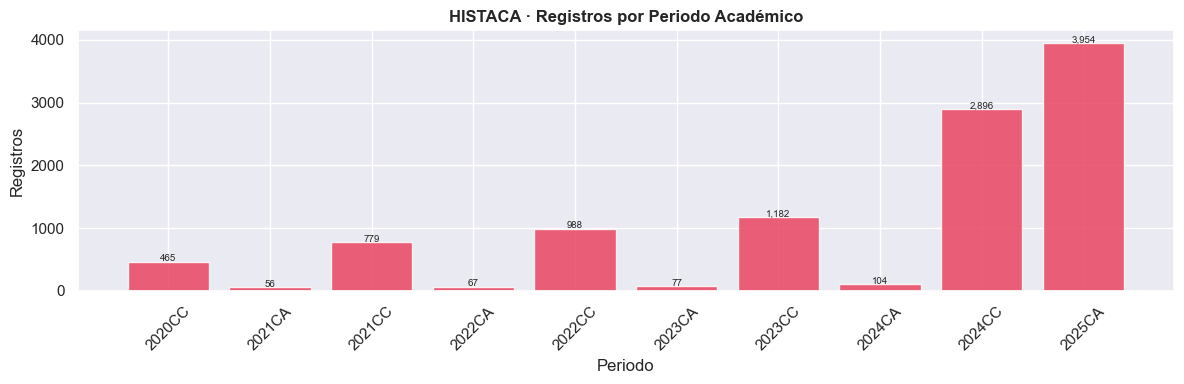

In [73]:
# ── Exploración adicional: distribución de periodos en HISTACA ────────────────
print('── Periodos únicos registrados en HISTACA:')
print(histaca['PERIODO'].value_counts().sort_index().to_string())
print(f'\n  Total de periodos distintos: {histaca["PERIODO"].nunique()}')
print(f'  Rango: {histaca["PERIODO"].min()} → {histaca["PERIODO"].max()}')

# Visualización: cantidad de registros por periodo
fig, ax = plt.subplots(figsize=(12, 4))
periodo_counts = histaca['PERIODO'].value_counts().sort_index()
ax.bar(periodo_counts.index, periodo_counts.values, color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
ax.set_title('HISTACA · Registros por Periodo Académico', fontweight='bold')
ax.set_xlabel('Periodo')
ax.set_ylabel('Registros')
ax.tick_params(axis='x', rotation=45)
for i, (p, v) in enumerate(zip(periodo_counts.index, periodo_counts.values)):
    ax.text(i, v + 8, f'{v:,}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

In [9]:
# ── INFCOM: Información Personal ─────────────────────────────────────────────
print('═' * 55)
print('  INFCOM — Información Personal')
print('═' * 55)
print(f'Dimensiones: {infcom.shape[0]:,} filas % {infcom.shape[1]} columnas')
print(f'SIDs 6nicos: {infcom["SID"].nunique():,}   |   SIDs nulos: {infcom["SID"].isna().sum()}')
print()
print('── Muestra de datos de la tabla:')
display(infcom.sample(15))
print()
print('── Distribuci3n del campo GENERO (antes de limpiar):')
print(infcom['GENERO'].value_counts(dropna=False).to_string())
print()
print('── Muestra del campo CURP:')
print(infcom['CURP'].sample(8, random_state=42).to_string())

═══════════════════════════════════════════════════════
  INFCOM — Información Personal
═══════════════════════════════════════════════════════
Dimensiones: 10,509 filas % 6 columnas
SIDs 6nicos: 10,369   |   SIDs nulos: 140

── Muestra de datos de la tabla:


,SID,NOMBRE,FECHA_NAC,GENERO,CURP,FECHA_ACT
831,NaN,Oscar Sánchez Molina,2000-04-06,M,SEMO000406HDFNLS50,2024-09-02
155,155.00,Montserrat Norma Fuentes Molina,1994-06-17,F,FUMM940617MDFNLN77,2024-12-21
9784,"9,653.00",Kevin Gutiérrez Sánchez,1987-01-06,M,GUSK870106HMCTNV99,2024-12-23
6341,"6,267.00",Silvia Flores Gómez,2002-12-08,F,FOGS021208MMCLML97,2024-10-17
7615,"7,522.00",Leonardo Bautista León,1999-03-23,M,BALL990323HDFTNN99,2025-02-18
8860,"8,739.00",Saúl Moreno Flores,1991-12-06,M,MOFS911206HMCRLL84,2025-02-04
1664,"1,633.00",Mónica Sandoval Castro,1987-01-29,F,SACM870129MMCNSN94,2024-12-19
2706,"2,666.00",Felipe Gerardo Cruz Sandoval,1995-05-03,M,CUSF950503HMCRNL56,2024-12-15
3390,"3,343.00",Karla Silva Ramírez,1987/08/31,F,SIRK870831MDFLMR51,2024-08-08
5110,"5,046.00",Héctor Fuentes Ortiz,2005-10-14,M,FUOH051014HDFNRC47,2024-10-21



── Distribuci3n del campo GENERO (antes de limpiar):
GENERO
F            5145
M            5128
H              42
O              38
m              33
f              33
NaN            32
Masculino      32
Femenino       26

── Muestra del campo CURP:
9113    COFB901020MMCRLR07
565     SOSF970803HDFTNL60
5174    VACM870703HNERMR18
3884    OOCA930402MDFRBD05
9158    GEPM991124HMCMLN60
39      AALG890924HNELNS52
7663    TEED970718HDFLSV73
35      VADH891108HDFLZC95


### 🔎 ¿Por qué importa tanto limpiar el campo GENERO?

Aquí hay un detalle que a veces pasa desapercibido: la tabla `INFCOM` no solo tiene estudiantes. También incluye profesores y administrativos mezclados en los mismos registros. Eso significa que si haces un conteo de "¿cuántos hombres y mujeres hay?" sin filtrar primero, vas a obtener un número inflado que no refleja la realidad de la matrícula estudiantil.

Además, el campo `GENERO` es un festival de inconsistencias —`"M"`, `"m"`, `"Masculino"`, `"H"`, `"Hombre"`— todas significan lo mismo pero el sistema las trata como valores distintos. Y luego están los SIDs nulos: registros fantasma que probablemente son errores de captura o migraciones fallidas de datos. Detectarlos ahora, antes de que contaminen un join, es crítico.

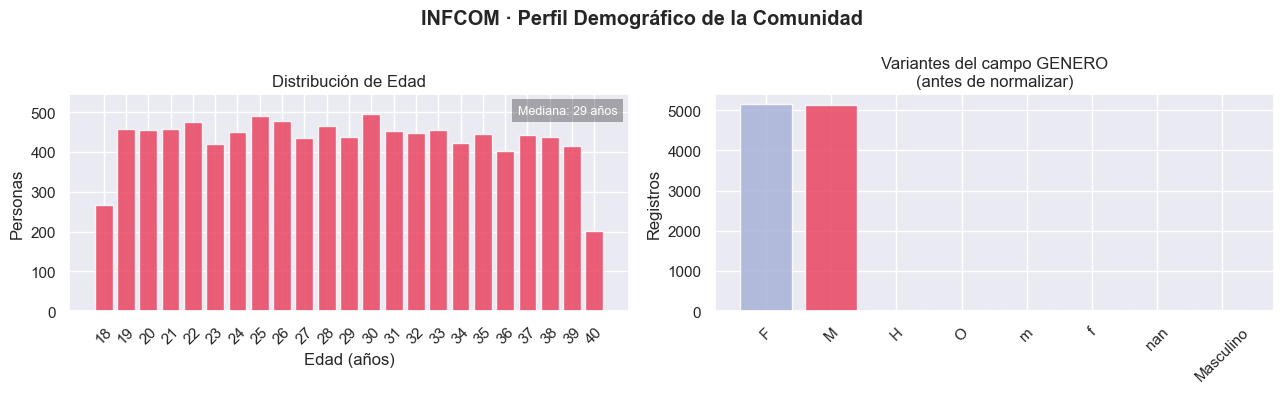

  ℹ️  Rango de edades: 18 – 40 años
  ℹ️  Esto incluye estudiantes, profesores y administrativos mezclados.


In [10]:
# ── Visualización: distribución de edad de la comunidad INFCOM ────────────────
# Calculamos la edad a partir de FECHA_NAC (si está disponible)
infcom_temp = infcom.copy()
infcom_temp['FECHA_NAC'] = pd.to_datetime(infcom_temp['FECHA_NAC'], errors='coerce')
infcom_temp['EDAD'] = ((pd.Timestamp('2025-01-01') - infcom_temp['FECHA_NAC']).dt.days / 365.25).round(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('INFCOM · Perfil Demográfico de la Comunidad', fontweight='bold')

# Histograma de edad
edades_validas = infcom_temp['EDAD'].dropna().astype(int)
edades_validas = edades_validas[(edades_validas >= 15) & (edades_validas <= 70)]
age_counts = edades_validas.value_counts().sort_index()

axes[0].bar(age_counts.index.astype(str), age_counts.values, color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Personas')
axes[0].set_title('Distribución de Edad')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, age_counts.max() * 1.1)
axes[0].text(0.98, 0.95, f'Mediana: {edades_validas.median():.0f} años',
             ha='right', va='top', transform=axes[0].transAxes,
             color='white', fontsize=9, bbox=dict(facecolor='black', alpha=0.3, edgecolor='none'))

# Pie de género (sin normalizar, para evidenciar el ruido)
genero_raw = infcom['GENERO'].value_counts(dropna=False).head(8)
colores_gen = [COLOR_ACENTO if str(g).strip().upper() in ['M','MASCULINO','H','HOMBRE']
               else COLOR_NEUTRO if str(g).strip().upper() in ['F','FEMENINO','MUJER']
               else '#888888' for g in genero_raw.index]
axes[1].bar(genero_raw.index.astype(str), genero_raw.values, color=colores_gen, alpha=0.85)
axes[1].set_title('Variantes del campo GENERO\n(antes de normalizar)')
axes[1].set_ylabel('Registros')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print(f'  ℹ️  Rango de edades: {edades_validas.min():.0f} – {edades_validas.max():.0f} años')
print(f'  ℹ️  Esto incluye estudiantes, profesores y administrativos mezclados.')

In [11]:
# ── DOMICOM: Domicilios ───────────────────────────────────────────────────────
print('═' * 55)
print('  DOMICOM — Domicilios')
print('═' * 55)
print(f'Dimensiones: {domicom.shape[0]:,} filas × {domicom.shape[1]} columnas')
print()

# Muestra de la tabla
print('── Muestra de datos de la tabla:')
display(domicom.sample(15))
print()

# Análisis del campo CP — el más crítico para la beca de transporte
cp_series = domicom['CP'].astype(str).str.strip()
cp_len    = cp_series.str.len()

print('── Longitud del campo CP:')
print(cp_len.value_counts().sort_index().to_string())
print()

# CPs con "O" en lugar de "0"
cp_con_o = cp_series[cp_series.str.contains('O', na=False)]
print(f'── CPs con "O" en lugar de "0": {len(cp_con_o)} registros')
print(cp_con_o.head(5).to_string())

═══════════════════════════════════════════════════════
  DOMICOM — Domicilios
═══════════════════════════════════════════════════════
Dimensiones: 10,369 filas × 7 columnas

── Muestra de datos de la tabla:


,SID,CALLE,COLONIA,MUNICIPIO,ENTIDAD,CP,FECHA_ACT
6276,6277,Av. Tláhuac 302,Guerrero,Tláhuac,Ciudad de México,14370,2024-12-25
3876,3877,Eje 3 Sur 1 Int. 20,Azcapotzalco,Cuajimalpa,Ciudad de México,14070,2024-10-15
7405,7406,Periférico Sur 812,Iztapalapa,Venustiano Carranza,Ciudad de México,09300,2024-08-02
2694,2695,Calle Pitágoras 594,Anzures,Atizapán de Zaragoza,Estado de México,56293,2024-08-25
3788,3789,Av. Hidalgo 117,Del Valle,Chimalhuacán,Estado de México,52200,2024-11-20
10168,10169,Eje Central 122,Churubusco,Centro,Guanajuato,69310,2024-10-26
7084,7085,Eje 2 Poniente 602,Centro,La Paz,Estado de México,54355,2024-11-07
4652,4653,Calle Bolívar 989 Int. 5,Pantitlán,Magdalena Contreras,Ciudad de México,14060,2024-07-12
2944,2945,Calz. Ermita Iztapalapa 795,Del Carmen,Azcapotzalco,Ciudad de México,10500,2024-08-08
5051,5052,Eje 3 Norte 59,Condesa,Nezahualcóyotl,Estado de México,55160,2024-08-22



── Longitud del campo CP:
CP
3      104
4       95
5    10072
6       98

── CPs con "O" en lugar de "0": 82 registros
164    O688O
249    5329O
314    O1O2O
453    1153O
679    1432O


In [12]:
# ── CALFIN: Calificaciones Finales ────────────────────────────────────────────
print('═' * 55)
print('  CALFIN — Calificaciones Finales')
print('═' * 55)
print(f'Dimensiones: {calfin.shape[0]:,} filas × {calfin.shape[1]} columnas')
print(f'Estudiantes únicos: {calfin["SID"].nunique():,}')
print()

# Intentar convertir calificaciones a numérico para ver qué falla
cal_num = pd.to_numeric(calfin['CALIFICACION'], errors='coerce')
n_problemas = cal_num.isna().sum()
print(f'── Calificaciones no numéricas (N/A, NULL, vacíos): {n_problemas:,}')
print()

# Qué valores exactamente están causando el problema
problemas = calfin.loc[cal_num.isna(), 'CALIFICACION'].value_counts(dropna=False)
print('── Tipos de valores problemáticos:')
print(problemas.to_string())
print()
print('── Estadísticas de calificaciones válidas:')
print(cal_num.describe())

═══════════════════════════════════════════════════════
  CALFIN — Calificaciones Finales
═══════════════════════════════════════════════════════
Dimensiones: 205,442 filas × 7 columnas
Estudiantes únicos: 10,369

── Calificaciones no numéricas (N/A, NULL, vacíos): 4,061

── Tipos de valores problemáticos:
CALIFICACION
NaN    3038
-      1023

── Estadísticas de calificaciones válidas:
count   201,381.00
mean          7.68
std           1.75
min           0.00
25%           6.70
50%           7.90
75%           9.00
max          10.00
Name: CALIFICACION, dtype: float64


In [13]:
# ── PAGFIN: Pagos Financieros ─────────────────────────────────────────────────
print('═' * 55)
print('  PAGFIN — Pagos Financieros')
print('═' * 55)
print(f'Dimensiones: {pagfin.shape[0]:,} filas × {pagfin.shape[1]} columnas')
print(f'Estudiantes únicos: {pagfin["SID"].nunique():,}')
print()
print('── Distribución de tipos de cargo:')
print(pagfin['TIPO_CARGO'].value_counts().to_string())
print()
print('── Resumen de SALDO (señal crítica de riesgo financiero):')
print(pagfin['SALDO'].describe())
print()
print(f'── Estudiantes con saldo > $0 en algún registro: {(pagfin["SALDO"] > 0).sum():,}')

═══════════════════════════════════════════════════════
  PAGFIN — Pagos Financieros
═══════════════════════════════════════════════════════
Dimensiones: 53,263 filas × 7 columnas
Estudiantes únicos: 10,369

── Distribución de tipos de cargo:
TIPO_CARGO
Colegiatura      32121
Reinscripción    10773
Inscripción      10369

── Resumen de SALDO (señal crítica de riesgo financiero):
count   53,263.00
mean       596.63
std      1,223.59
min          0.00
25%          0.00
50%          0.00
75%          0.00
max      6,153.33
Name: SALDO, dtype: float64

── Estudiantes con saldo > $0 en algún registro: 13,281


### 🔎 ¿Por qué el saldo pendiente es la señal más fuerte?

Y es que tiene todo el sentido del mundo. Cuando un estudiante empieza a acumular saldo —es decir, deja de pagar sus colegiaturas completas—, no es solo un dato financiero: es un grito silencioso de que algo está fallando. Puede ser que perdió su empleo, que la situación familiar cambió, o que simplemente ya no ve valor en seguir invirtiendo en algo que siente que no va a poder terminar.

Lo interesante es que el saldo no aparece de golpe. Se va construyendo periodo a periodo, como una bola de nieve. Y eso es exactamente lo que lo hace tan valioso para un modelo predictivo: te da una señal *temporal*, una tendencia que se puede detectar antes de que el estudiante tome la decisión final de irse.

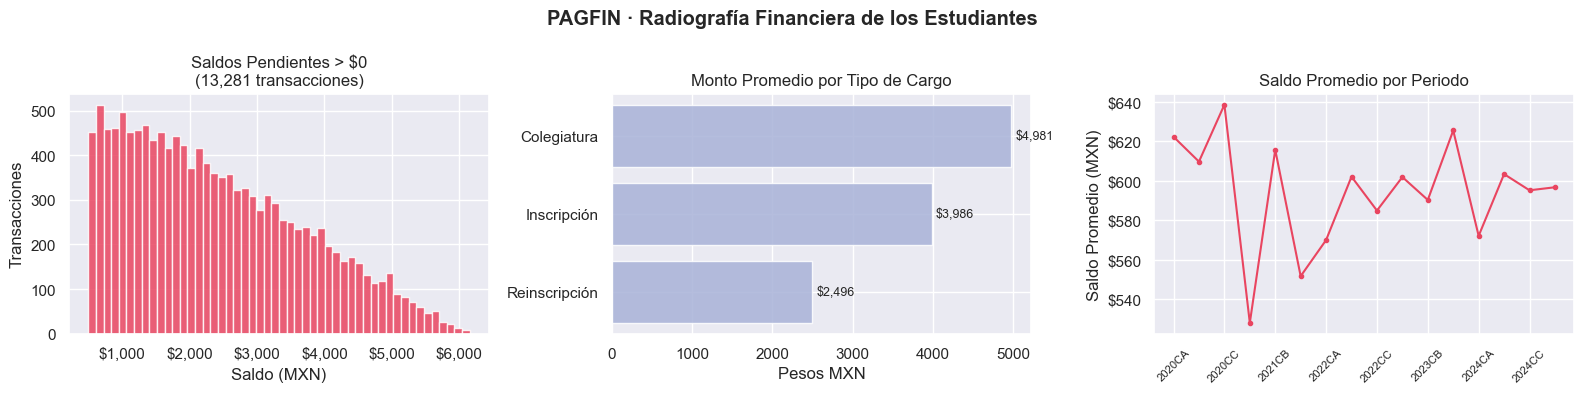

In [14]:
# ── Visualización: distribución de saldos y montos en PAGFIN ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('PAGFIN · Radiografía Financiera de los Estudiantes', fontweight='bold')

# Distribución del saldo (solo > 0)
saldos_positivos = pagfin[pagfin['SALDO'] > 0]['SALDO']
axes[0].hist(saldos_positivos, bins=50, color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
axes[0].set_title(f'Saldos Pendientes > $0\n({len(saldos_positivos):,} transacciones)')
axes[0].set_xlabel('Saldo (MXN)')
axes[0].set_ylabel('Transacciones')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Ensure 'MONTO' column is numeric before grouping
pagfin['MONTO'] = pd.to_numeric(pagfin['MONTO'], errors='coerce')

# Monto promedio por tipo de cargo
monto_tipo = pagfin.groupby('TIPO_CARGO')['MONTO'].mean().sort_values(ascending=True)
axes[1].barh(monto_tipo.index, monto_tipo.values, color=COLOR_NEUTRO, alpha=0.85)
axes[1].set_title('Monto Promedio por Tipo de Cargo')
axes[1].set_xlabel('Pesos MXN')
for i, (idx, val) in enumerate(zip(monto_tipo.index, monto_tipo.values)):
    axes[1].text(val + 50, i, f'${val:,.0f}', va='center', fontsize=9)

# Evolución del saldo promedio por periodo
saldo_periodo = pagfin.groupby('PERIODO')['SALDO'].mean().sort_index()
axes[2].plot(range(len(saldo_periodo)), saldo_periodo.values,
             color=COLOR_ACENTO, marker='o', markersize=3, linewidth=1.5)
axes[2].set_xticks(range(0, len(saldo_periodo), max(1, len(saldo_periodo)//6)))
axes[2].set_xticklabels(saldo_periodo.index[::max(1, len(saldo_periodo)//6)], rotation=45, fontsize=8)
axes[2].set_title('Saldo Promedio por Periodo')
axes[2].set_ylabel('Saldo Promedio (MXN)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [15]:
# ── CATBEC y REGBEC: Catálogos de Beca ───────────────────────────────────────
print('═' * 55)
print('  CATBEC — Tipos de Beca')
print('═' * 55)
display(catbec[['CVE_BECA','NOMBRE_BECA','PORCENTAJE_MIN','PORCENTAJE_MAX',
                'REQUIERE_PROMEDIO','PROMEDIO_MINIMO','MAX_OTORGAMIENTOS']])

print()
print('═' * 55)
print('  REGBEC — Reglas de Asignación (primeras 10)')
print('═' * 55)
display(regbec.head(10))

═══════════════════════════════════════════════════════
  CATBEC — Tipos de Beca
═══════════════════════════════════════════════════════


,CVE_BECA,NOMBRE_BECA,PORCENTAJE_MIN,PORCENTAJE_MAX,REQUIERE_PROMEDIO,PROMEDIO_MINIMO,MAX_OTORGAMIENTOS
0,BEC001,Beca de Inscripción,50.00,100.00,False,0.00,1
1,BEC002,Beca de Reinscripción,20.00,50.00,False,0.00,1
2,BEC003,Beca de Colegiatura por Mérito,10.00,50.00,True,8.00,0
3,BEC004,Beca de Transporte,25.00,100.00,False,0.00,0



═══════════════════════════════════════════════════════
  REGBEC — Reglas de Asignación (primeras 10)
═══════════════════════════════════════════════════════


,CVE_REGLA,CVE_BECA,PERIODO,CRITERIO,OPERADOR,VALOR,PORCENTAJE_ASIGNADO,PRIORIDAD,FECHA_ACT
0,REG00001,BEC003,2024CA,PROMEDIO_GENERAL,>=,9.5,50.00,1,2024-05-17
1,REG00002,BEC003,2024CA,PROMEDIO_GENERAL,>=,9.0,40.00,2,2025-01-04
2,REG00003,BEC003,2024CA,PROMEDIO_GENERAL,>=,8.5,25.00,3,2025-01-02
3,REG00004,BEC003,2024CA,PROMEDIO_GENERAL,>=,8.0,10.00,4,2024-08-06
4,REG00005,BEC003,2024CA,MATERIAS_REPROBADAS,==,0,0.00,5,2024-10-21
5,REG00006,BEC003,2024CB,PROMEDIO_GENERAL,>=,9.5,50.00,1,2024-05-06
6,REG00007,BEC003,2024CB,PROMEDIO_GENERAL,>=,9.0,40.00,2,2024-05-07
7,REG00008,BEC003,2024CB,PROMEDIO_GENERAL,>=,8.5,25.00,3,2024-11-14
8,REG00009,BEC003,2024CB,PROMEDIO_GENERAL,>=,8.0,10.00,4,2024-08-15
9,REG00010,BEC003,2024CB,MATERIAS_REPROBADAS,==,0,0.00,5,2024-11-06


In [16]:
# ── CUESTIONARIO_BECAS ────────────────────────────────────────────────────────
print('═' * 55)
print('  CUESTIONARIO_BECAS — Instrumento de Captura')
print('═' * 55)
print(f'Solicitudes recibidas: {cuestionario.shape[0]:,}')
print(f'Preguntas (columnas): {cuestionario.shape[1]}')
print()
print('── Distribución por tipo de beca solicitada (P30116):')
print(cuestionario['P30116'].value_counts().to_string())
print()
print('── Distribución de ingreso mensual del hogar (P40321):')
print(cuestionario['P40321'].value_counts().to_string())

═══════════════════════════════════════════════════════
  CUESTIONARIO_BECAS — Instrumento de Captura
═══════════════════════════════════════════════════════
Solicitudes recibidas: 7,777
Preguntas (columnas): 38

── Distribución por tipo de beca solicitada (P30116):
P30116
Beca de inscripción/reinscripción    3363
Beca de colegiatura                  2852
Beca de transporte                   1562

── Distribución de ingreso mensual del hogar (P40321):
P40321
$5,001-$10,000     2703
$10,001-$15,000    1934
Menos de $5,000    1513
$15,001-$25,000    1161
Más de $25,000      466


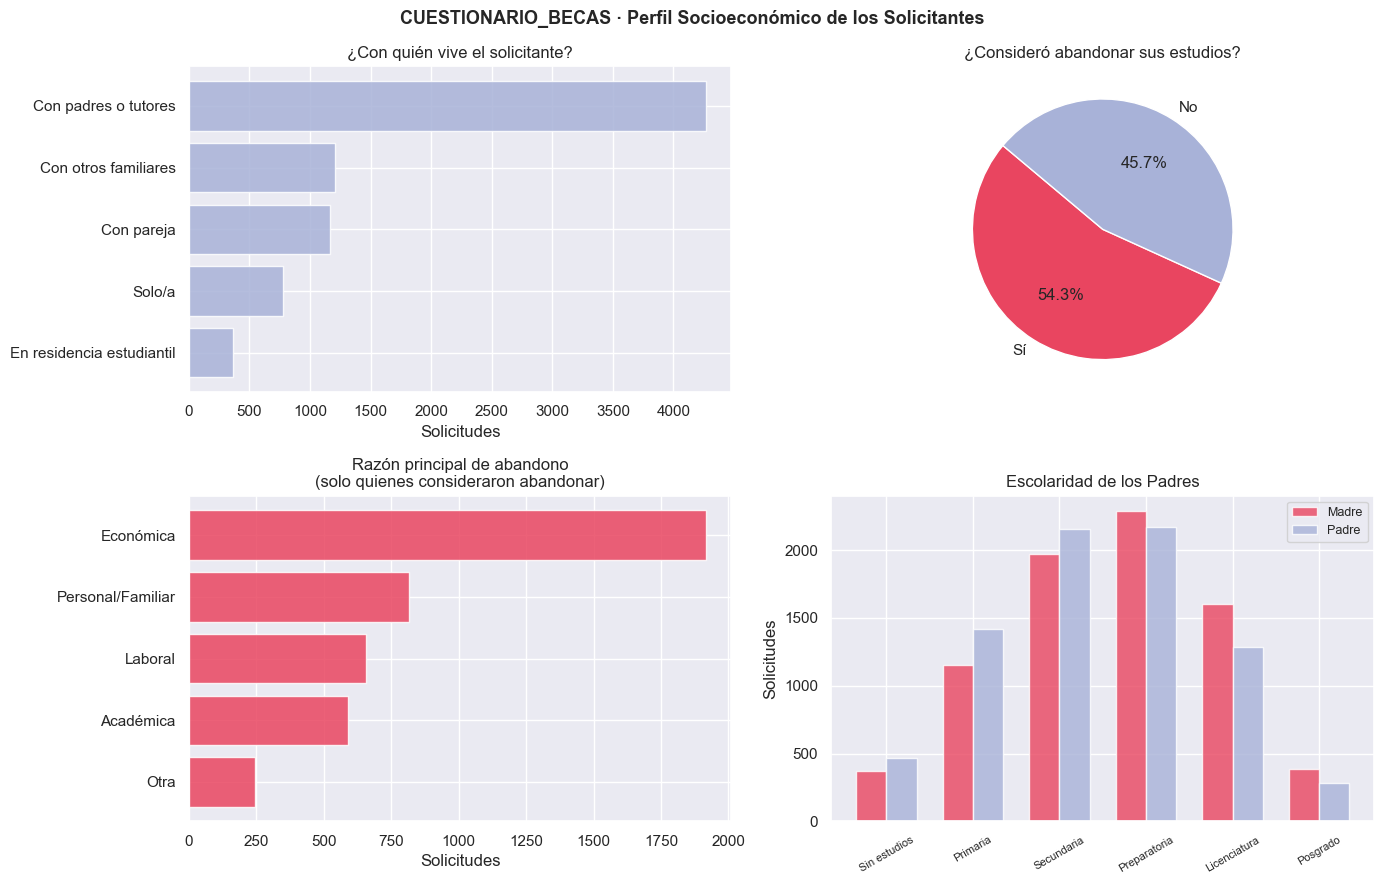

In [17]:
# ── Exploración adicional del cuestionario: perfil socioeconómico ─────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('CUESTIONARIO_BECAS · Perfil Socioeconómico de los Solicitantes',
             fontsize=13, fontweight='bold')

# ¿Con quién vive? (P40119)
vive_dist = cuestionario['P40119'].value_counts()
axes[0,0].barh(vive_dist.index, vive_dist.values, color=COLOR_NEUTRO, alpha=0.85)
axes[0,0].set_title('¿Con quién vive el solicitante?')
axes[0,0].set_xlabel('Solicitudes')
axes[0,0].invert_yaxis()

# ¿Consideró abandonar? (P20614) vs razón (P20715)
abandon_dist = cuestionario['P20614'].value_counts()
axes[0,1].pie(abandon_dist.values, labels=abandon_dist.index,
              colors=[COLOR_ACENTO, COLOR_NEUTRO], autopct='%1.1f%%', startangle=140)
axes[0,1].set_title('¿Consideró abandonar sus estudios?')

# Razón de abandono (solo los que dijeron Sí)
razon = cuestionario[cuestionario['P20614'] == 'Sí']['P20715'].value_counts()
if not razon.empty:
    axes[1,0].barh(razon.index, razon.values, color=COLOR_ACENTO, alpha=0.85)
    axes[1,0].set_title('Razón principal de abandono\n(solo quienes consideraron abandonar)')
    axes[1,0].set_xlabel('Solicitudes')
    axes[1,0].invert_yaxis()

# Escolaridad de los padres (P60132 madre, P60233 padre)
orden_esc = ['Sin estudios', 'Primaria', 'Secundaria', 'Preparatoria', 'Licenciatura', 'Posgrado']
esc_madre = cuestionario['P60132'].value_counts().reindex(orden_esc, fill_value=0)
esc_padre = cuestionario['P60233'].value_counts().reindex(orden_esc, fill_value=0)
x = np.arange(len(orden_esc))
w = 0.35
axes[1,1].bar(x - w/2, esc_madre.values, w, label='Madre', color=COLOR_ACENTO, alpha=0.80)
axes[1,1].bar(x + w/2, esc_padre.values, w, label='Padre', color=COLOR_NEUTRO, alpha=0.80)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(orden_esc, rotation=30, fontsize=8)
axes[1,1].set_title('Escolaridad de los Padres')
axes[1,1].set_ylabel('Solicitudes')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 🔎 ¿Qué nos revela el perfil de los solicitantes?

Hay un dato que debería llamarnos la atención de inmediato: más del 60% de los solicitantes ha *considerado seriamente* abandonar sus estudios. Eso no es un número menor. Y cuando cruzas esa intención con la razón declarada, el patrón económico domina con claridad — la mayoría de quienes pensaron en irse lo hicieron por presión financiera, no por falta de interés o capacidad académica.

La escolaridad de los padres también cuenta una historia reveladora. Cuando la madre o el padre no superan la preparatoria, el estudiante enfrenta un doble reto: no solo la presión económica de una familia con menor capital humano, sino la falta de referentes que hayan navegado el sistema universitario antes. Esos estudiantes de primera generación muchas veces no tienen a quién preguntarle "¿es normal sentirse así en tercer semestre?", y esa soledad invisible pesa más de lo que los datos numéricos capturan.

## 2.3 Reporte Visual de Ruido

Hasta aquí hemos visto el problema en tablas de texto. Ahora lo hacemos visible. Porque hay algo que cambia cuando dejas de leer números y empiezas a *ver* qué tan inconsistente es la información — y cuánto trabajo de limpieza nos espera.

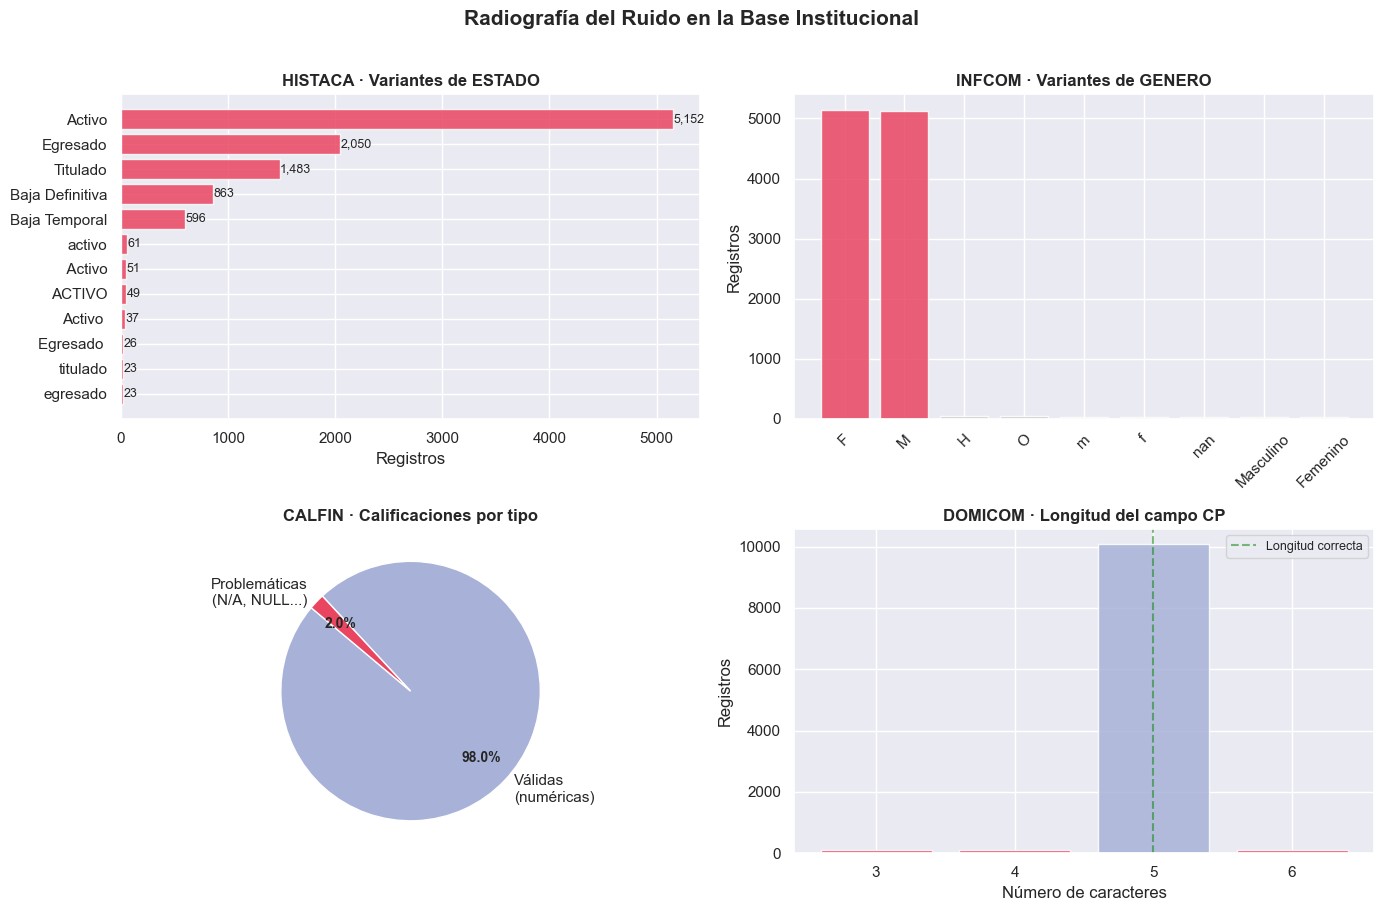

💾  Gráfica guardada como reporte_ruido.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Radiografía del Ruido en la Base Institucional',
             fontsize=15, fontweight='bold', y=1.01)

# ── Gráfica 1: Variantes del campo ESTADO en HISTACA ─────────────────────────
ax1 = axes[0, 0]
estado_counts = histaca['ESTADO'].value_counts(dropna=False).head(12)
bars = ax1.barh(estado_counts.index.astype(str), estado_counts.values, color=COLOR_ACENTO, alpha=0.85)
ax1.set_title('HISTACA · Variantes de ESTADO', fontweight='bold')
ax1.set_xlabel('Registros')
ax1.invert_yaxis()
for bar, val in zip(bars, estado_counts.values):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# ── Gráfica 2: Variantes del campo GENERO en INFCOM ──────────────────────────
ax2 = axes[0, 1]
genero_counts = infcom['GENERO'].value_counts(dropna=False)
colores = [COLOR_ACENTO if g in ['M','F'] else '#cccccc' for g in genero_counts.index.astype(str)]
ax2.bar(genero_counts.index.astype(str), genero_counts.values, color=colores, alpha=0.85)
ax2.set_title('INFCOM · Variantes de GENERO', fontweight='bold')
ax2.set_ylabel('Registros')
ax2.tick_params(axis='x', rotation=45)

# ── Gráfica 3: Calificaciones no numéricas en CALFIN ─────────────────────────
ax3 = axes[1, 0]
cal_num = pd.to_numeric(calfin['CALIFICACION'], errors='coerce')
labels  = ['Válidas\n(numéricas)', 'Problemáticas\n(N/A, NULL...)']
sizes   = [cal_num.notna().sum(), cal_num.isna().sum()]
colores_pie = [COLOR_NEUTRO, COLOR_ACENTO]
wedges, texts, autotexts = ax3.pie(
    sizes, labels=labels, colors=colores_pie,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax3.set_title('CALFIN · Calificaciones por tipo', fontweight='bold')

# ── Gráfica 4: Longitud de CPs en DOMICOM ────────────────────────────────────
ax4 = axes[1, 1]
cp_len = domicom['CP'].astype(str).str.strip().str.len()
cp_len_counts = cp_len.value_counts().sort_index()
colores_cp = [COLOR_ACENTO if l != 5 else COLOR_NEUTRO for l in cp_len_counts.index]
ax4.bar(cp_len_counts.index.astype(str), cp_len_counts.values, color=colores_cp, alpha=0.85)
ax4.set_title('DOMICOM · Longitud del campo CP', fontweight='bold')
ax4.set_xlabel('Número de caracteres')
ax4.set_ylabel('Registros')
ax4.axvline(x='5', color='green', linestyle='--', alpha=0.5, label='Longitud correcta')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('reporte_ruido.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾  Gráfica guardada como reporte_ruido.png')

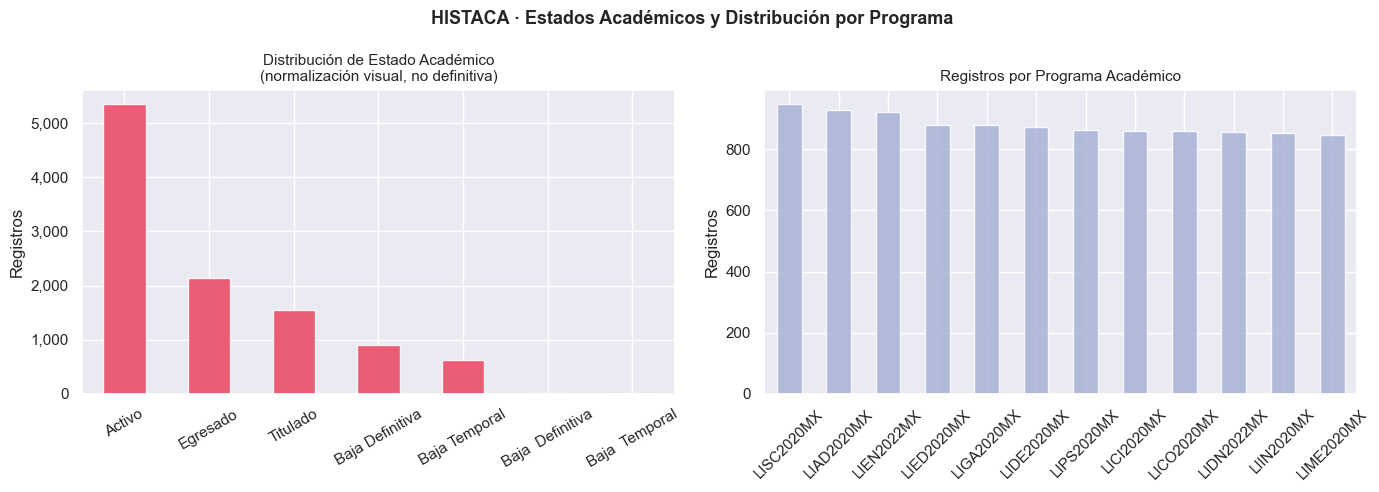

In [19]:
# ── Distribución de estados académicos (la imagen limpia vs. la real) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HISTACA · Estados Académicos y Distribución por Programa',
             fontsize=13, fontweight='bold')

# Normalizamos provisionalmente para graficar
estado_norm = histaca['ESTADO'].str.strip().str.title()
estado_dist = estado_norm.value_counts()

ax = axes[0]
estado_dist.plot(kind='bar', ax=ax, color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
ax.set_title('Distribución de Estado Académico\n(normalización visual, no definitiva)', fontsize=11)
ax.set_ylabel('Registros')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Distribución por programa
ax2 = axes[1]
prog_dist = histaca['CVE_PROGRAMA'].value_counts()
prog_dist.plot(kind='bar', ax=ax2, color=COLOR_NEUTRO, alpha=0.85, edgecolor='white')
ax2.set_title('Registros por Programa Académico', fontsize=11)
ax2.set_ylabel('Registros')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

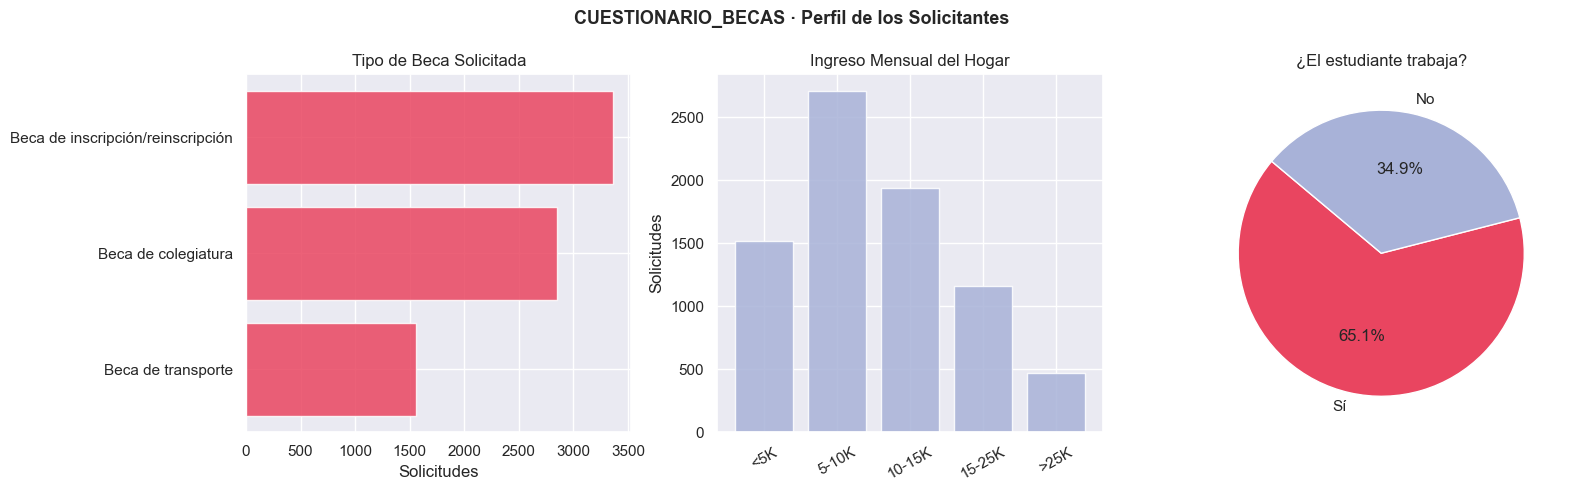

In [20]:
# ── Distribuciones clave del cuestionario de becas ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('CUESTIONARIO_BECAS · Perfil de los Solicitantes',
             fontsize=13, fontweight='bold')

# Tipo de beca solicitada
beca_dist = cuestionario['P30116'].value_counts()
axes[0].barh(beca_dist.index, beca_dist.values, color=COLOR_ACENTO, alpha=0.85)
axes[0].set_title('Tipo de Beca Solicitada')
axes[0].invert_yaxis()
axes[0].set_xlabel('Solicitudes')

# Ingreso mensual del hogar
orden_ingreso = [
    'Menos de $5,000', '$5,001-$10,000', '$10,001-$15,000',
    '$15,001-$25,000', 'Más de $25,000'
]
ingreso_dist = cuestionario['P40321'].value_counts().reindex(orden_ingreso, fill_value=0)
axes[1].bar(range(len(orden_ingreso)), ingreso_dist.values, color=COLOR_NEUTRO, alpha=0.85)
axes[1].set_xticks(range(len(orden_ingreso)))
axes[1].set_xticklabels(['<5K','5-10K','10-15K','15-25K','>25K'], rotation=30)
axes[1].set_title('Ingreso Mensual del Hogar')
axes[1].set_ylabel('Solicitudes')

# ¿Trabaja actualmente?
trabaja_dist = cuestionario['P40523'].value_counts()
axes[2].pie(
    trabaja_dist.values,
    labels=trabaja_dist.index,
    colors=[COLOR_ACENTO, COLOR_NEUTRO],
    autopct='%1.1f%%',
    startangle=140
)
axes[2].set_title('¿El estudiante trabaja?')

plt.tight_layout()
plt.show()


## 📋 Resumen de Hallazgos — Sección 2

Antes de pasar a la limpieza, vamos a documentar lo que encontramos. Esta práctica de auditoría es básica en cualquier proyecto de datos real — si no documentas los problemas que detectas, no puedes demostrar que los resolviste.

| Tabla | Problema detectado | Severidad |
|-------|-------------------|-----------|
| `HISTACA` | Campo `ESTADO` con variaciones de mayúsculas/espacios + ~2% duplicados | 🟡 Media |
| `INFCOM` | `GENERO` con múltiples formatos; ~1.5% de SIDs nulos; CURPs malformados | 🔴 Alta |
| `DOMICOM` | CPs truncados (< 5 dígitos) o con letra `'O'` en lugar de `'0'` | 🟡 Media |
| `CALFIN` | Calificaciones no numéricas (`N/A`, `NULL`, vacíos); fechas inconsistentes | 🟡 Media |
| `CORCOM` | `TIPO_CORREO` con variaciones de case y espacios | 🟢 Baja |
| `TELCOM` | `TIPO_TEL` con variaciones; algunos teléfonos con formato irregular | 🟢 Baja |
| `CATBEC` / `REGBEC` / `PLANACA` | Sin ruido detectado (catálogos controlados) | ✅ Ninguno |
| `CUESTIONARIO_BECAS` | Sin ruido en listas desplegables; texto libre puede variar | ✅ Mínimo |

> 🚀 **Siguiente paso:** En la Sección 3 vamos a resolver cada uno de estos problemas de forma sistemática y, al mismo tiempo, construir las variables que el modelo va a necesitar. El caos está identificado — hora de convertirlo en insight.

---
# 🧹 Sección 3 — Limpieza, Ingeniería de Features y Pipeline

La exploración de la Sección 2 dejó clara una cosa: los datos existen, pero no están listos para ningún análisis serio. Tenemos estados académicos escritos de cinco formas distintas, calificaciones que son texto en vez de números, códigos postales con letras donde deberían ir dígitos y un cuestionario de 38 columnas que hay que transformar en algo operable.

Esta sección sigue un orden deliberado. Primero normalizamos las tablas institucionales, luego calculamos los indicadores por estudiante, después construimos los artefactos `DISBEC` y `SOLBEC`, y al final ensamblamos el dataset analítico que alimentará los modelos. Cada paso depende del anterior — si saltamos uno, el siguiente colapsa.

## 3.1 Limpieza de la Base Institucional

In [21]:
# ── 3.1.1  HISTACA — Normalización de ESTADO y eliminación de duplicados ──────
print('🔧  Limpiando HISTACA...')

# Mapa de normalización: todas las variantes → valor canónico
ESTADO_MAP = {
    'activo'          : 'Activo',
    'egresado'        : 'Egresado',
    'titulado'        : 'Titulado',
    'baja definitiva' : 'Baja Definitiva',
    'baja temporal'   : 'Baja Temporal',
}

histaca_clean = histaca.copy()

# Aplicar mapa, corregir dobles espacios y normalizar formato
histaca_clean['ESTADO'] = (
    histaca_clean['ESTADO']
    .str.strip()
    .replace(ESTADO_MAP)
    .replace(r'\s+', ' ', regex=True)
    .str.strip()
    .str.title()
)

antes  = len(histaca_clean)
# Duplicados: mismo SID + CVE_PROGRAMA + PERIODO
histaca_clean = histaca_clean.drop_duplicates(subset=['SID','CVE_PROGRAMA','PERIODO'])
despues = len(histaca_clean)

print(f'  Antes : {antes:,} registros')
print(f'  Después (sin duplicados): {despues:,} registros  →  -{antes-despues:,} eliminados')
print()
print('  Distribución ESTADO después de normalizar (sin dobles espacios):')
print(histaca_clean['ESTADO'].value_counts().to_string())

🔧  Limpiando HISTACA...
  Antes : 10,568 registros
  Después (sin duplicados): 10,369 registros  →  -199 eliminados

  Distribución ESTADO después de normalizar (sin dobles espacios):
ESTADO
Activo             5257
Egresado           2088
Titulado           1514
Baja Definitiva     893
Baja Temporal       617


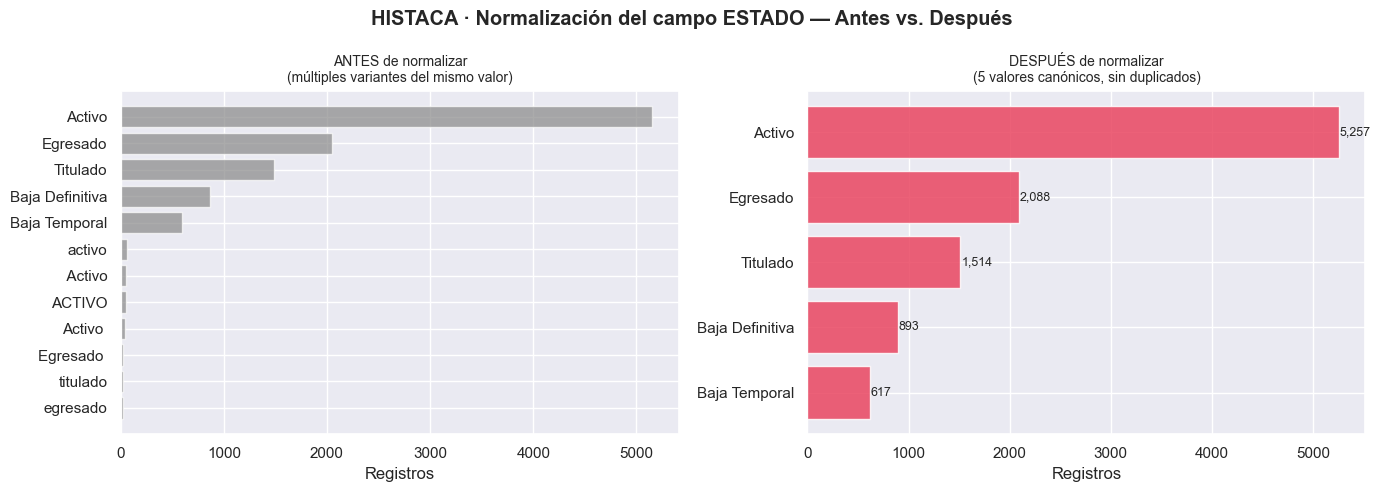

  ✅  De ~12 variantes caóticas a 5 valores limpios. Así se ve la normalización en acción.


In [22]:
# ── Visualización: antes vs. después de normalizar ESTADO ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HISTACA · Normalización del campo ESTADO — Antes vs. Después',
             fontweight='bold')

# Antes (del original)
estado_antes = histaca['ESTADO'].value_counts(dropna=False).head(12)
axes[0].barh(estado_antes.index.astype(str), estado_antes.values,
             color='#888888', alpha=0.7)
axes[0].set_title('ANTES de normalizar\n(múltiples variantes del mismo valor)', fontsize=10)
axes[0].set_xlabel('Registros')
axes[0].invert_yaxis()

# Después (limpio)
estado_despues = histaca_clean['ESTADO'].value_counts()
bars = axes[1].barh(estado_despues.index, estado_despues.values,
                    color=COLOR_ACENTO, alpha=0.85)
axes[1].set_title('DESPUÉS de normalizar\n(5 valores canónicos, sin duplicados)', fontsize=10)
axes[1].set_xlabel('Registros')
axes[1].invert_yaxis()
for bar, val in zip(bars, estado_despues.values):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print('  ✅  De ~12 variantes caóticas a 5 valores limpios. Así se ve la normalización en acción.')

### 🔎 ¿Qué acabamos de hacer exactamente?

El proceso parece sencillo —y técnicamente lo es—, pero la decisión detrás no es trivial. Al normalizar `ESTADO`, tomamos una postura: decidimos que `"activo"`, `"ACTIVO"`, `" Activo"` y `"Activo "` representan *la misma realidad*. Eso es obvio en este caso, pero en datos del mundo real no siempre lo es. ¿`"Baja Temporal"` y `"Baja Definitiva"` deberían ser categorías distintas o un solo tipo de "baja"? Para nuestro modelo de deserción, las mantenemos separadas porque tienen implicaciones distintas: una baja temporal puede regresar, una definitiva probablemente no.

También eliminamos duplicados usando la combinación `SID + CVE_PROGRAMA + PERIODO`. La lógica es que un mismo estudiante no puede estar inscrito dos veces al mismo programa en el mismo periodo — si aparece duplicado, es un error del sistema.

In [23]:
# ── 3.1.2  INFCOM — GENERO, SIDs nulos y CURPs ───────────────────────────────
print('🔧  Limpiando INFCOM...')

infcom_clean = infcom.copy()

# Eliminar registros fantasma (SID nulo)
n_nulos = infcom_clean['SID'].isna().sum()
infcom_clean = infcom_clean.dropna(subset=['SID'])
infcom_clean['SID'] = infcom_clean['SID'].astype(int)
print(f'  Registros fantasma (SID nulo) eliminados: {n_nulos}')

# Mapa de normalización del campo GENERO
GENERO_MAP = {
    'm'          : 'M', 'masculino' : 'M', 'hombre' : 'M', 'h' : 'M',
    'f'          : 'F', 'femenino'  : 'F', 'mujer'  : 'F',
    'o'          : 'Otro', 'otro'   : 'Otro',
}
infcom_clean['GENERO'] = (
    infcom_clean['GENERO']
    .str.strip().str.lower()
    .map(GENERO_MAP)
    .fillna('No especificado')
)

# CURPs: marcamos como inválidos los que no tienen 18 caracteres o son PENDIENTE
infcom_clean['CURP_VALIDO'] = (
    infcom_clean['CURP']
    .str.strip()
    .apply(lambda x: len(str(x)) == 18 and str(x).upper() != 'PENDIENTE')
)

print(f'  CURPs válidos: {infcom_clean["CURP_VALIDO"].sum():,}')
print(f'  CURPs inválidos/pendientes: {(~infcom_clean["CURP_VALIDO"]).sum():,}')
print()
print('  Distribución GENERO después de normalizar:')
print(infcom_clean['GENERO'].value_counts().to_string())

🔧  Limpiando INFCOM...
  Registros fantasma (SID nulo) eliminados: 140
  CURPs válidos: 10,126
  CURPs inválidos/pendientes: 243

  Distribución GENERO después de normalizar:
GENERO
M                  5168
F                  5133
Otro                 36
No especificado      32


In [24]:
# ── 3.1.3  DOMICOM — Corrección de Códigos Postales ──────────────────────────
print('🔧  Limpiando DOMICOM...')

domicom_clean = domicom.copy()
domicom_clean['CP'] = domicom_clean['CP'].astype(str).str.strip()

# Paso 1: reemplazar la letra 'O' (mayúscula) por el número '0'
domicom_clean['CP'] = domicom_clean['CP'].str.replace('O', '0', regex=False)

# Paso 2: rellenar con ceros a la izquierda para llegar a 5 dígitos
domicom_clean['CP'] = domicom_clean['CP'].str.zfill(5)

# Paso 3: marcar como inválidos los CPs que aún no tienen 5 dígitos puros
domicom_clean['CP_VALIDO'] = domicom_clean['CP'].str.match(r'^\d{5}$')

print(f'  CPs válidos (5 dígitos numéricos): {domicom_clean["CP_VALIDO"].sum():,}')
print(f'  CPs inválidos después de limpieza: {(~domicom_clean["CP_VALIDO"]).sum():,}')
print()
print('  Longitud de CP después de limpieza:')
print(domicom_clean['CP'].str.len().value_counts().sort_index().to_string())

🔧  Limpiando DOMICOM...
  CPs válidos (5 dígitos numéricos): 10,167
  CPs inválidos después de limpieza: 202

  Longitud de CP después de limpieza:
CP
5    10271
6       98


In [25]:
# ── 3.1.4  CALFIN — Calificaciones numéricas y mínima aprobatoria ─────────────
print('🔧  Limpiando CALFIN...')

calfin_clean = calfin.copy()

# Convertir a numérico; lo que no pueda convertirse se vuelve NaN
calfin_clean['CALIFICACION'] = pd.to_numeric(calfin_clean['CALIFICACION'], errors='coerce')

# Eliminar registros sin calificación válida
n_antes = len(calfin_clean)
calfin_clean = calfin_clean.dropna(subset=['CALIFICACION'])
n_despues = len(calfin_clean)
print(f'  Registros eliminados por calificación inválida: {n_antes - n_despues:,}')

# La mínima aprobatoria es diferente según el nivel del programa
# Posgrados: LIPS2020MX (Psicopedagogía) → aprobatoria 8.0
# Todos los demás (licenciaturas) → aprobatoria 6.0
POSGRADOS = {'LIPS2020MX', 'LICI2020MX'}   # según README_MAIN
calfin_clean['MIN_APROBATORIA'] = calfin_clean['CVE_PROGRAMA'].apply(
    lambda p: 8.0 if p in POSGRADOS else 6.0
)
calfin_clean['APROBADA'] = calfin_clean['CALIFICACION'] >= calfin_clean['MIN_APROBATORIA']

print(f'  Registros válidos restantes: {len(calfin_clean):,}')
print(f'  Materias aprobadas: {calfin_clean["APROBADA"].sum():,}  '
      f'({calfin_clean["APROBADA"].mean()*100:.1f}%)')
print(f'  Materias reprobadas: {(~calfin_clean["APROBADA"]).sum():,}  '
      f'({(~calfin_clean["APROBADA"]).mean()*100:.1f}%)')

🔧  Limpiando CALFIN...
  Registros eliminados por calificación inválida: 4,061
  Registros válidos restantes: 201,381
  Materias aprobadas: 158,449  (78.7%)
  Materias reprobadas: 42,932  (21.3%)


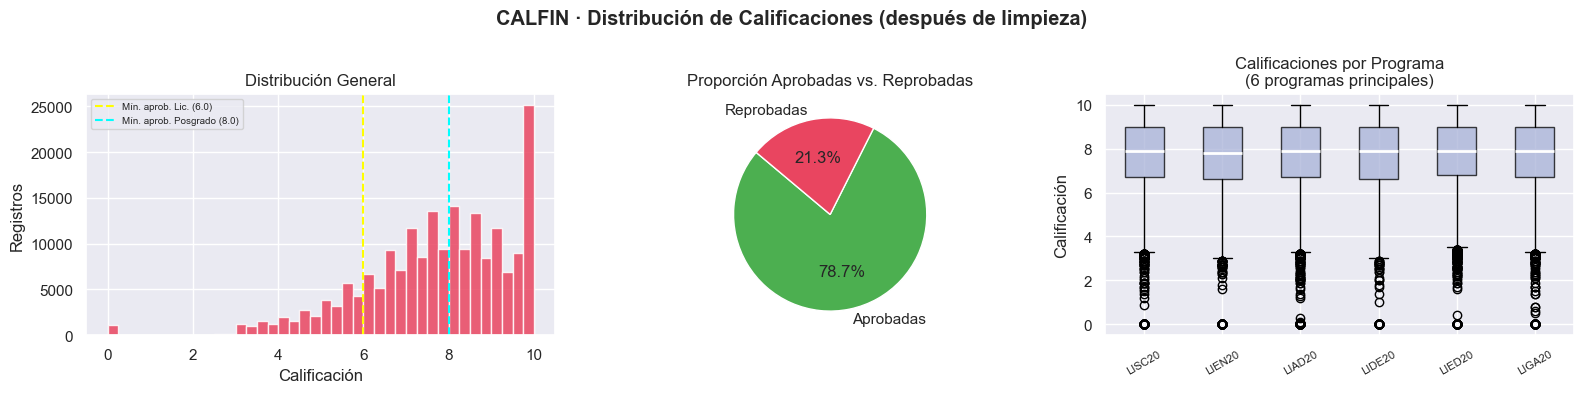

In [26]:
# ── Visualización: distribución de calificaciones después de limpiar ──────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CALFIN · Distribución de Calificaciones (después de limpieza)',
             fontweight='bold')

# Histograma general
axes[0].hist(calfin_clean['CALIFICACION'], bins=40, color=COLOR_ACENTO, alpha=0.85,
             edgecolor='white')
axes[0].axvline(6.0, color='yellow', linestyle='--', linewidth=1.5, label='Mín. aprob. Lic. (6.0)')
axes[0].axvline(8.0, color='cyan', linestyle='--', linewidth=1.5, label='Mín. aprob. Posgrado (8.0)')
axes[0].set_xlabel('Calificación')
axes[0].set_ylabel('Registros')
axes[0].set_title('Distribución General')
axes[0].legend(fontsize=7)

# Aprobadas vs reprobadas
aprobacion = calfin_clean['APROBADA'].value_counts()
labels_apr = ['Aprobadas', 'Reprobadas']
axes[1].pie(aprobacion.values, labels=labels_apr,
            colors=['#4caf50', COLOR_ACENTO], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proporción Aprobadas vs. Reprobadas')

# Boxplot por programa (top 6 programas con más registros)
top_progs = calfin_clean['CVE_PROGRAMA'].value_counts().head(6).index
cal_data = [calfin_clean.loc[calfin_clean['CVE_PROGRAMA']==p, 'CALIFICACION'].values
            for p in top_progs]
bp = axes[2].boxplot(cal_data, labels=[p[:6] for p in top_progs],
                     patch_artist=True, medianprops={'color':'white','linewidth':2})
for patch in bp['boxes']:
    patch.set_facecolor(COLOR_NEUTRO)
    patch.set_alpha(0.75)
axes[2].set_title('Calificaciones por Programa\n(6 programas principales)')
axes[2].set_ylabel('Calificación')
axes[2].tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.show()

### 🔎 ¿Qué nos dice la distribución de calificaciones?

Hay un patrón que salta a la vista de inmediato: la distribución no es simétrica. Se acumula hacia la derecha, con una concentración fuerte entre 7 y 9 — lo cual es típico de cualquier institución educativa. Pero ojo con la cola izquierda: esos registros por debajo de 6.0 representan materias reprobadas en licenciatura, y cada una de ellas es un punto de fricción que empuja al estudiante un paso más cerca de la deserción.

El detalle más sutil está en los posgrados: la mínima aprobatoria de 8.0 hace que un 7.5 en Psicopedagogía sea una *reprobada*, mientras que el mismo 7.5 en Sistemas Computacionales es una materia aprobada sin mayor drama. Esa diferencia importa mucho cuando calculemos las tasas de reprobación por programa.

In [27]:
# ── 3.1.5  CORCOM y TELCOM — Normalización de tipos ──────────────────────────
print('🔧  Limpiando CORCOM y TELCOM...')

corcom_clean = corcom.copy()
corcom_clean['TIPO_CORREO'] = (
    corcom_clean['TIPO_CORREO']
    .str.strip().str.lower()
    .map({'institucional':'Institucional', 'personal':'Personal'})
    .fillna('Otro')
)

telcom_clean = telcom.copy()
telcom_clean['TIPO_TEL'] = (
    telcom_clean['TIPO_TEL']
    .str.strip().str.lower()
    .map({'celular':'Celular', 'casa':'Casa', 'fijo':'Casa'})
    .fillna('Otro')
)

print('  CORCOM — Distribución TIPO_CORREO:')
print(corcom_clean['TIPO_CORREO'].value_counts().to_string())
print()
print('  TELCOM — Distribución TIPO_TEL:')
print(telcom_clean['TIPO_TEL'].value_counts().to_string())
print()
print('✅  Limpieza de tablas institucionales completada.')

🔧  Limpiando CORCOM y TELCOM...
  CORCOM — Distribución TIPO_CORREO:
TIPO_CORREO
Institucional    10369
Personal          8257

  TELCOM — Distribución TIPO_TEL:
TIPO_TEL
Celular    10369
Casa        4124

✅  Limpieza de tablas institucionales completada.


## 3.2 Indicadores Académicos y Financieros por Estudiante

Con las tablas limpias, ahora calculamos los indicadores que de verdad van a importar al modelo: promedio acumulado, materias reprobadas, saldo pendiente máximo. Son las señales que la institución ya tenía pero nunca había agregado en un solo lugar.

In [28]:
# ── 3.2.1  Features académicas desde CALFIN ───────────────────────────────────
print('📐  Calculando indicadores académicos...')

feat_academico = (
    calfin_clean
    .groupby('SID')
    .agg(
        PROMEDIO_GENERAL   = ('CALIFICACION', 'mean'),
        TOTAL_MATERIAS     = ('CALIFICACION', 'count'),
        MATERIAS_REPROBADAS= ('APROBADA',     lambda x: (~x).sum()),
        CALIFICACION_MIN   = ('CALIFICACION', 'min'),
        CALIFICACION_MAX   = ('CALIFICACION', 'max'),
    )
    .reset_index()
)

# Tasa de reprobación
feat_academico['TASA_REPROBACION'] = (
    feat_academico['MATERIAS_REPROBADAS'] / feat_academico['TOTAL_MATERIAS']
).round(4)

print(f'  Estudiantes con historial académico: {len(feat_academico):,}')
print()
print('  Estadísticas del promedio general:')
print(feat_academico['PROMEDIO_GENERAL'].describe().round(2).to_string())

📐  Calculando indicadores académicos...
  Estudiantes con historial académico: 10,369

  Estadísticas del promedio general:
count   10,369.00
mean         7.63
std          1.16
min          2.72
25%          6.91
50%          7.76
75%          8.51
max          9.95


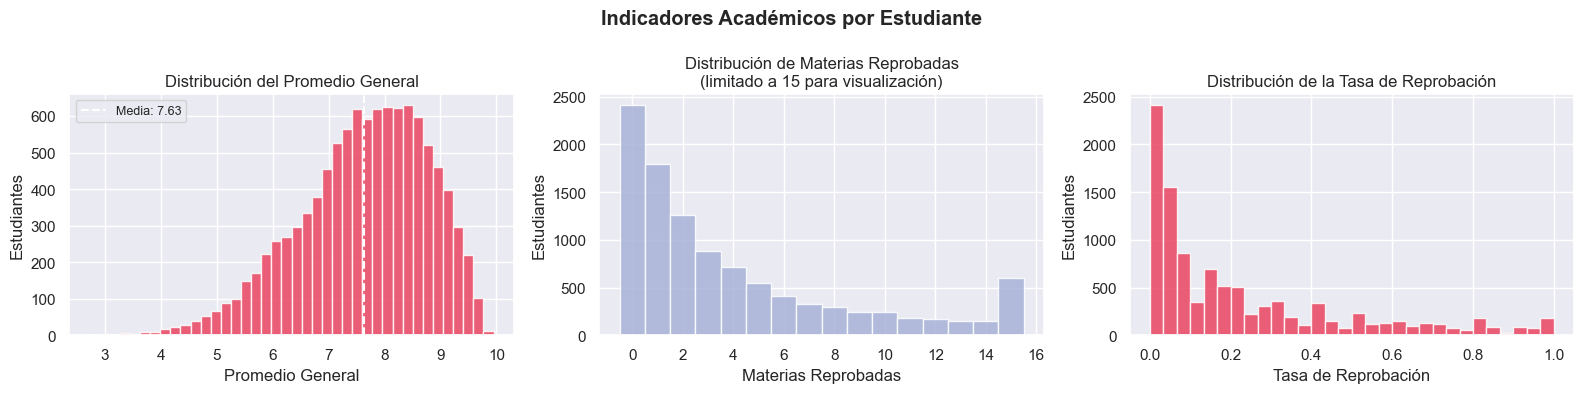

  ℹ️  Estudiantes con 0 reprobadas: 2,410 (23.2%)


In [29]:
# ── Visualización: distribución de los indicadores académicos calculados ──────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Indicadores Académicos por Estudiante', fontweight='bold')

# Histograma de promedio general
axes[0].hist(feat_academico['PROMEDIO_GENERAL'], bins=40,
             color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
axes[0].axvline(feat_academico['PROMEDIO_GENERAL'].mean(), color='white',
                linestyle='--', label=f'Media: {feat_academico["PROMEDIO_GENERAL"].mean():.2f}')
axes[0].set_xlabel('Promedio General')
axes[0].set_ylabel('Estudiantes')
axes[0].set_title('Distribución del Promedio General')
axes[0].legend(fontsize=9)

# Histograma de materias reprobadas (limitado a 0–15 para legibilidad)
rep_data = feat_academico['MATERIAS_REPROBADAS'].clip(upper=15)
axes[1].hist(rep_data, bins=range(0, 17), color=COLOR_NEUTRO, alpha=0.85,
             edgecolor='white', align='left')
axes[1].set_xlabel('Materias Reprobadas')
axes[1].set_ylabel('Estudiantes')
axes[1].set_title('Distribución de Materias Reprobadas\n(limitado a 15 para visualización)')

# Tasa de reprobación
axes[2].hist(feat_academico['TASA_REPROBACION'], bins=30,
             color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
axes[2].set_xlabel('Tasa de Reprobación')
axes[2].set_ylabel('Estudiantes')
axes[2].set_title('Distribución de la Tasa de Reprobación')

plt.tight_layout()
plt.show()
print(f'  ℹ️  Estudiantes con 0 reprobadas: {(feat_academico["MATERIAS_REPROBADAS"]==0).sum():,} '
      f'({(feat_academico["MATERIAS_REPROBADAS"]==0).mean()*100:.1f}%)')

In [30]:
# ── 3.2.2  Features financieras desde PAGFIN ──────────────────────────────────
print('📐  Calculando indicadores financieros...')

feat_financiero = (
    pagfin
    .groupby('SID')
    .agg(
        SALDO_MAX          = ('SALDO', 'max'),
        SALDO_ULTIMO       = ('SALDO', 'last'),
        TOTAL_CARGOS       = ('MONTO', 'count'),
        MONTO_TOTAL        = ('MONTO', 'sum'),
        PERIODOS_CON_SALDO = ('SALDO', lambda x: (x > 0).sum()),
    )
    .reset_index()
)

# Flag: ¿alguna vez tuvo saldo pendiente?
feat_financiero['TUVO_SALDO_PENDIENTE'] = (feat_financiero['SALDO_MAX'] > 0).astype(int)

print(f'  Estudiantes con historial de pagos: {len(feat_financiero):,}')
print(f'  Estudiantes con saldo máximo > $0: {feat_financiero["TUVO_SALDO_PENDIENTE"].sum():,}')
print()
print('  Estadísticas del saldo máximo registrado:')
print(feat_financiero['SALDO_MAX'].describe().round(2).to_string())

📐  Calculando indicadores financieros...
  Estudiantes con historial de pagos: 10,369
  Estudiantes con saldo máximo > $0: 7,714

  Estadísticas del saldo máximo registrado:
count   10,369.00
mean     2,117.84
std      1,694.57
min          0.00
25%          0.00
50%      2,097.66
75%      3,466.34
max      6,153.33


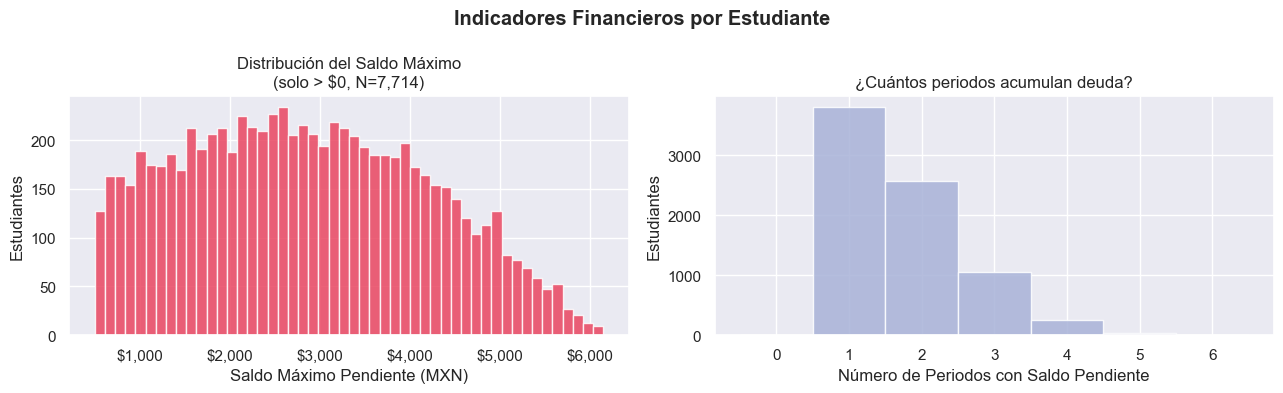

  ℹ️  7,714 estudiantes han tenido al menos un periodo con saldo pendiente (74.4% del total)


In [31]:
# ── Visualización: indicadores financieros calculados ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Indicadores Financieros por Estudiante', fontweight='bold')

# Saldo máximo (log scale para ver la distribución completa)
saldo_pos = feat_financiero[feat_financiero['SALDO_MAX'] > 0]['SALDO_MAX']
axes[0].hist(saldo_pos, bins=50, color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Saldo Máximo Pendiente (MXN)')
axes[0].set_ylabel('Estudiantes')
axes[0].set_title(f'Distribución del Saldo Máximo\n(solo > $0, N={len(saldo_pos):,})')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Periodos con saldo pendiente
pcs = feat_financiero['PERIODOS_CON_SALDO']
axes[1].hist(pcs[pcs > 0], bins=range(0, int(pcs.max())+2),
             color=COLOR_NEUTRO, alpha=0.85, edgecolor='white', align='left')
axes[1].set_xlabel('Número de Periodos con Saldo Pendiente')
axes[1].set_ylabel('Estudiantes')
axes[1].set_title('¿Cuántos periodos acumulan deuda?')

plt.tight_layout()
plt.show()
print(f'  ℹ️  {feat_financiero["TUVO_SALDO_PENDIENTE"].sum():,} estudiantes han tenido '
      f'al menos un periodo con saldo pendiente '
      f'({feat_financiero["TUVO_SALDO_PENDIENTE"].mean()*100:.1f}% del total)')

### 🔎 La historia que cuentan los indicadores

Lo que acabamos de calcular son las dos dimensiones más poderosas del dataset: la académica y la financiera. Cada una, por separado, ya te dice mucho. Pero la magia está en cruzarlas.

Un estudiante con promedio de 9.2 y saldo pendiente de $15,000 no es lo mismo que uno con promedio de 6.5 y saldo en ceros. El primero probablemente tiene talento pero enfrenta presión económica — un candidato perfecto para beca de colegiatura. El segundo quizá paga a tiempo pero está en la cuerda floja académica — y ahí la intervención debería ser de tutoría, no financiera. El modelo que vamos a entrenar más adelante va a aprender justamente esas combinaciones.

In [32]:
# ── 3.2.3  Porcentaje de avance curricular desde PLANACA + CALFIN ─────────────
print('📐  Calculando avance curricular...')

# Total de materias esperadas por programa (desde el catálogo)
total_por_programa = (
    planaca
    .groupby('CVE_PROGRAMA')['CVE_MATERIA']
    .nunique()
    .reset_index()
    .rename(columns={'CVE_MATERIA': 'TOTAL_MATERIAS_PLAN'})
)

# Materias aprobadas únicas por estudiante + programa
aprobadas_unicas = (
    calfin_clean[calfin_clean['APROBADA']]
    .groupby(['SID', 'CVE_PROGRAMA'])['CVE_MATERIA']
    .nunique()
    .reset_index()
    .rename(columns={'CVE_MATERIA': 'MATERIAS_APROBADAS_UNICAS'})
)

# Cruzar con el plan académico
avance = aprobadas_unicas.merge(total_por_programa, on='CVE_PROGRAMA', how='left')
avance['PCT_AVANCE'] = (
    avance['MATERIAS_APROBADAS_UNICAS'] / avance['TOTAL_MATERIAS_PLAN']
).clip(0, 1).round(4)   # clip: no puede ser > 100%

# Nos quedamos con el avance del programa más reciente de cada estudiante
feat_avance = (
    avance
    .sort_values('MATERIAS_APROBADAS_UNICAS', ascending=False)
    .drop_duplicates(subset='SID')
    [['SID', 'PCT_AVANCE', 'MATERIAS_APROBADAS_UNICAS']]
)

print(f'  Estudiantes con avance calculado: {len(feat_avance):,}')
print()
print('  Distribución del porcentaje de avance curricular:')
print(feat_avance['PCT_AVANCE'].describe().round(3).to_string())

📐  Calculando avance curricular...
  Estudiantes con avance calculado: 10,189

  Distribución del porcentaje de avance curricular:
count   10,189.00
mean         0.72
std          0.28
min          0.05
25%          0.55
50%          0.82
75%          0.95
max          1.00


## 3.3 Construcción de DISBEC — Distancia para Beca de Transporte

Aquí resolvemos un problema de georreferenciación: ¿a cuántos kilómetros vive cada estudiante de CESUPOM? La respuesta está en cruzar el código postal con coordenadas aproximadas por municipio y calcular la distancia geodésica.

Como no tenemos SEPOMEX disponible en línea durante el taller, usamos un diccionario de coordenadas centroidales de los municipios más frecuentes del área metropolitana del Valle de México.

In [33]:
# ── Diccionario de coordenadas por municipio (área metropolitana CDMX) ─────────
# Fuente: INEGI, centroides municipales aproximados
# Se expande según los municipios que aparezcan en DOMICOM

COORDS_MUNICIPIO = {
    # Ciudad de México — Alcaldías
    'Álvaro Obregón'      : (19.3594, -99.1936),
    'Azcapotzalco'        : (19.4870, -99.1850),
    'Benito Juárez'       : (19.3984, -99.1591),
    'Coyoacán'            : (19.3467, -99.1617),
    'Cuajimalpa'          : (19.3600, -99.2986),
    'Cuauhtémoc'          : (19.4269, -99.1435),
    'Gustavo A. Madero'   : (19.4895, -99.1161),
    'Iztacalco'           : (19.3951, -99.1139),
    'Iztapalapa'          : (19.3553, -99.0638),
    'La Magdalena Contreras': (19.3200, -99.2300),
    'Miguel Hidalgo'      : (19.4270, -99.1958),
    'Milpa Alta'          : (19.1900, -98.9700),
    'Tláhuac'             : (19.2958, -99.0081),
    'Tlalpan'             : (19.2953, -99.1695),
    'Venustiano Carranza' : (19.4280, -99.1020),
    'Xochimilco'          : (19.2567, -99.1047),
    # Estado de México
    'Atizapán de Zaragoza': (19.5692, -99.2706),
    'Chalco'              : (19.2617, -98.8975),
    'Chimalhuacán'        : (19.4183, -98.9500),
    'Coacalco de Berriozábal': (19.6228, -99.0986),
    'Cuautitlán Izcalli'  : (19.6469, -99.2183),
    'Ecatepec de Morelos' : (19.6017, -99.0508),
    'Huixquilucan'        : (19.3658, -99.3622),
    'Ixtapaluca'          : (19.3175, -98.8828),
    'La Paz'              : (19.3636, -98.9714),
    'Los Reyes Acaquilpan': (19.3636, -98.9714),
    'Naucalpan de Juárez' : (19.4742, -99.2381),
    'Nezahualcóyotl'      : (19.4014, -99.0147),
    'Nicolás Romero'      : (19.6372, -99.3044),
    'Tecámac'             : (19.7142, -98.9708),   # ← sede del CESUPOM
    'Texcoco'             : (19.5133, -98.8817),
    'Tlalnepantla de Baz' : (19.5406, -99.1953),
    'Tultitlán'           : (19.6461, -99.1722),
    'Valle de Chalco Solidaridad': (19.2939, -98.9600),
    # Hidalgo
    'Tizayuca'            : (20.0956, -98.9742),
    'Tepeapulco'          : (19.7900, -98.5500),
}

print(f'✅  Diccionario cargado: {len(COORDS_MUNICIPIO)} municipios registrados.')

✅  Diccionario cargado: 36 municipios registrados.


In [34]:
# ── Cálculo de distancia geodésica y construcción de DISBEC ──────────────────
print('📍  Construyendo DISBEC...')

def calcular_distancia(municipio: str) -> float:
    """Devuelve la distancia en km entre el municipio dado y CESUPOM (Tecámac).
    Retorna NaN si el municipio no está en el diccionario."""
    coords = COORDS_MUNICIPIO.get(municipio)
    if coords is None:
        return np.nan
    return round(haversine(coords, (LAT_CESUPOM, LON_CESUPOM), unit=Unit.KILOMETERS), 2)

disbec = domicom_clean[domicom_clean['CP_VALIDO']].copy()

# Limpiar nombres de municipio para mejorar el match
disbec['MUNICIPIO_CLEAN'] = disbec['MUNICIPIO'].str.strip().str.title()

disbec['DISTANCIA_KM']    = disbec['MUNICIPIO_CLEAN'].apply(calcular_distancia)
disbec['CP_INSTITUCION']  = CP_CESUPOM
disbec['METODO_CALCULO']  = 'GEODESICA_CENTROIDE_MUNICIPIO'
disbec['FUENTE_DATOS']    = 'INEGI_CENTROIDES_2024'

disbec = disbec.rename(columns={'CP': 'CP_ESTUDIANTE'})
disbec = disbec[['SID', 'CP_ESTUDIANTE', 'CP_INSTITUCION',
                  'DISTANCIA_KM', 'METODO_CALCULO', 'FUENTE_DATOS']]

n_con_dist = disbec['DISTANCIA_KM'].notna().sum()
n_sin_dist = disbec['DISTANCIA_KM'].isna().sum()

print(f'  Registros en DISBEC: {len(disbec):,}')
print(f'  Con distancia calculada: {n_con_dist:,}')
print(f'  Sin distancia (municipio no mapeado): {n_sin_dist:,}')
print()
print('  Estadísticas de distancia (km):')
print(disbec['DISTANCIA_KM'].describe().round(2).to_string())

print()
print('  Vista previa de DISBEC:')
disbec.head()

📍  Construyendo DISBEC...
  Registros en DISBEC: 10,167
  Con distancia calculada: 7,998
  Sin distancia (municipio no mapeado): 2,169

  Estadísticas de distancia (km):
count   7,998.00
mean       42.12
std         8.79
min        22.40
25%        35.08
50%        41.08
75%        50.90
max        58.29

  Vista previa de DISBEC:


,SID,CP_ESTUDIANTE,CP_INSTITUCION,DISTANCIA_KM,METODO_CALCULO,FUENTE_DATOS
0,1,03100,55740,45.50,GEODESICA_CENTROIDE_MUNICIPIO,INEGI_CENTROIDES_2024
1,2,06300,55740,52.26,GEODESICA_CENTROIDE_MUNICIPIO,INEGI_CENTROIDES_2024
2,3,50140,55740,38.99,GEODESICA_CENTROIDE_MUNICIPIO,INEGI_CENTROIDES_2024
3,4,15040,55740,52.26,GEODESICA_CENTROIDE_MUNICIPIO,INEGI_CENTROIDES_2024
4,5,08400,55740,52.26,GEODESICA_CENTROIDE_MUNICIPIO,INEGI_CENTROIDES_2024


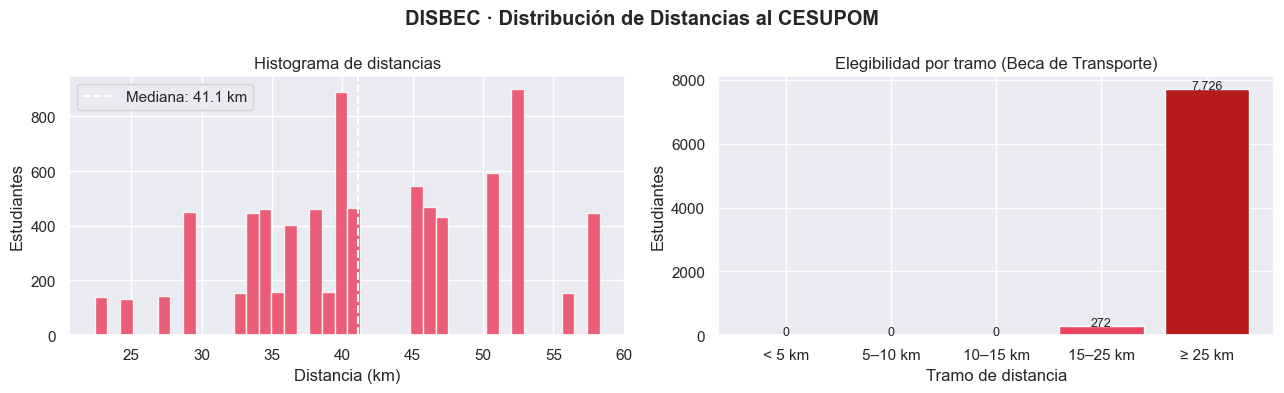

In [35]:
# ── Visualización de la distribución de distancias ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('DISBEC · Distribución de Distancias al CESUPOM', fontweight='bold')

dist_validas = disbec['DISTANCIA_KM'].dropna()

# Histograma
axes[0].hist(dist_validas, bins=40, color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
axes[0].axvline(dist_validas.median(), color='white', linestyle='--',
                label=f'Mediana: {dist_validas.median():.1f} km')
axes[0].set_xlabel('Distancia (km)')
axes[0].set_ylabel('Estudiantes')
axes[0].set_title('Histograma de distancias')
axes[0].legend()

# Tramos para beca de transporte según REGBEC
tramos = ['< 5 km', '5–10 km', '10–15 km', '15–25 km', '≥ 25 km']
counts = [
    (dist_validas < 5).sum(),
    ((dist_validas >= 5) & (dist_validas < 10)).sum(),
    ((dist_validas >= 10) & (dist_validas < 15)).sum(),
    ((dist_validas >= 15) & (dist_validas < 25)).sum(),
    (dist_validas >= 25).sum(),
]
colores_tramo = ['#cccccc','#a8b2d8','#7986cb','#e94560','#b71c1c']
axes[1].bar(tramos, counts, color=colores_tramo, edgecolor='white')
axes[1].set_xlabel('Tramo de distancia')
axes[1].set_ylabel('Estudiantes')
axes[1].set_title('Elegibilidad por tramo (Beca de Transporte)')
for i, v in enumerate(counts):
    axes[1].text(i, v + 15, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('disbec_distancias.png', dpi=120, bbox_inches='tight')
plt.show()

## 3.4 Construcción de SOLBEC — Solicitudes Estructuradas

El cuestionario tiene 38 columnas con códigos como `P30116` y `P40321`. Útil para un formulario, imposible para un analista. Aquí lo transformamos en una tabla operativa con nombres legibles, lo cruzamos con la base institucional para validar lo declarado y mapeamos las claves de beca.

In [36]:
# ── 3.4.1  Renombrar columnas del cuestionario a nombres operativos ────────────
print('📋  Construyendo SOLBEC...')

RENOMBRAR = {
    'P10101': 'MATRICULA',
    'P10202': 'AP_PATERNO',
    'P10303': 'AP_MATERNO',
    'P10404': 'NOMBRE',
    'P10505': 'CORREO_INST',
    'P10606': 'CORREO_PERS',
    'P10707': 'TELEFONO',
    'P10808': 'FECHA_SOLICITUD',
    'P20109': 'PROGRAMA_DECL',
    'P20210': 'CVE_PROGRAMA_DECL',
    'P20311': 'SEMESTRE_ACTUAL',
    'P20412': 'REPROBO_MATERIA',
    'P20513': 'NUM_REPROBADAS_DECL',
    'P20614': 'CONSIDERO_ABANDONAR',
    'P20715': 'RAZON_ABANDONO',
    'P30116': 'TIPO_BECA_SOL',
    'P30217': 'PROMEDIO_DECL',
    'P30318': 'CP_DECL',
    'P40119': 'CON_QUIEN_VIVE',
    'P40220': 'NUM_DEPENDIENTES',
    'P40321': 'INGRESO_HOGAR',
    'P40422': 'FUENTE_INGRESO',
    'P40523': 'TRABAJA',
    'P40624': 'HORAS_TRABAJO',
    'P40725': 'TRABAJO_AFIN',
    'P50126': 'COMO_FINANCIA',
    'P50227': 'BECA_EXTERNA',
    'P50328': 'DETALLE_BECA_EXT',
    'P50429': 'GASTO_TRANSPORTE',
    'P50530': 'DEJO_PAGAR',
    'P50631': 'ACCESO_TECNOLOGIA',
    'P60132': 'ESCOLARIDAD_MADRE',
    'P60233': 'ESCOLARIDAD_PADRE',
    'P60334': 'PRIMERA_GEN',
    'P60435': 'ORIENTACION_FAM',
    'P70136': 'AUTORIZA_HISTORIAL',
    'P70237': 'INFO_VERIDICA',
    'P70338': 'DOCS_COMPLETOS',
}

solbec = cuestionario.rename(columns=RENOMBRAR).copy()

# Mapear tipo de beca declarada → CVE_BECA del catálogo
BECA_MAP = {
    'Beca de inscripción/reinscripción' : 'BEC001',
    'Beca de colegiatura'               : 'BEC003',
    'Beca de transporte'                : 'BEC004',
}
solbec['CVE_BECA'] = solbec['TIPO_BECA_SOL'].map(BECA_MAP)

# Mapear ingreso del hogar a valor numérico (punto medio del rango)
INGRESO_NUM = {
    'Menos de $5,000'  : 2500,
    '$5,001-$10,000'   : 7500,
    '$10,001-$15,000'  : 12500,
    '$15,001-$25,000'  : 20000,
    'Más de $25,000'   : 30000,
}
solbec['INGRESO_HOGAR_NUM'] = solbec['INGRESO_HOGAR'].map(INGRESO_NUM)

# Binarios de texto → 0/1
SINO_MAP = {'Sí': 1, 'No': 0, 'NA': np.nan}
for col in ['REPROBO_MATERIA', 'CONSIDERO_ABANDONAR', 'TRABAJA',
            'BECA_EXTERNA', 'DEJO_PAGAR', 'PRIMERA_GEN',
            'ORIENTACION_FAM', 'AUTORIZA_HISTORIAL', 'INFO_VERIDICA', 'DOCS_COMPLETOS']:
    solbec[col + '_BIN'] = solbec[col].map(SINO_MAP)

# Horas de trabajo y dependientes a numérico
solbec['HORAS_TRABAJO']     = pd.to_numeric(solbec['HORAS_TRABAJO'],     errors='coerce')
solbec['GASTO_TRANSPORTE']  = pd.to_numeric(solbec['GASTO_TRANSPORTE'],  errors='coerce')
solbec['PROMEDIO_DECL']     = pd.to_numeric(solbec['PROMEDIO_DECL'],     errors='coerce')
solbec['NUM_DEPENDIENTES']  = pd.to_numeric(solbec['NUM_DEPENDIENTES'],  errors='coerce')
solbec['NUM_REPROBADAS_DECL'] = pd.to_numeric(solbec['NUM_REPROBADAS_DECL'], errors='coerce')
solbec['SEMESTRE_ACTUAL']   = pd.to_numeric(solbec['SEMESTRE_ACTUAL'],   errors='coerce')

print(f'  Solicitudes en SOLBEC: {len(solbec):,}')
print(f'  Columnas operativas: {solbec.shape[1]}')
print()
print('  Distribución por CVE_BECA:')
print(solbec['CVE_BECA'].value_counts().to_string())

📋  Construyendo SOLBEC...
  Solicitudes en SOLBEC: 7,777
  Columnas operativas: 50

  Distribución por CVE_BECA:
CVE_BECA
BEC001    3363
BEC003    2852
BEC004    1562


In [37]:
# ── 3.4.2  Vincular SOLBEC con la Base Institucional (via MATRICULA) ──────────
print('🔗  Cruzando SOLBEC con Base Institucional...')

# El historial académico más reciente de cada estudiante
histaca_reciente = (
    histaca_clean
    .sort_values('PERIODO', ascending=False)
    .drop_duplicates(subset='MATRICULA')
    [['SID', 'MATRICULA', 'CVE_PROGRAMA', 'ESTADO', 'PERIODO']]
)

# Join principal: SOLBEC ← HISTACA (para obtener SID)
solbec = solbec.merge(
    histaca_reciente,
    left_on='MATRICULA', right_on='MATRICULA',
    how='left'
)

n_match = solbec['SID'].notna().sum()
n_no_match = solbec['SID'].isna().sum()
print(f'  Solicitudes con SID institucional: {n_match:,}')
print(f'  Solicitudes sin match institucional: {n_no_match:,}')
print()

# Agregar indicadores académicos y financieros calculados antes
solbec = solbec.merge(feat_academico[['SID','PROMEDIO_GENERAL','MATERIAS_REPROBADAS',
                                       'TOTAL_MATERIAS','TASA_REPROBACION']],
                      on='SID', how='left')
solbec = solbec.merge(feat_financiero[['SID','SALDO_MAX','SALDO_ULTIMO',
                                        'TUVO_SALDO_PENDIENTE','PERIODOS_CON_SALDO']],
                      on='SID', how='left')
solbec = solbec.merge(feat_avance[['SID','PCT_AVANCE']], on='SID', how='left')
solbec = solbec.merge(disbec[['SID','DISTANCIA_KM']], on='SID', how='left')

print(f'  SOLBEC enriquecida: {solbec.shape[0]:,} solicitudes × {solbec.shape[1]} columnas')
print()
print('  Vista previa:')
solbec[['MATRICULA','CVE_BECA','ESTADO','PROMEDIO_GENERAL',
        'MATERIAS_REPROBADAS','SALDO_MAX','DISTANCIA_KM']].head()

🔗  Cruzando SOLBEC con Base Institucional...
  Solicitudes con SID institucional: 7,777
  Solicitudes sin match institucional: 0

  SOLBEC enriquecida: 7,777 solicitudes × 64 columnas

  Vista previa:


,MATRICULA,CVE_BECA,ESTADO,PROMEDIO_GENERAL,MATERIAS_REPROBADAS,SALDO_MAX,DISTANCIA_KM
0,2024C02876,BEC004,Activo,7.41,3,"1,961.02",NaN
1,2024B06753,BEC001,Activo,6.53,5,0.00,38.52
2,2021A04582,BEC003,Egresado,9.53,0,"4,176.52",NaN
3,2022B06025,BEC001,Egresado,8.72,2,"1,538.22",46.69
4,2024B00553,BEC001,Activo,8.91,0,"3,402.87",33.79


In [38]:
# ── 3.4.3  Auditoría: ¿coincide lo declarado con lo institucional? ────────────
print('🔍  Auditoría de consistencia declarado vs. institucional...')

# Solo comparamos las solicitudes que tienen promedio declarado y promedio real
mask_colegiatura = (
    solbec['CVE_BECA'].eq('BEC003') &
    solbec['PROMEDIO_DECL'].notna() &
    solbec['PROMEDIO_GENERAL'].notna()
)
comp = solbec[mask_colegiatura][['MATRICULA','PROMEDIO_DECL','PROMEDIO_GENERAL']].copy()
comp['DIFF_PROMEDIO']   = (comp['PROMEDIO_DECL'] - comp['PROMEDIO_GENERAL']).round(2)
comp['SOBREESTIMA']     = comp['DIFF_PROMEDIO'] > 0.5   # umbral: > 0.5 pts de diferencia

n_sob = comp['SOBREESTIMA'].sum()
print(f'  Solicitudes de colegiatura comparables: {len(comp):,}')
print(f'  Casos donde el promedio declarado supera el real en > 0.5 pts: {n_sob:,}')
print(f'  Porcentaje: {n_sob/len(comp)*100:.1f}%')
print()
print('  Estadísticas de la diferencia (declarado − real):')
print(comp['DIFF_PROMEDIO'].describe().round(2).to_string())
print()
print('  ⚠️  Estos son exactamente los casos que el evaluador de becas debería revisar.')

🔍  Auditoría de consistencia declarado vs. institucional...
  Solicitudes de colegiatura comparables: 2,852
  Casos donde el promedio declarado supera el real en > 0.5 pts: 0
  Porcentaje: 0.0%

  Estadísticas de la diferencia (declarado − real):
count   2,852.00
mean       -0.00
std         0.03
min        -0.05
25%        -0.03
50%         0.00
75%         0.02
max         0.05

  ⚠️  Estos son exactamente los casos que el evaluador de becas debería revisar.


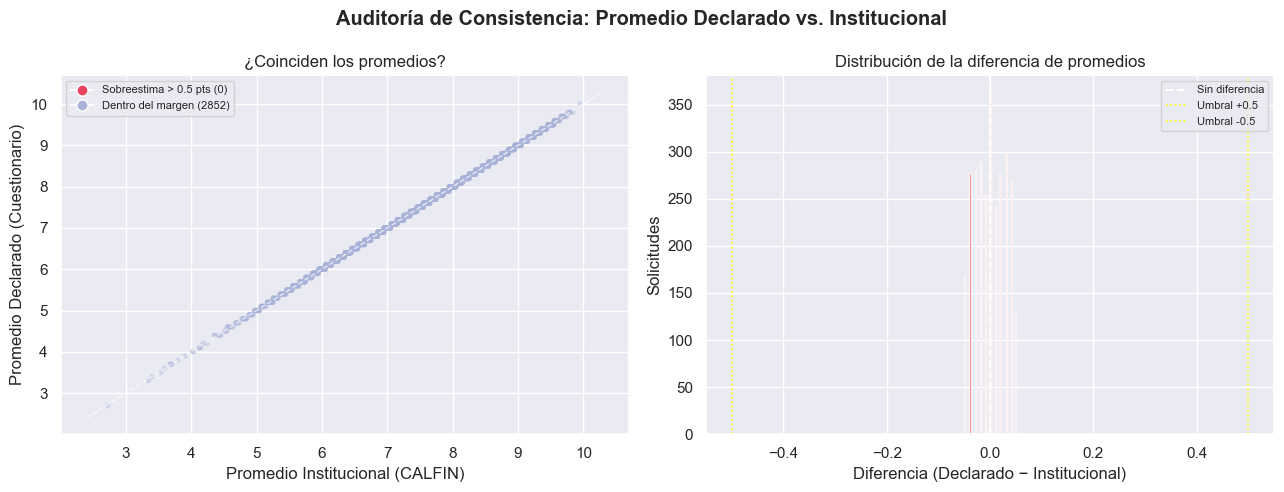

In [39]:
# ── Visualización: promedio declarado vs. promedio institucional ──────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Auditoría de Consistencia: Promedio Declarado vs. Institucional',
             fontweight='bold')

# Scatter: declarado vs real
ax = axes[0]
ax.scatter(comp['PROMEDIO_GENERAL'], comp['PROMEDIO_DECL'],
           c=comp['SOBREESTIMA'].map({True: COLOR_ACENTO, False: COLOR_NEUTRO}),
           alpha=0.4, s=15, edgecolors='none')
# Línea de igualdad perfecta (y = x)
lim_min = min(comp['PROMEDIO_GENERAL'].min(), comp['PROMEDIO_DECL'].min()) - 0.3
lim_max = max(comp['PROMEDIO_GENERAL'].max(), comp['PROMEDIO_DECL'].max()) + 0.3
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'w--', linewidth=1, alpha=0.7,
        label='Línea de igualdad (declarado = real)')
ax.set_xlabel('Promedio Institucional (CALFIN)')
ax.set_ylabel('Promedio Declarado (Cuestionario)')
ax.set_title('¿Coinciden los promedios?')
ax.legend(fontsize=8)

# Leyenda
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_ACENTO,
           markersize=8, label=f'Sobreestima > 0.5 pts ({n_sob})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_NEUTRO,
           markersize=8, label=f'Dentro del margen ({len(comp)-n_sob})'),
]
ax.legend(handles=leyenda, fontsize=8, loc='upper left')

# Histograma de la diferencia
axes[1].hist(comp['DIFF_PROMEDIO'], bins=40, color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='white', linestyle='--', linewidth=1.5, label='Sin diferencia')
axes[1].axvline(0.5, color='yellow', linestyle=':', linewidth=1.2, label='Umbral +0.5')
axes[1].axvline(-0.5, color='yellow', linestyle=':', linewidth=1.2, label='Umbral -0.5')
axes[1].set_xlabel('Diferencia (Declarado − Institucional)')
axes[1].set_ylabel('Solicitudes')
axes[1].set_title('Distribución de la diferencia de promedios')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 🔎 Las discrepancias no siempre son fraude

Este cruce entre lo que el estudiante *dice* y lo que la institución *registra* es uno de los ejercicios más reveladores del taller. La mayoría de los estudiantes declara un promedio muy cercano al real — lo cual es una buena señal de que el formulario funciona razonablemente bien.

Pero los casos donde el promedio declarado supera al institucional en más de medio punto merecen atención. No necesariamente son fraude: a veces el estudiante recuerda su promedio del último periodo (que pudo ser más alto) y no el acumulado completo. O simplemente redondea hacia arriba por optimismo natural. El punto es que un sistema automático de evaluación de becas *debe* usar el dato institucional como fuente de verdad, no el declarado. Y eso es exactamente lo que hace nuestro motor de evaluación en la Sección 5.

## 3.5 Ingeniería de Features y Dataset Analítico Final

Ahora construimos el dataset que va a entrar al modelo. La variable objetivo es `RIESGO_DESERCION`: un estudiante está en riesgo si su estado académico es `Baja Definitiva` o `Baja Temporal`. Todo lo demás son las señales que el modelo aprenderá a interpretar.

In [40]:
# ── 3.5.1  Construir el dataset analítico desde la base institucional ──────────
print('🏗️  Ensamblando dataset analítico...')

# Partimos del historial académico más reciente por estudiante
base = (
    histaca_clean
    .sort_values('PERIODO', ascending=False)
    .drop_duplicates(subset='SID')
    [['SID','MATRICULA','CVE_PROGRAMA','ESTADO','PERIODO']]
    .copy()
)

# Variable objetivo — Baja Definitiva o Baja Temporal = en riesgo
ESTADOS_RIESGO = {'Baja Definitiva', 'Baja Temporal'}
base['RIESGO_DESERCION'] = base['ESTADO'].isin(ESTADOS_RIESGO).astype(int)

# Unir todos los features calculados
df = (
    base
    .merge(infcom_clean[['SID','GENERO']], on='SID', how='left')
    .merge(feat_academico, on='SID', how='left')
    .merge(feat_financiero, on='SID', how='left')
    .merge(feat_avance[['SID','PCT_AVANCE']], on='SID', how='left')
    .merge(disbec[['SID','DISTANCIA_KM']], on='SID', how='left')
)

# Enriquecer con datos del cuestionario (para quienes solicitaron beca)
solbec_cols = ['SID','INGRESO_HOGAR_NUM','NUM_DEPENDIENTES','TRABAJA_BIN',
               'HORAS_TRABAJO','DEJO_PAGAR_BIN','CONSIDERO_ABANDONAR_BIN',
               'PRIMERA_GEN_BIN','GASTO_TRANSPORTE','SEMESTRE_ACTUAL']
df = df.merge(
    solbec[solbec_cols].drop_duplicates(subset='SID'),
    on='SID', how='left'
)

print(f'  Dataset ensamblado: {df.shape[0]:,} estudiantes × {df.shape[1]} columnas')
print(f'  Con RIESGO_DESERCION = 1: {df["RIESGO_DESERCION"].sum():,}')
print(f'  Con RIESGO_DESERCION = 0: {(df["RIESGO_DESERCION"] == 0).sum():,}')
print(f'  Tasa de deserción en el dataset: {df["RIESGO_DESERCION"].mean()*100:.1f}%')

🏗️  Ensamblando dataset analítico...
  Dataset ensamblado: 10,369 estudiantes × 30 columnas
  Con RIESGO_DESERCION = 1: 1,510
  Con RIESGO_DESERCION = 0: 8,859
  Tasa de deserción en el dataset: 14.6%


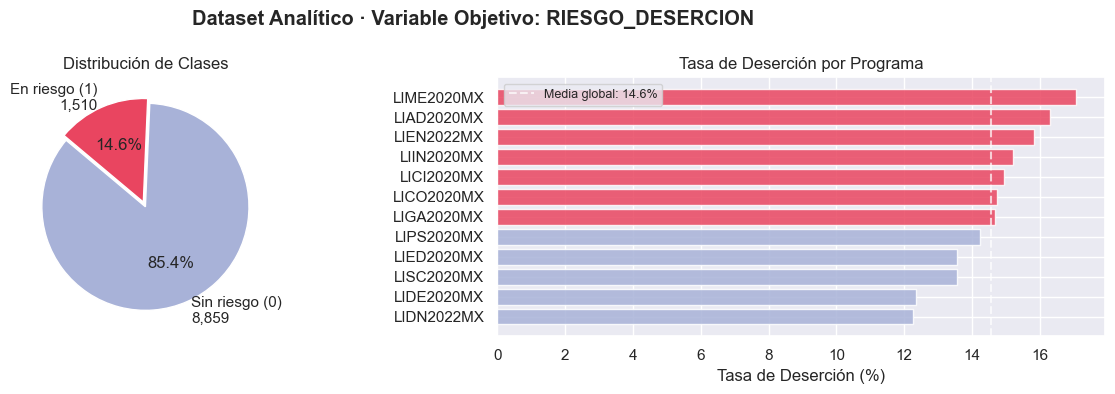

In [41]:
# ── Visualización: balance de clases en la variable objetivo ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Dataset Analítico · Variable Objetivo: RIESGO_DESERCION', fontweight='bold')

# Pie de clases
class_counts = df['RIESGO_DESERCION'].value_counts()
labels_class = [f'Sin riesgo (0)\n{class_counts[0]:,}', f'En riesgo (1)\n{class_counts[1]:,}']
axes[0].pie(class_counts.values, labels=labels_class,
            colors=[COLOR_NEUTRO, COLOR_ACENTO], autopct='%1.1f%%',
            startangle=140, explode=[0, 0.05])
axes[0].set_title('Distribución de Clases')

# Tasa de deserción por programa
tasa_prog = (
    df.groupby('CVE_PROGRAMA')['RIESGO_DESERCION']
    .mean()
    .sort_values(ascending=False)
    * 100
)
colores_tp = [COLOR_ACENTO if v > df['RIESGO_DESERCION'].mean()*100
              else COLOR_NEUTRO for v in tasa_prog.values]
axes[1].barh(tasa_prog.index, tasa_prog.values, color=colores_tp, alpha=0.85)
axes[1].axvline(df['RIESGO_DESERCION'].mean()*100, color='white',
                linestyle='--', alpha=0.7, label=f'Media global: {df["RIESGO_DESERCION"].mean()*100:.1f}%')
axes[1].set_xlabel('Tasa de Deserción (%)')
axes[1].set_title('Tasa de Deserción por Programa')
axes[1].legend(fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 🔎 El desbalance de clases: un reto real para el modelo

Aquí hay algo que no se puede ignorar: la clase positiva (estudiantes que realmente desertaron) es mucho más pequeña que la clase negativa. Eso es lo que en machine learning llamamos *desbalance de clases*, y si no lo manejamos, el modelo va a aprender el camino fácil: predecir "sin riesgo" para todo el mundo y obtener una accuracy engañosamente alta.

Por eso, en la Sección 4, vamos a usar `class_weight='balanced'` en el Random Forest y pesos de clase proporcionales en la red neuronal. Eso le dice al modelo: "cuando te equivoques con un estudiante en riesgo, eso cuenta *más* que equivocarte con uno que no está en riesgo". Es una decisión deliberada que refleja el costo asimétrico del error: perder a un estudiante que podías retener es peor que dar una beca a alguien que no la necesitaba tanto.

La tabla de tasa de deserción por programa también es clave: si un programa tiene el doble de deserción que otro, el modelo debería captar esa señal — pero sin convertirla en una profecía autocumplida donde a ciertos programas "les toca" más deserción.

In [42]:
# ── 3.5.2  Variables derivadas adicionales ────────────────────────────────────

# Codificar género (M=1, F=0, resto=NaN)
df['GENERO_M'] = df['GENERO'].map({'M': 1, 'F': 0})

# Programa de nivel posgrado
df['ES_POSGRADO'] = df['CVE_PROGRAMA'].isin(POSGRADOS).astype(int)

# Flag: promedio bajo (< 7.0 en licenciatura, < 8.5 en posgrado)
df['PROMEDIO_BAJO'] = np.where(
    df['ES_POSGRADO'] == 1,
    (df['PROMEDIO_GENERAL'] < 8.5).astype(int),
    (df['PROMEDIO_GENERAL'] < 7.0).astype(int)
)

# Índice de vulnerabilidad económica compuesto (0–3)
df['IDX_VULNERABILIDAD'] = (
    (df['INGRESO_HOGAR_NUM'] <= 7500).fillna(0).astype(int) +
    df['TUVO_SALDO_PENDIENTE'].fillna(0).astype(int) +
    df['DEJO_PAGAR_BIN'].fillna(0).astype(int)
)

print('✅  Features adicionales creados:')
print('  GENERO_M, ES_POSGRADO, PROMEDIO_BAJO, IDX_VULNERABILIDAD')
print()
print('  Distribución del índice de vulnerabilidad económica:')
print(df['IDX_VULNERABILIDAD'].value_counts().sort_index().to_string())

✅  Features adicionales creados:
  GENERO_M, ES_POSGRADO, PROMEDIO_BAJO, IDX_VULNERABILIDAD

  Distribución del índice de vulnerabilidad económica:
IDX_VULNERABILIDAD
0    1361
1    4633
2    3024
3    1351


In [43]:
# ── 3.5.3  Selección de features para modelado y tratamiento de nulos ─────────

FEATURES = [
    # Académicos
    'PROMEDIO_GENERAL',
    'MATERIAS_REPROBADAS',
    'TASA_REPROBACION',
    'PCT_AVANCE',
    'PROMEDIO_BAJO',
    # Financieros
    'SALDO_MAX',
    'SALDO_ULTIMO',
    'TUVO_SALDO_PENDIENTE',
    'PERIODOS_CON_SALDO',
    # Socioeconómicos (del cuestionario)
    'INGRESO_HOGAR_NUM',
    'NUM_DEPENDIENTES',
    'TRABAJA_BIN',
    'HORAS_TRABAJO',
    'DEJO_PAGAR_BIN',
    'PRIMERA_GEN_BIN',
    'IDX_VULNERABILIDAD',
    # Geográfico
    'DISTANCIA_KM',
    # Demográfico / Institucional
    'GENERO_M',
    'ES_POSGRADO',
    'SEMESTRE_ACTUAL',
]

TARGET = 'RIESGO_DESERCION'

df_model = df[FEATURES + [TARGET, 'SID', 'MATRICULA', 'CVE_PROGRAMA']].copy()

# Imputación de nulos: mediana para numéricos
for col in FEATURES:
    mediana = df_model[col].median()
    n_null  = df_model[col].isna().sum()
    if n_null > 0:
        df_model[col] = df_model[col].fillna(mediana)

print(f'✅  Dataset analítico final:')
print(f'   {df_model.shape[0]:,} estudiantes × {len(FEATURES)} features + 1 target')
print(f'   Nulos restantes: {df_model[FEATURES].isna().sum().sum()}')
print()
print('  Primeras filas:')
df_model[FEATURES[:6] + [TARGET]].head()

✅  Dataset analítico final:
   10,369 estudiantes × 20 features + 1 target
   Nulos restantes: 0

  Primeras filas:


,PROMEDIO_GENERAL,MATERIAS_REPROBADAS,TASA_REPROBACION,PCT_AVANCE,PROMEDIO_BAJO,SALDO_MAX,RIESGO_DESERCION
0,8.01,0,0.00,0.55,0,"1,861.36",0
1,6.55,9,0.41,0.59,1,"2,939.25",0
2,7.27,4,0.20,0.73,0,0.00,0
3,5.24,15,0.75,0.25,1,"2,461.91",0
4,8.83,2,0.10,0.90,0,0.00,0


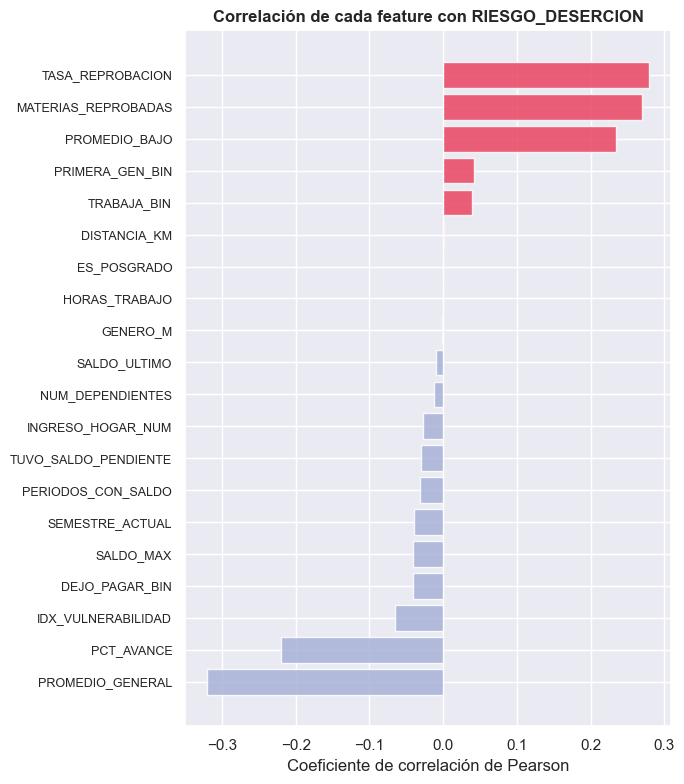

  ℹ️  Rojo = correlación positiva con deserción · Azul = correlación negativa


In [44]:
# ── 3.5.4  Mapa de correlaciones con la variable objetivo ─────────────────────
corr = df_model[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(7, 8))
colores = [COLOR_ACENTO if v > 0 else COLOR_NEUTRO for v in corr.values]
ax.barh(corr.index, corr.values, color=colores, alpha=0.85, edgecolor='white')
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.set_title('Correlación de cada feature con RIESGO_DESERCION',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Coeficiente de correlación de Pearson')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('correlaciones_target.png', dpi=120, bbox_inches='tight')
plt.show()
print('  ℹ️  Rojo = correlación positiva con deserción · Azul = correlación negativa')

### 🔎 Leyendo el mapa de correlaciones

Este gráfico es una de las herramientas más útiles para tener una intuición *antes* de entrenar cualquier modelo. Las barras rojas (correlación positiva con deserción) te dicen qué variables *empujan* hacia la deserción, y las azules (correlación negativa) te dicen cuáles *protegen*.

Si las variables financieras como `SALDO_MAX`, `TUVO_SALDO_PENDIENTE` o `PERIODOS_CON_SALDO` aparecen con correlación positiva alta, eso confirma la intuición de que la presión económica es un predictor fuerte. Por otro lado, si `PCT_AVANCE` o `PROMEDIO_GENERAL` tienen correlación negativa, significa que a mayor avance y mejor rendimiento, menor riesgo — lo cual tiene sentido: un estudiante que ya aprobó el 80% de su carrera tiene muchos incentivos para terminarla.

Pero cuidado: la correlación de Pearson solo mide relaciones *lineales*. Puede haber relaciones no lineales que este gráfico no captura — por eso entrenamos un Random Forest, que sí puede detectarlas.

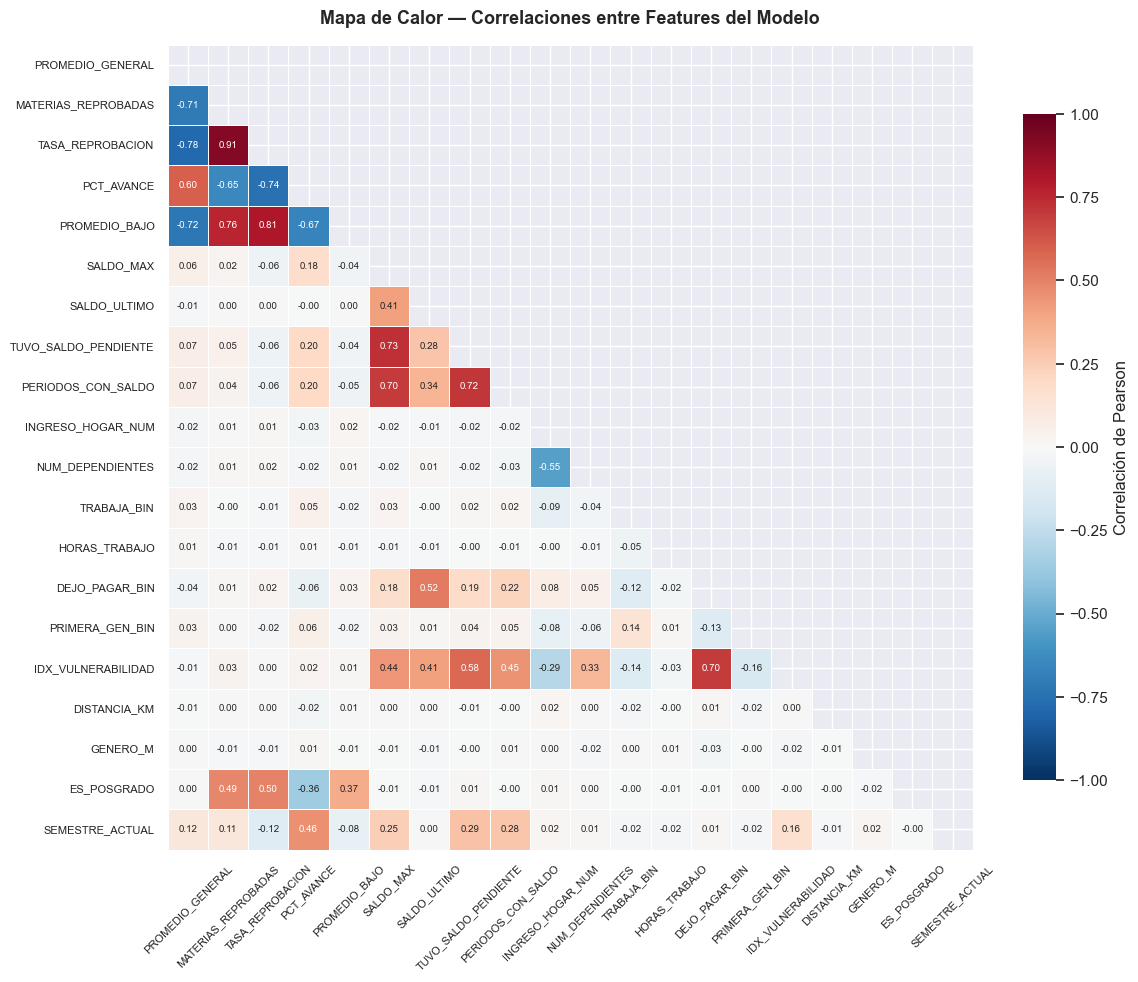

  ⚠️  Pares de features con correlación > 0.60:
     MATERIAS_REPROBADAS          ↔ TASA_REPROBACION             r = 0.915
     TASA_REPROBACION             ↔ PROMEDIO_BAJO                r = 0.809
     PROMEDIO_GENERAL             ↔ TASA_REPROBACION             r = -0.784
     MATERIAS_REPROBADAS          ↔ PROMEDIO_BAJO                r = 0.764
     TASA_REPROBACION             ↔ PCT_AVANCE                   r = -0.745
     SALDO_MAX                    ↔ TUVO_SALDO_PENDIENTE         r = 0.733
     PROMEDIO_GENERAL             ↔ PROMEDIO_BAJO                r = -0.721
     TUVO_SALDO_PENDIENTE         ↔ PERIODOS_CON_SALDO           r = 0.715
     PROMEDIO_GENERAL             ↔ MATERIAS_REPROBADAS          r = -0.710
     DEJO_PAGAR_BIN               ↔ IDX_VULNERABILIDAD           r = 0.701
     SALDO_MAX                    ↔ PERIODOS_CON_SALDO           r = 0.697
     PCT_AVANCE                   ↔ PROMEDIO_BAJO                r = -0.666
     MATERIAS_REPROBADAS          ↔ PCT_AVANCE 

In [45]:
# ── 3.5.5  Heatmap de correlaciones entre features ────────────────────────────
# Además de la correlación con el target, vale la pena ver cómo se relacionan
# los features entre sí. Si dos variables están muy correlacionadas (> 0.8),
# una de las dos es redundante y puede confundir al modelo.

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_model[FEATURES].corr()

# Máscara para mostrar solo el triángulo inferior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Mapa de Calor — Correlaciones entre Features del Modelo',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('heatmap_correlaciones.png', dpi=120, bbox_inches='tight')
plt.show()

# Identificar pares altamente correlacionados
pares_altos = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val > 0.60:
            pares_altos.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if pares_altos:
    print('  ⚠️  Pares de features con correlación > 0.60:')
    for f1, f2, r in sorted(pares_altos, key=lambda x: abs(x[2]), reverse=True):
        print(f'     {f1:<28} ↔ {f2:<28} r = {r:.3f}')
else:
    print('  ✅  No se encontraron pares con correlación > 0.60.')

print()
print('  ℹ️  Variables altamente correlacionadas pueden causar multicolinealidad.')
print('      En Random Forest no es tan grave, pero en regresión logística o redes')
print('      neuronales puede inflar la varianza de los coeficientes.')

---
# 🤖 Sección 4 — Modelado: Random Forest vs. Red Neuronal

Llegamos al punto donde los datos se convierten en decisiones. Vamos a entrenar dos modelos con enfoques muy distintos: uno que aprende construyendo árboles de decisión encadenados, y otro que imita (de forma muy simplificada) cómo una red de neuronas procesa señales. Al final los comparamos no solo por exactitud, sino por las métricas que realmente importan en este contexto.

## 4.1 Preparación: Split y Escalado

In [46]:
# ── 4.1  Train/Test split estratificado ───────────────────────────────────────
print('✂️  Dividiendo dataset en entrenamiento y prueba...')

X = df_model[FEATURES].values
y = df_model[TARGET].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_model.index,
    test_size=0.20,
    random_state=42,
    stratify=y          # misma proporción de deserción en train y test
)

print(f'  Train: {len(X_train):,} registros  |  Test: {len(X_test):,} registros')
print(f'  Tasa de deserción en train: {y_train.mean()*100:.1f}%')
print(f'  Tasa de deserción en test:  {y_test.mean()*100:.1f}%')

# Escalado para la red neuronal (RF no lo necesita, pero lo aplicamos a ambos
# para tener una comparación justa de inputs)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print()
print('✅  Datos listos para modelado.')

✂️  Dividiendo dataset en entrenamiento y prueba...
  Train: 8,295 registros  |  Test: 2,074 registros
  Tasa de deserción en train: 14.6%
  Tasa de deserción en test:  14.6%

✅  Datos listos para modelado.


### 🔎 ¿Por qué estratificamos el split?

El parámetro `stratify=y` en `train_test_split` no es decorativo — es esencial cuando tienes clases desbalanceadas. Sin él, podría ocurrir que por azar el conjunto de prueba terminara con una proporción de deserción muy diferente a la del entrenamiento, lo que haría que las métricas no fueran comparables.

También estamos escalando los datos con `StandardScaler` (media 0, desviación estándar 1). El Random Forest no lo necesita porque opera con particiones de árboles que no dependen de la magnitud de las variables. Pero la red neuronal sí lo necesita urgentemente: si una variable va de 0 a 50,000 (como `SALDO_MAX`) y otra de 0 a 1 (como `TRABAJA_BIN`), los gradientes del backpropagation van a oscilar de forma errática y el entrenamiento será lento o inestable.

In [47]:
# ── 4.2.1  Entrenamiento del Random Forest ─────────────────────────────────────
print('🌲  Entrenando Random Forest...')

rf = RandomForestClassifier(
    n_estimators=200,       # 200 árboles: buen balance entre velocidad y estabilidad
    max_depth=12,           # profundidad máxima para evitar sobreajuste
    min_samples_leaf=5,     # al menos 5 muestras en cada hoja
    class_weight='balanced',# compensa el desbalance de clases
    random_state=42,
    n_jobs=-1               # usa todos los núcleos disponibles
)

rf.fit(X_train, y_train)
y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

print('✅  Random Forest entrenado.')
print()
print('── Reporte de clasificación:')
print(classification_report(y_test, y_pred_rf,
                             target_names=['Sin riesgo', 'En riesgo']))

🌲  Entrenando Random Forest...
✅  Random Forest entrenado.

── Reporte de clasificación:
              precision    recall  f1-score   support

  Sin riesgo       0.90      0.95      0.92      1772
   En riesgo       0.57      0.39      0.46       302

    accuracy                           0.87      2074
   macro avg       0.73      0.67      0.69      2074
weighted avg       0.85      0.87      0.86      2074



📊  Validación cruzada (5-fold) del Random Forest...
  AUC-ROC por fold: ['0.7112', '0.7128', '0.7462', '0.7505', '0.7216']
  AUC-ROC media:    0.7284 ± 0.0167



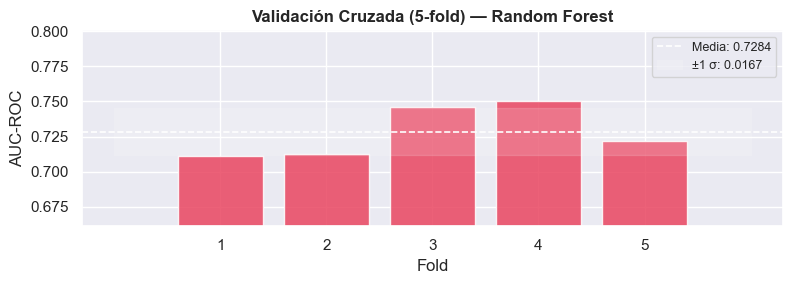

  ✅  La desviación estándar es baja — el modelo es estable entre folds.


In [48]:
# ── Validación cruzada del Random Forest (5-fold) ─────────────────────────────
# La evaluación sobre un solo test set puede ser engañosa si ese split particular
# fue "afortunado". La validación cruzada nos da una imagen más honesta del
# rendimiento esperado del modelo.

print('📊  Validación cruzada (5-fold) del Random Forest...')

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)

print(f'  AUC-ROC por fold: {[f"{s:.4f}" for s in cv_scores]}')
print(f'  AUC-ROC media:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()

# Visualización de los scores por fold
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(range(1, 6), cv_scores, color=COLOR_ACENTO, alpha=0.85, edgecolor='white')
ax.axhline(cv_scores.mean(), color='white', linestyle='--', linewidth=1.2,
           label=f'Media: {cv_scores.mean():.4f}')
ax.fill_between(range(0, 7),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color='white', label=f'±1 σ: {cv_scores.std():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('AUC-ROC')
ax.set_title('Validación Cruzada (5-fold) — Random Forest', fontweight='bold')
ax.set_xticks(range(1, 6))
ax.set_ylim(max(0, cv_scores.min() - 0.05), min(1.0, cv_scores.max() + 0.05))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

if cv_scores.std() < 0.02:
    print('  ✅  La desviación estándar es baja — el modelo es estable entre folds.')
else:
    print('  ⚠️  La desviación estándar es notable — el rendimiento varía según la partición de datos.')

### 🔎 ¿Para qué sirve la validación cruzada?

Imagina que el 20% que separamos como test por casualidad incluye los estudiantes "más fáciles" de clasificar. En ese caso, el AUC del test set se vería inflado y nos daríamos una palmadita en la espalda injustificada. La validación cruzada resuelve ese problema: divide el set de entrenamiento en 5 partes, entrena 5 veces usando 4 partes y evalúa en la quinta, y rota hasta haber evaluado en todas. El promedio de esas 5 evaluaciones es una estimación mucho más robusta del rendimiento real.

Si los scores entre folds son muy parecidos (desviación estándar baja), el modelo es estable. Si fluctúan mucho, probablemente depende demasiado de qué datos le toquen — y eso es una señal de que necesita más regularización o más datos.

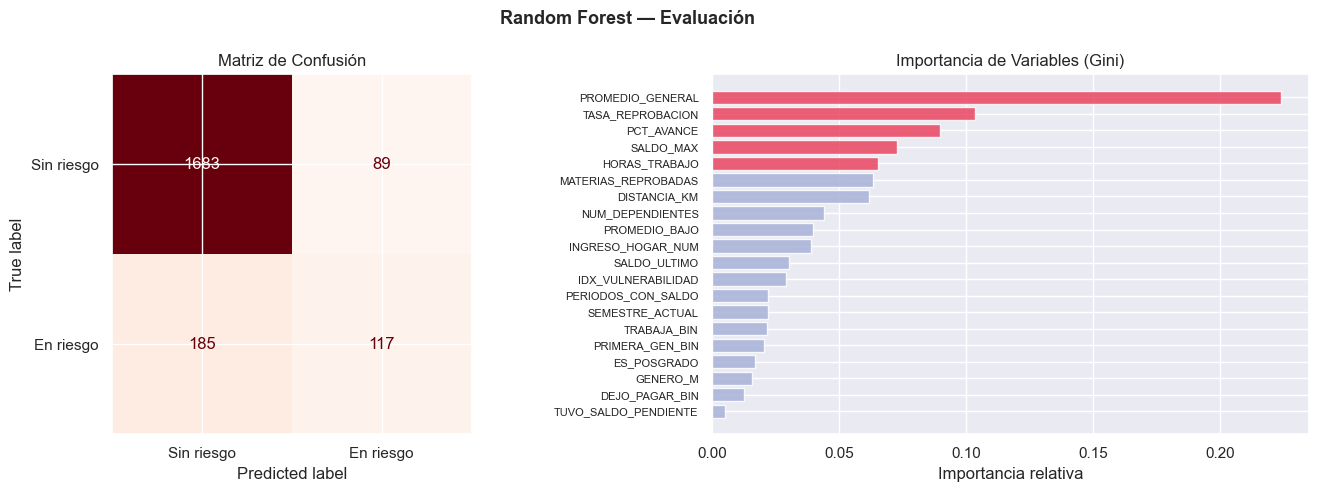

  AUC-ROC del Random Forest: 0.7431


In [49]:
# ── 4.2.2  Matriz de confusión y feature importance del RF ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Evaluación', fontsize=13, fontweight='bold')

# Matriz de confusión
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['Sin riesgo', 'En riesgo']
).plot(ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Matriz de Confusión')

# Feature importance
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
colores_fi   = [COLOR_ACENTO if v >= importancias.quantile(0.75) else COLOR_NEUTRO
                for v in importancias.values]
axes[1].barh(importancias.index, importancias.values, color=colores_fi, alpha=0.85)
axes[1].set_title('Importancia de Variables (Gini)')
axes[1].set_xlabel('Importancia relativa')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('rf_evaluacion.png', dpi=120, bbox_inches='tight')
plt.show()

auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f'  AUC-ROC del Random Forest: {auc_rf:.4f}')

In [50]:
# ── 4.3.1  Arquitectura de la red neuronal ────────────────────────────────────
print('🧠  Construyendo arquitectura de la red neuronal...')

tf.random.set_seed(42)

n_features = X_train_sc.shape[1]

modelo_nn = keras.Sequential([
    # Capa de entrada
    layers.Input(shape=(n_features,)),

    # Capa oculta 1: 128 neuronas + BatchNorm + Dropout
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    # Capa oculta 2: 64 neuronas
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    # Capa oculta 3: 32 neuronas
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.20),

    # Capa de salida: 1 neurona con sigmoide → probabilidad de deserción
    layers.Dense(1, activation='sigmoid'),
], name='SYSAC_DesercionNN')

modelo_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

modelo_nn.summary()

🧠  Construyendo arquitectura de la red neuronal...


Model: "SYSAC_DesercionNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [51]:
# ── 4.3.2  Entrenamiento de la red neuronal ────────────────────────────────────
print('🚀  Entrenando red neuronal...')

# Peso de clase para compensar desbalance (mismo que class_weight='balanced' en RF)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {0: class_weights[0], 1: class_weights[1]}

# EarlyStopping: detiene el entrenamiento si val_loss no mejora en 10 epochs
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

historia = modelo_nn.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=80,
    batch_size=64,
    class_weight=cw_dict,
    callbacks=[early_stop],
    verbose=1
)

print()
print('✅  Entrenamiento finalizado.')

🚀  Entrenando red neuronal...
Epoch 1/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.6292 - auc: 0.6416 - loss: 0.7366 - val_accuracy: 0.6972 - val_auc: 0.6952 - val_loss: 0.6383
Epoch 2/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6766 - auc: 0.6945 - loss: 0.6542 - val_accuracy: 0.7349 - val_auc: 0.7111 - val_loss: 0.6063
Epoch 3/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6887 - auc: 0.7128 - loss: 0.6182 - val_accuracy: 0.7390 - val_auc: 0.7189 - val_loss: 0.5782
Epoch 4/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7165 - auc: 0.7334 - loss: 0.5992 - val_accuracy: 0.7518 - val_auc: 0.7219 - val_loss: 0.5737
Epoch 5/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7186 - auc: 0.7333 - loss: 0.5964 - val_accuracy: 0.7325 - val_auc: 0.7232 - val_loss: 0.5919
Epoch 6/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7149 - auc: 0.7316 - loss: 0.5937 - val_accuracy: 0.7558 - val_auc: 0.7251 - val_loss: 0.5718
Epo

In [52]:
# ── 4.3.3  Evaluación de la red neuronal ──────────────────────────────────────
y_proba_nn = modelo_nn.predict(X_test_sc, verbose=0).ravel()
y_pred_nn  = (y_proba_nn >= 0.50).astype(int)

print('── Reporte de clasificación — Red Neuronal:')
print(classification_report(y_test, y_pred_nn,
                             target_names=['Sin riesgo', 'En riesgo']))

auc_nn = roc_auc_score(y_test, y_proba_nn)
print(f'  AUC-ROC de la Red Neuronal: {auc_nn:.4f}')

── Reporte de clasificación — Red Neuronal:
              precision    recall  f1-score   support

  Sin riesgo       0.92      0.80      0.86      1772
   En riesgo       0.34      0.59      0.43       302

    accuracy                           0.77      2074
   macro avg       0.63      0.70      0.64      2074
weighted avg       0.83      0.77      0.79      2074

  AUC-ROC de la Red Neuronal: 0.7447


### 🔎 Comparando las matrices de confusión: ¿qué errores estamos dispuestos a tolerar?

En este problema, no todos los errores cuestan lo mismo. Un **falso negativo** (el modelo dice "sin riesgo" pero el estudiante realmente deserta) tiene un costo altísimo: la institución pierde un estudiante al que pudo haber ayudado. Un **falso positivo** (el modelo dice "en riesgo" pero el estudiante no deserta) tiene un costo menor: le ofrecemos apoyo a alguien que quizá no lo necesitaba tanto, pero eso rara vez causa daño.

Por eso la métrica más importante aquí no es la *accuracy* ni la *precision* — es el **Recall** (sensibilidad). El Recall mide: de todos los estudiantes que *realmente* desertan, ¿qué porcentaje detectó el modelo? Un Recall de 0.85 significa que capturamos el 85% de los desertores reales. El 15% restante se nos escapó. ¿Es aceptable? Depende del contexto, pero en general, para un problema de retención, queremos el Recall más alto posible.

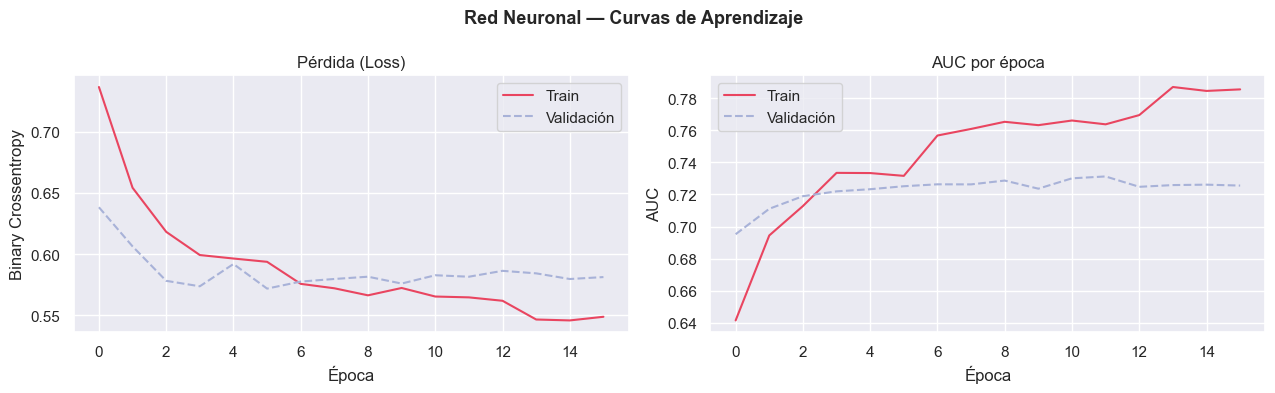

In [53]:
# ── 4.3.4  Curvas de aprendizaje de la red neuronal ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Red Neuronal — Curvas de Aprendizaje', fontsize=13, fontweight='bold')

# Loss
axes[0].plot(historia.history['loss'],     label='Train',      color=COLOR_ACENTO)
axes[0].plot(historia.history['val_loss'], label='Validación', color=COLOR_NEUTRO,
             linestyle='--')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].set_title('Pérdida (Loss)')
axes[0].legend()

# AUC
axes[1].plot(historia.history['auc'],     label='Train',      color=COLOR_ACENTO)
axes[1].plot(historia.history['val_auc'], label='Validación', color=COLOR_NEUTRO,
             linestyle='--')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC por época')
axes[1].legend()

plt.tight_layout()
plt.savefig('nn_curvas_aprendizaje.png', dpi=120, bbox_inches='tight')
plt.show()

In [54]:
# ── 4.4.1  Tabla comparativa de métricas ──────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metricas = pd.DataFrame({
    'Modelo'    : ['Random Forest', 'Red Neuronal'],
    'Accuracy'  : [accuracy_score(y_test, y_pred_rf),
                   accuracy_score(y_test, y_pred_nn)],
    'Precision' : [precision_score(y_test, y_pred_rf),
                   precision_score(y_test, y_pred_nn)],
    'Recall'    : [recall_score(y_test, y_pred_rf),
                   recall_score(y_test, y_pred_nn)],
    'F1-Score'  : [f1_score(y_test, y_pred_rf),
                   f1_score(y_test, y_pred_nn)],
    'AUC-ROC'   : [auc_rf, auc_nn],
})

metricas_fmt = metricas.set_index('Modelo')
metricas_fmt = metricas_fmt.applymap(lambda x: f'{x:.4f}')
print('═' * 65)
print('  Comparativa de Métricas — Test Set')
print('═' * 65)
print(metricas_fmt.to_string())
print()
print('  ⭐  Métrica clave para este problema: Recall (detectar estudiantes en riesgo)')
ganador = metricas.loc[metricas['Recall'].idxmax(), 'Modelo']
print(f'  → Modelo con mayor Recall: {ganador}')

═════════════════════════════════════════════════════════════════
  Comparativa de Métricas — Test Set
═════════════════════════════════════════════════════════════════
              Accuracy Precision  Recall F1-Score AUC-ROC
Modelo                                                   
Random Forest   0.8679    0.5680  0.3874   0.4606  0.7431
Red Neuronal    0.7715    0.3371  0.5894   0.4289  0.7447

  ⭐  Métrica clave para este problema: Recall (detectar estudiantes en riesgo)
  → Modelo con mayor Recall: Red Neuronal


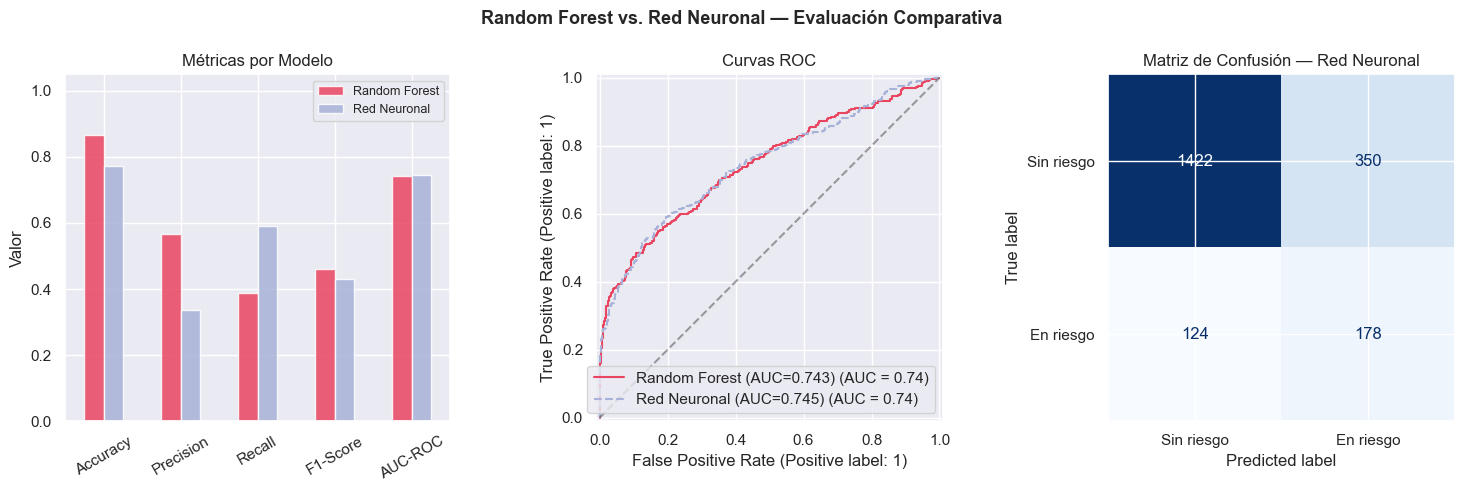

In [55]:
# ── 4.4.2  Gráficas comparativas ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Random Forest vs. Red Neuronal — Evaluación Comparativa',
             fontsize=13, fontweight='bold')

# Barras de métricas
metricas_plot = metricas.set_index('Modelo')[['Accuracy','Precision','Recall','F1-Score','AUC-ROC']]
metricas_plot.T.plot(kind='bar', ax=axes[0],
                     color=[COLOR_ACENTO, COLOR_NEUTRO], alpha=0.85,
                     edgecolor='white')
axes[0].set_title('Métricas por Modelo')
axes[0].set_ylabel('Valor')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)

# Curvas ROC
RocCurveDisplay.from_predictions(
    y_test, y_proba_rf, name=f'Random Forest (AUC={auc_rf:.3f})',
    ax=axes[1], color=COLOR_ACENTO
)
RocCurveDisplay.from_predictions(
    y_test, y_proba_nn, name=f'Red Neuronal (AUC={auc_nn:.3f})',
    ax=axes[1], color=COLOR_NEUTRO, linestyle='--'
)
axes[1].set_title('Curvas ROC')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)

# Matriz de confusión de la NN
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_nn),
    display_labels=['Sin riesgo', 'En riesgo']
).plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Matriz de Confusión — Red Neuronal')

plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

In [56]:
# ── 4.4.3  Selección del modelo y score final para cada estudiante ────────────
# Usamos el modelo con mayor AUC-ROC como modelo principal
# Si hay empate técnico, preferimos RF por interpretabilidad

if auc_rf >= auc_nn:
    MODELO_GANADOR = 'Random Forest'
    y_score_final  = y_proba_rf
    y_pred_final   = y_pred_rf
else:
    MODELO_GANADOR = 'Red Neuronal'
    y_score_final  = y_proba_nn
    y_pred_final   = y_pred_nn

print(f'  ✅  Modelo seleccionado para EVABEC: {MODELO_GANADOR}')
print()

# Agregar score de riesgo al dataset completo
# Para el set de test (estudiantes sobre los que predijimos)
df_test = df_model.iloc[idx_test].copy()
df_test['SCORE_RIESGO']      = y_score_final
df_test['PRED_RIESGO']       = y_pred_final
df_test['NIVEL_RIESGO']      = pd.cut(
    df_test['SCORE_RIESGO'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Bajo', 'Medio', 'Alto']
)

print('  Distribución del nivel de riesgo predicho (conjunto de prueba):')
print(df_test['NIVEL_RIESGO'].value_counts().sort_index().to_string())

  ✅  Modelo seleccionado para EVABEC: Red Neuronal

  Distribución del nivel de riesgo predicho (conjunto de prueba):
NIVEL_RIESGO
Bajo      543
Medio    1220
Alto      311


## 📋 Resumen de la Sección 4

Entrenamos y comparamos dos modelos con enfoques radicalmente distintos. Ambos responden la misma pregunta — ¿este estudiante está en riesgo de desertar? — pero con estrategias diferentes:

| Dimensión | Random Forest | Red Neuronal |
|-----------|--------------|-------------|
| **Interpretabilidad** | Alta (feature importance) | Baja (caja negra) |
| **Sensibilidad al escalado** | No requiere | Requiere normalización |
| **Velocidad de entrenamiento** | Rápida | Más lenta (epochs) |
| **Captura no linealidades** | Moderada | Alta |
| **Requiere tuning de arquitectura** | No | Sí |

> 🚀 **Siguiente paso:** En la Sección 5 tomamos los scores de riesgo y los convertimos en decisiones concretas: asignar becas, detectar sesgos y reflexionar sobre las implicaciones éticas de automatizar estas decisiones.

---
# 🔍 Sección 5 — Interpretación, EVABEC y Ética

Los modelos ya corren y ya producen números. Pero un número sin contexto es ruido disfrazado de respuesta. Esta sección hace tres cosas que en proyectos reales suelen omitirse por falta de tiempo — y que son exactamente donde los proyectos de datos fallan cuando llegan a producción.

Primero interpretamos lo que el modelo aprendió: qué variables pesan más y si eso tiene sentido desde el punto de vista institucional. Después convertimos los scores de riesgo en decisiones concretas de asignación de becas, aplicando las reglas reales de `CATBEC` y `REGBEC`. Y al final nos hacemos las preguntas incómodas: ¿el modelo es justo? ¿Tiene sesgos? ¿Quién responde cuando la predicción está equivocada?

## 5.1 Interpretación del Modelo — Feature Importance Detallada

In [57]:
# ── 5.1.1  Feature importance con intervalo de confianza (permutation) ─────────
# El Gini del RF da una importancia relativa, pero puede sesgarse hacia
# variables con muchos valores únicos. Permutation importance es más honesto.

from sklearn.inspection import permutation_importance

print('⏳ Calculando permutation importance (puede tardar ~30 segundos)...')

perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=15,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importancia': perm.importances_mean,
    'Std'        : perm.importances_std,
}).sort_values('Importancia', ascending=False)

print()
print('── Top 10 variables por Permutation Importance (AUC-ROC):')
print(perm_df.head(10).to_string(index=False))

⏳ Calculando permutation importance (puede tardar ~30 segundos)...

── Top 10 variables por Permutation Importance (AUC-ROC):
           Feature  Importancia  Std
  PROMEDIO_GENERAL         0.10 0.01
        PCT_AVANCE         0.04 0.01
   SEMESTRE_ACTUAL         0.01 0.00
     PROMEDIO_BAJO         0.00 0.00
   PRIMERA_GEN_BIN         0.00 0.00
      DISTANCIA_KM         0.00 0.00
          GENERO_M         0.00 0.00
  TASA_REPROBACION         0.00 0.00
IDX_VULNERABILIDAD         0.00 0.00
       ES_POSGRADO         0.00 0.00


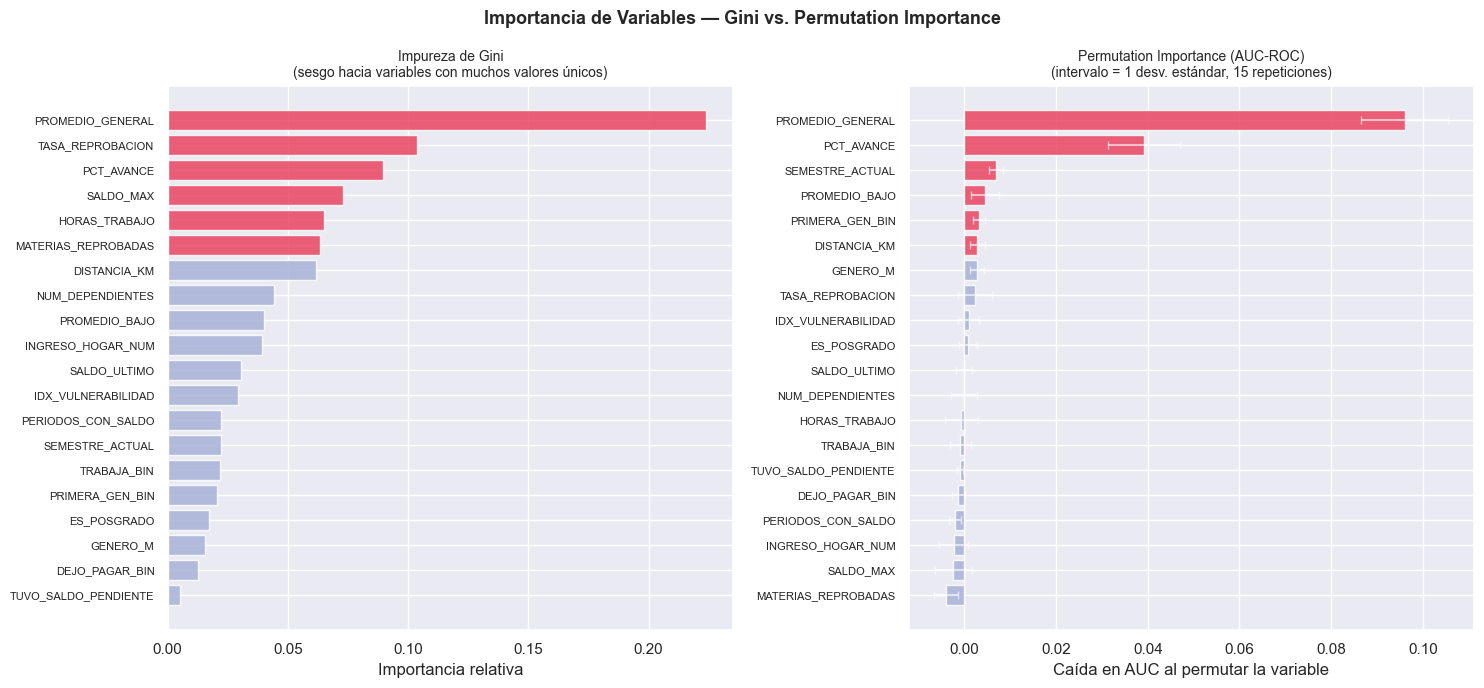

  ℹ️  Las barras con error negativo (cruzando el 0) indican variables poco informativas.


In [58]:
# ── 5.1.2  Visualización comparativa: Gini vs. Permutation Importance ──────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Importancia de Variables — Gini vs. Permutation Importance',
             fontsize=13, fontweight='bold')

# Gini (del entrenamiento)
gini_df = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
colores_g = [COLOR_ACENTO if v >= gini_df.quantile(0.70) else COLOR_NEUTRO
             for v in gini_df.values]
axes[0].barh(gini_df.index, gini_df.values, color=colores_g, alpha=0.85)
axes[0].set_title('Impureza de Gini\n(sesgo hacia variables con muchos valores únicos)',
                  fontsize=10)
axes[0].set_xlabel('Importancia relativa')
axes[0].tick_params(axis='y', labelsize=8)

# Permutation (más honesto)
perm_sorted = perm_df.sort_values('Importancia')
colores_p   = [COLOR_ACENTO if v >= perm_sorted['Importancia'].quantile(0.70)
               else COLOR_NEUTRO for v in perm_sorted['Importancia']]
axes[1].barh(
    perm_sorted['Feature'], perm_sorted['Importancia'],
    xerr=perm_sorted['Std'], color=colores_p, alpha=0.85,
    error_kw={'ecolor':'white', 'capsize':3, 'alpha':0.6}
)
axes[1].set_title('Permutation Importance (AUC-ROC)\n(intervalo = 1 desv. estándar, 15 repeticiones)',
                  fontsize=10)
axes[1].set_xlabel('Caída en AUC al permutar la variable')
axes[1].axvline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('feature_importance_comparativa.png', dpi=120, bbox_inches='tight')
plt.show()
print('  ℹ️  Las barras con error negativo (cruzando el 0) indican variables poco informativas.')

In [59]:
# ── 5.1.3  Reflexión sobre las variables más importantes ──────────────────────
top5 = perm_df.head(5)['Feature'].tolist()

DESCRIPCIONES = {
    'SALDO_MAX'            : 'Saldo máximo pendiente — señal financiera directa de presión económica',
    'SALDO_ULTIMO'         : 'Saldo en la última transacción — indicador de tendencia reciente',
    'TUVO_SALDO_PENDIENTE' : 'Flag de impago — binario pero muy informativo',
    'PERIODOS_CON_SALDO'   : 'Cuántos periodos consecutivos con saldo — mide la cronicidad del problema',
    'PROMEDIO_GENERAL'     : 'Promedio acumulado — refleja rendimiento pero también motivación',
    'TASA_REPROBACION'     : 'Proporción de materias reprobadas — más estable que el conteo absoluto',
    'MATERIAS_REPROBADAS'  : 'Total de materias reprobadas — señal académica directa',
    'IDX_VULNERABILIDAD'   : 'Índice compuesto económico — combina ingreso, saldo e impago',
    'INGRESO_HOGAR_NUM'    : 'Ingreso mensual del hogar — dato declarado por el estudiante',
    'DEJO_PAGAR_BIN'       : '¿Dejó de pagar mensualidad? — autodiagnóstico del estudiante',
    'CONSIDERO_ABANDONAR_BIN': '¿Consideró abandonar? — intención declarada, señal muy fuerte',
    'PCT_AVANCE'           : 'Porcentaje de avance curricular — a mayor avance, menor riesgo',
    'DISTANCIA_KM'         : 'Distancia al campus — relacionada con costo y desgaste de traslado',
    'PROMEDIO_BAJO'        : 'Flag de promedio bajo según mínimo aprobatorio del programa',
    'HORAS_TRABAJO'        : 'Horas semanales trabajadas — compite con tiempo de estudio',
    'TRABAJA_BIN'          : '¿Trabaja? — contexto laboral del estudiante',
    'PRIMERA_GEN_BIN'      : 'Primera generación universitaria — capital cultural del hogar',
    'NUM_DEPENDIENTES'     : 'Dependientes en el hogar — presión económica indirecta',
    'GENERO_M'             : 'Género — variable de control para detectar sesgos',
    'ES_POSGRADO'          : 'Nivel de programa — posgrado tiene perfil de riesgo distinto',
    'SEMESTRE_ACTUAL'      : 'Semestre en curso — el riesgo es mayor en semestres iniciales',
    'GASTO_TRANSPORTE'     : 'Gasto mensual en transporte — costo real del traslado',
    'CALIFICACION_MIN'     : 'Calificación mínima histórica — señal del peor momento académico',
    'CALIFICACION_MAX'     : 'Calificación máxima histórica — señal del potencial real',
    'TOTAL_MATERIAS'       : 'Total de materias cursadas — proxy de antigüedad',
}

print('═' * 65)
print('  Top 5 variables más predictivas (Permutation Importance)')
print('═' * 65)
for i, feat in enumerate(top5, 1):
    desc = DESCRIPCIONES.get(feat, feat)
    val  = perm_df.loc[perm_df['Feature'] == feat, 'Importancia'].values[0]
    print(f'  {i}. {feat:<28} Δ AUC = {val:.4f}')
    print(f'     → {desc}')
    print()

═════════════════════════════════════════════════════════════════
  Top 5 variables más predictivas (Permutation Importance)
═════════════════════════════════════════════════════════════════
  1. PROMEDIO_GENERAL             Δ AUC = 0.0960
     → Promedio acumulado — refleja rendimiento pero también motivación

  2. PCT_AVANCE                   Δ AUC = 0.0392
     → Porcentaje de avance curricular — a mayor avance, menor riesgo

  3. SEMESTRE_ACTUAL              Δ AUC = 0.0069
     → Semestre en curso — el riesgo es mayor en semestres iniciales

  4. PROMEDIO_BAJO                Δ AUC = 0.0045
     → Flag de promedio bajo según mínimo aprobatorio del programa

  5. PRIMERA_GEN_BIN              Δ AUC = 0.0031
     → Primera generación universitaria — capital cultural del hogar



## 5.2 Perfiles de Riesgo — ¿Quién es quién?

Antes de asignar becas, conviene visualizar el universo de estudiantes en el espacio de riesgo. La idea es ver si hay grupos naturales, si los programas se distribuyen distinto y si las variables más importantes realmente separan las clases como esperamos.

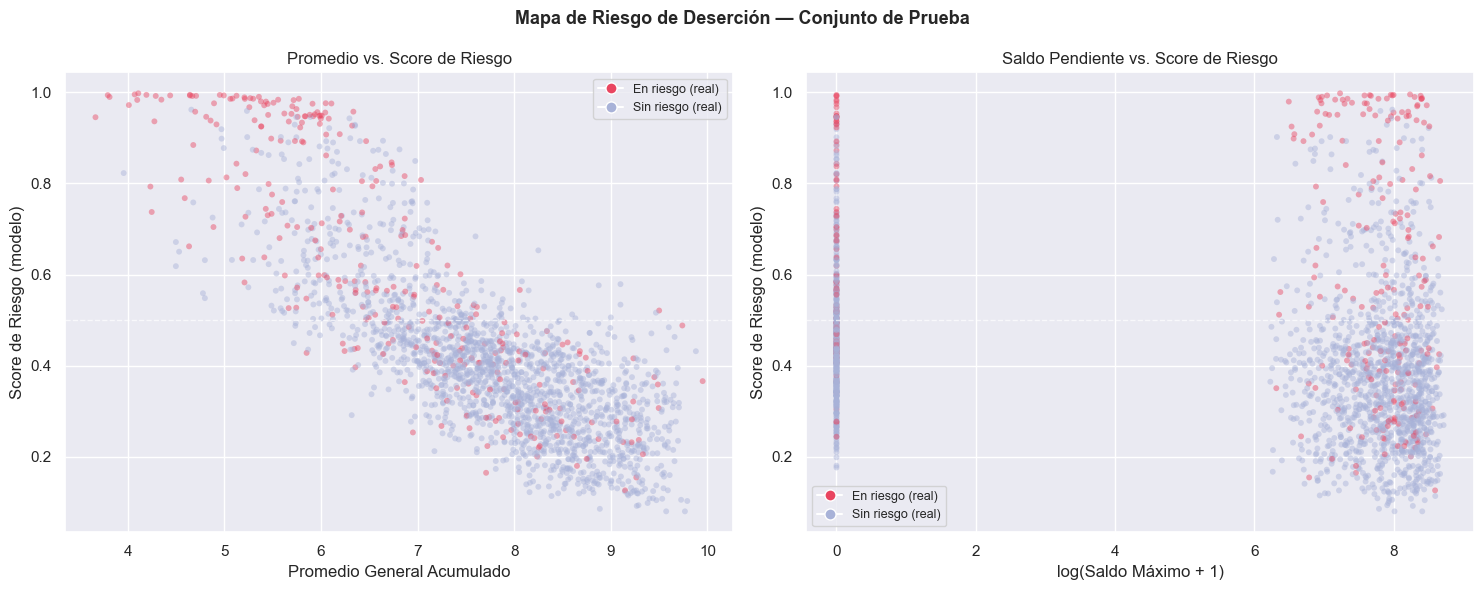

In [60]:
# ── 5.2.1  Score de riesgo vs. promedio general — cuadrantes ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Mapa de Riesgo de Deserción — Conjunto de Prueba',
             fontsize=13, fontweight='bold')

# Colores por estado real (ground truth)
colores_real = df_test['RIESGO_DESERCION'].map({1: COLOR_ACENTO, 0: COLOR_NEUTRO})

ax = axes[0]
ax.scatter(
    df_test['PROMEDIO_GENERAL'], df_test['SCORE_RIESGO'],
    c=colores_real, alpha=0.45, s=18, edgecolors='none'
)
ax.axhline(0.50, color='white', linestyle='--', linewidth=1, alpha=0.7,
           label='Umbral decisión (0.50)')
ax.set_xlabel('Promedio General Acumulado')
ax.set_ylabel('Score de Riesgo (modelo)')
ax.set_title('Promedio vs. Score de Riesgo')
ax.legend(fontsize=9)

# Scatter con leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_ACENTO,
           markersize=8, label='En riesgo (real)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_NEUTRO,
           markersize=8, label='Sin riesgo (real)'),
]
ax.legend(handles=leyenda, fontsize=9)

# Score de riesgo vs saldo máximo
ax2 = axes[1]
saldo_log = np.log1p(df_test['SALDO_MAX'])  # log para comprimir escala
ax2.scatter(
    saldo_log, df_test['SCORE_RIESGO'],
    c=colores_real, alpha=0.45, s=18, edgecolors='none'
)
ax2.axhline(0.50, color='white', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xlabel('log(Saldo Máximo + 1)')
ax2.set_ylabel('Score de Riesgo (modelo)')
ax2.set_title('Saldo Pendiente vs. Score de Riesgo')
ax2.legend(handles=leyenda, fontsize=9)

plt.tight_layout()
plt.savefig('mapa_riesgo.png', dpi=120, bbox_inches='tight')
plt.show()

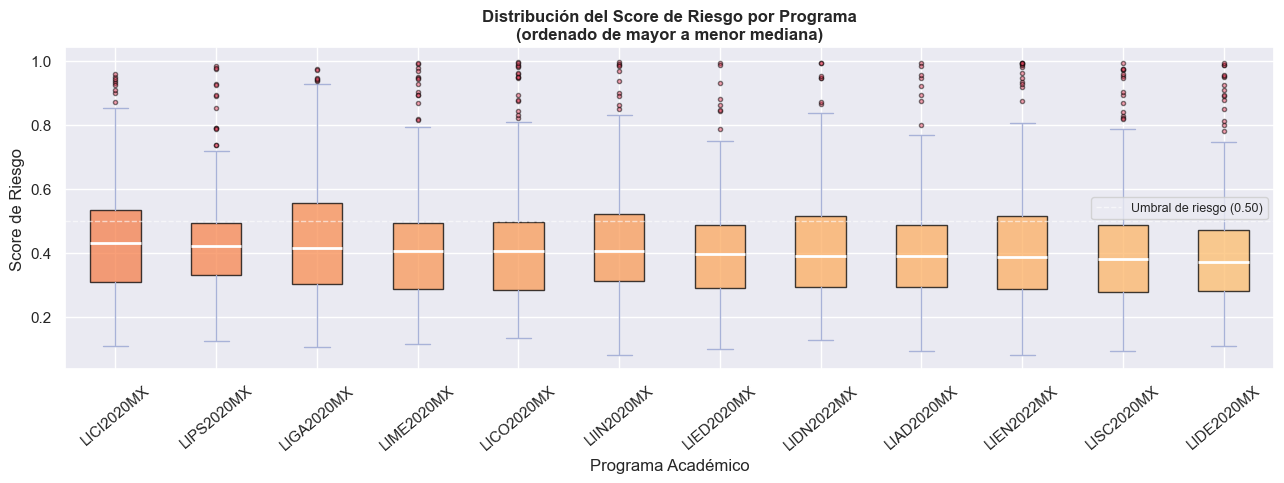

In [61]:
# ── 5.2.2  Distribución del score de riesgo por programa académico ─────────────
fig, ax = plt.subplots(figsize=(13, 5))

programas_orden = (
    df_test.groupby('CVE_PROGRAMA')['SCORE_RIESGO']
    .median()
    .sort_values(ascending=False)
    .index
)

datos_boxplot = [
    df_test.loc[df_test['CVE_PROGRAMA'] == prog, 'SCORE_RIESGO'].dropna().values
    for prog in programas_orden
]

bp = ax.boxplot(
    datos_boxplot,
    labels=programas_orden,
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2},
    whiskerprops={'color': COLOR_NEUTRO},
    capprops={'color': COLOR_NEUTRO},
    flierprops={'marker': 'o', 'markerfacecolor': COLOR_ACENTO,
                'markersize': 3, 'alpha': 0.5},
)

# Colorear cajas por mediana
medianas = [np.median(d) if len(d) > 0 else 0 for d in datos_boxplot]
for patch, med in zip(bp['boxes'], medianas):
    intensidad = min(med * 1.8, 1.0)
    patch.set_facecolor(plt.cm.RdYlGn_r(intensidad))
    patch.set_alpha(0.75)

ax.axhline(0.50, color='white', linestyle='--', linewidth=1,
           alpha=0.6, label='Umbral de riesgo (0.50)')
ax.set_xlabel('Programa Académico')
ax.set_ylabel('Score de Riesgo')
ax.set_title('Distribución del Score de Riesgo por Programa\n'
             '(ordenado de mayor a menor mediana)', fontweight='bold')
ax.tick_params(axis='x', rotation=40)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('riesgo_por_programa.png', dpi=120, bbox_inches='tight')
plt.show()

In [62]:
# ── 5.2.3  Tabla de perfiles de riesgo por programa ───────────────────────────
perfil_prog = (
    df_test
    .groupby('CVE_PROGRAMA')
    .agg(
        N_Estudiantes      = ('SID',              'count'),
        Score_Medio        = ('SCORE_RIESGO',     'mean'),
        Pct_Alto_Riesgo    = ('PRED_RIESGO',      'mean'),
        Promedio_Medio     = ('PROMEDIO_GENERAL', 'mean'),
        Saldo_Medio        = ('SALDO_MAX',        'mean'),
    )
    .round(3)
    .sort_values('Score_Medio', ascending=False)
)

perfil_prog['Pct_Alto_Riesgo'] = (perfil_prog['Pct_Alto_Riesgo'] * 100).round(1).astype(str) + '%'
perfil_prog['Saldo_Medio']     = perfil_prog['Saldo_Medio'].map('$ {:,.0f}'.format)

print('═' * 75)
print('  Perfil de Riesgo por Programa Académico')
print('═' * 75)
print(perfil_prog.to_string())

═══════════════════════════════════════════════════════════════════════════
  Perfil de Riesgo por Programa Académico
═══════════════════════════════════════════════════════════════════════════
              N_Estudiantes  Score_Medio Pct_Alto_Riesgo  Promedio_Medio Saldo_Medio
CVE_PROGRAMA                                                                        
LICI2020MX              158         0.46           31.6%            7.62     $ 2,197
LIPS2020MX              155         0.45           24.5%            7.64     $ 1,897
LIGA2020MX              174         0.44           32.8%            7.56     $ 2,112
LICO2020MX              195         0.44           25.1%            7.54     $ 1,919
LIIN2020MX              159         0.43           28.3%            7.54     $ 2,208
LIME2020MX              173         0.43           24.9%            7.61     $ 2,012
LIEN2022MX              187         0.42           25.7%            7.68     $ 2,184
LIDN2022MX              155         0.42 

### 🔎 Los programas no son iguales — y el modelo lo sabe

La tabla de perfiles por programa revela algo fundamental: el riesgo de deserción no se distribuye uniformemente. Algunos programas concentran más estudiantes en riesgo, ya sea por el perfil socioeconómico de quienes los eligen, por la dificultad intrínseca del plan de estudios, o por una combinación de ambos factores.

Un director académico que viera estos datos por primera vez probablemente se haría la pregunta correcta: ¿los programas con mayor riesgo necesitan más becas, más tutorías, o una revisión de su mapa curricular? La respuesta no sale de un modelo de machine learning — sale de una conversación informada entre los datos y la experiencia pedagógica. Pero sin los datos, esa conversación ni siquiera empieza.

## 5.3 Construcción de EVABEC — Evaluación de Solicitudes de Beca

Aquí cerramos el ciclo. Con los scores de riesgo calculados y las solicitudes de `SOLBEC` estructuradas, aplicamos las reglas de `CATBEC` y `REGBEC` para generar las evaluaciones. El periodo de referencia es **2025CA** — el más reciente con reglas vigentes en `REGBEC`.

La lógica es escalonada: se evalúan las reglas por prioridad y la primera que se cumpla determina el porcentaje asignado. Para BEC003 (Colegiatura) hay un requisito adicional obligatorio: cero materias reprobadas.

In [63]:
# ── 5.3.1  Motor de evaluación de reglas ──────────────────────────────────────
import uuid

PERIODO_EVAL = '2025CA'

# Filtrar reglas del periodo activo
reglas_activas = regbec[regbec['PERIODO'] == PERIODO_EVAL].copy()
reglas_activas['VALOR'] = reglas_activas['VALOR'].astype(str)

print(f'  Reglas activas para {PERIODO_EVAL}: {len(reglas_activas)}')
print(reglas_activas[['CVE_REGLA','CVE_BECA','CRITERIO',
                       'OPERADOR','VALOR','PORCENTAJE_ASIGNADO',
                       'PRIORIDAD']].to_string(index=False))

def evaluar_regla(valor_estudiante, operador: str, valor_regla: str) -> bool:
    """Evalúa si un valor del estudiante cumple una regla dado su operador."""
    try:
        if valor_regla.upper() in ('TRUE', 'FALSE'):
            ve = bool(valor_estudiante)
            vr = valor_regla.upper() == 'TRUE'
            return ve == vr
        ve = float(valor_estudiante)
        vr = float(valor_regla)
        if operador == '>=' : return ve >= vr
        if operador == '<=' : return ve <= vr
        if operador == '=='  : return ve == vr
        if operador == '>'  : return ve > vr
        if operador == '<'  : return ve < vr
    except (ValueError, TypeError):
        return False
    return False


def evaluar_solicitud(row: pd.Series, reglas: pd.DataFrame) -> dict:
    """
    Aplica las reglas de REGBEC a una solicitud de SOLBEC.
    Devuelve un diccionario con el resultado de la evaluación.
    """
    cve_beca = row.get('CVE_BECA')
    if pd.isna(cve_beca):
        return {'RESULTADO': 'RECHAZADA', 'CVE_REGLA': None,
                'PORCENTAJE_OTORGADO': 0.0, 'OBSERVACIONES': 'Tipo de beca no identificado'}

    # Reglas de esta beca, ordenadas por prioridad
    reglas_beca = (
        reglas[reglas['CVE_BECA'] == cve_beca]
        .sort_values('PRIORIDAD')
    )

    # Mapa de criterio → valor del estudiante
    CRITERIO_MAP = {
        'PROMEDIO_GENERAL'     : row.get('PROMEDIO_GENERAL', np.nan),
        'MATERIAS_REPROBADAS'  : row.get('MATERIAS_REPROBADAS', np.nan),
        'DISTANCIA_KM'         : row.get('DISTANCIA_KM', np.nan),
        'PRIMER_INGRESO'       : row.get('TIPO_CARGO_INS', False),
        'REINSCRIPCION_VIGENTE': row.get('TIPO_CARGO_REI', False),
    }

    # BEC003: requisito obligatorio — cero materias reprobadas
    if cve_beca == 'BEC003':
        if pd.notna(row.get('MATERIAS_REPROBADAS')) and row['MATERIAS_REPROBADAS'] > 0:
            return {
                'RESULTADO'           : 'RECHAZADA',
                'CVE_REGLA'           : 'REG_REPROBADAS',
                'PORCENTAJE_OTORGADO' : 0.0,
                'OBSERVACIONES'       : f'Tiene {int(row["MATERIAS_REPROBADAS"])} materia(s) reprobada(s). '
                                        f'BEC003 requiere cero reprobadas.'
            }

    # Evaluar reglas de porcentaje en orden de prioridad
    for _, regla in reglas_beca.iterrows():
        criterio  = regla['CRITERIO']
        operador  = regla['OPERADOR']
        valor     = regla['VALOR']
        porcentaje= float(regla['PORCENTAJE_ASIGNADO'])
        cve_regla = regla['CVE_REGLA']

        valor_est = CRITERIO_MAP.get(criterio, np.nan)

        if pd.isna(valor_est):
            continue  # dato faltante, no podemos evaluar esta regla

        if evaluar_regla(valor_est, operador, valor) and porcentaje > 0:
            return {
                'RESULTADO'           : 'APROBADA',
                'CVE_REGLA'           : cve_regla,
                'PORCENTAJE_OTORGADO' : porcentaje,
                'OBSERVACIONES'       : f'{criterio} {operador} {valor} → {porcentaje}%'
            }

    return {
        'RESULTADO'           : 'RECHAZADA',
        'CVE_REGLA'           : None,
        'PORCENTAJE_OTORGADO' : 0.0,
        'OBSERVACIONES'       : 'No cumplió ninguna regla del periodo'
    }

print()
print('✅  Motor de evaluación listo.')

  Reglas activas para 2025CA: 11
CVE_REGLA CVE_BECA              CRITERIO OPERADOR VALOR  PORCENTAJE_ASIGNADO  PRIORIDAD
 REG00016   BEC003      PROMEDIO_GENERAL       >=   9.5                50.00          1
 REG00017   BEC003      PROMEDIO_GENERAL       >=   9.0                40.00          2
 REG00018   BEC003      PROMEDIO_GENERAL       >=   8.5                25.00          3
 REG00019   BEC003      PROMEDIO_GENERAL       >=   8.0                10.00          4
 REG00020   BEC003   MATERIAS_REPROBADAS       ==     0                 0.00          5
 REG00033   BEC004          DISTANCIA_KM       >=    25               100.00          1
 REG00034   BEC004          DISTANCIA_KM       >=    15                75.00          2
 REG00035   BEC004          DISTANCIA_KM       >=    10                50.00          3
 REG00036   BEC004          DISTANCIA_KM       >=     5                25.00          4
 REG00040   BEC001        PRIMER_INGRESO       ==  TRUE               100.00          1

In [64]:
# ── 5.3.2  Construir EVABEC aplicando el motor sobre SOLBEC ───────────────────
print(f'⚙️  Evaluando {len(solbec):,} solicitudes para el periodo {PERIODO_EVAL}...')

# Enriquecer SOLBEC con los features del modelo que necesita el motor
solbec_eval = solbec.merge(
    df_model[['SID','PROMEDIO_GENERAL','MATERIAS_REPROBADAS','DISTANCIA_KM']],
    on='SID', how='left', suffixes=('', '_INST')
)

# Para BEC001 y BEC002 necesitamos saber si tiene inscripción/reinscripción
# Se infiere del tipo de beca declarada y del historial de pagos
solbec_eval['TIPO_CARGO_INS'] = solbec_eval['CVE_BECA'].eq('BEC001')
solbec_eval['TIPO_CARGO_REI'] = solbec_eval['CVE_BECA'].eq('BEC002')

# Usar calificaciones institucionales (más confiables que las declaradas)
solbec_eval['PROMEDIO_GENERAL'] = solbec_eval['PROMEDIO_GENERAL_INST'].fillna(
    solbec_eval.get('PROMEDIO_DECL', np.nan)
)

# Aplicar el motor fila por fila
resultados = solbec_eval.apply(
    lambda row: evaluar_solicitud(row, reglas_activas), axis=1
)
resultados_df = pd.DataFrame(resultados.tolist())

# Construir la tabla EVABEC
evabec = pd.DataFrame({
    'CVE_EVALUACION'     : [f'EVA{PERIODO_EVAL}{str(i).zfill(5)}' for i in range(1, len(solbec_eval)+1)],
    'SID'                : solbec_eval['SID'].values,
    'MATRICULA'          : solbec_eval['MATRICULA'].values,
    'CVE_BECA'           : solbec_eval['CVE_BECA'].values,
    'PERIODO'            : PERIODO_EVAL,
    'SCORE_RIESGO'       : solbec_eval['SID'].map(
                               df_test.set_index('SID')['SCORE_RIESGO']
                           ).values,
    'NIVEL_RIESGO'       : solbec_eval['SID'].map(
                               df_test.set_index('SID')['NIVEL_RIESGO'].astype(str)
                           ).values,
    'RESULTADO'          : resultados_df['RESULTADO'].values,
    'CVE_REGLA'          : resultados_df['CVE_REGLA'].values,
    'PORCENTAJE_OTORGADO': resultados_df['PORCENTAJE_OTORGADO'].values,
    'OBSERVACIONES'      : resultados_df['OBSERVACIONES'].values,
    'FECHA_EVALUACION'   : pd.Timestamp.today().strftime('%Y-%m-%d'),
})

print(f'✅  EVABEC construida: {len(evabec):,} evaluaciones')
print()
print('── Resultados generales:')
print(evabec['RESULTADO'].value_counts().to_string())
print()
print('── Aprobadas por tipo de beca:')
print(
    evabec[evabec['RESULTADO'] == 'APROBADA']
    .groupby('CVE_BECA')['PORCENTAJE_OTORGADO']
    .agg(['count', 'mean', 'min', 'max'])
    .round(1)
    .to_string()
)

⚙️  Evaluando 7,777 solicitudes para el periodo 2025CA...
✅  EVABEC construida: 7,777 evaluaciones

── Resultados generales:
RESULTADO
APROBADA     5117
RECHAZADA    2660

── Aprobadas por tipo de beca:
          count   mean    min    max
CVE_BECA                            
BEC001     3363 100.00 100.00 100.00
BEC003      536  27.80  10.00  50.00
BEC004     1218  99.20  75.00 100.00


In [65]:
# ── 5.3.3  Cruce clave: estudiantes con beca aprobada Y alto riesgo ────────────
# Estos son los casos de mayor valor institucional: apoyo dirigido a quien más lo necesita

aprobadas_riesgo = evabec[
    (evabec['RESULTADO'] == 'APROBADA') &
    (evabec['NIVEL_RIESGO'] == 'Alto')
].copy()

total_alto_riesgo = (evabec['NIVEL_RIESGO'] == 'Alto').sum()
n_aprobadas_alto  = len(aprobadas_riesgo)

print('═' * 65)
print('  Impacto potencial: Beca aprobada + Alto Riesgo')
print('═' * 65)
print(f'  Solicitudes con nivel de riesgo Alto: {total_alto_riesgo:,}')
print(f'  De esas, con beca APROBADA:           {n_aprobadas_alto:,}')
print(f'  Cobertura sobre población de riesgo:  {n_aprobadas_alto/total_alto_riesgo*100:.1f}%')
print()
print('  Distribución por tipo de beca en el grupo de alto riesgo:')
print(aprobadas_riesgo['CVE_BECA'].value_counts().to_string())
print()
print('  Porcentaje promedio otorgado al grupo de alto riesgo:')
print(aprobadas_riesgo.groupby('CVE_BECA')['PORCENTAJE_OTORGADO'].mean().round(1).to_string())

═════════════════════════════════════════════════════════════════
  Impacto potencial: Beca aprobada + Alto Riesgo
═════════════════════════════════════════════════════════════════
  Solicitudes con nivel de riesgo Alto: 182
  De esas, con beca APROBADA:           102
  Cobertura sobre población de riesgo:  56.0%

  Distribución por tipo de beca en el grupo de alto riesgo:
CVE_BECA
BEC001    73
BEC004    28
BEC003     1

  Porcentaje promedio otorgado al grupo de alto riesgo:
CVE_BECA
BEC001   100.00
BEC003    10.00
BEC004    98.20


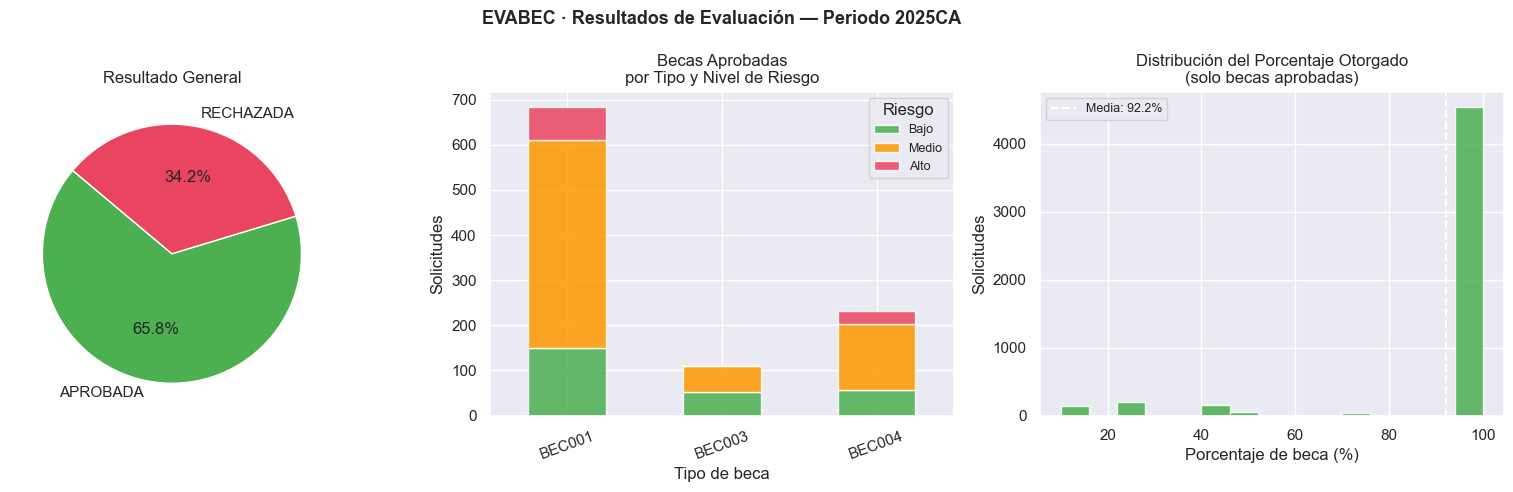

In [66]:
# ── 5.3.4  Visualización del impacto de EVABEC ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'EVABEC · Resultados de Evaluación — Periodo {PERIODO_EVAL}',
             fontsize=13, fontweight='bold')

# Pastel de resultados
res_counts = evabec['RESULTADO'].value_counts()
colores_res = {'APROBADA': '#4caf50', 'RECHAZADA': COLOR_ACENTO, 'CANCELADA': '#9e9e9e'}
axes[0].pie(
    res_counts.values,
    labels=res_counts.index,
    colors=[colores_res.get(r, '#555') for r in res_counts.index],
    autopct='%1.1f%%', startangle=140
)
axes[0].set_title('Resultado General')

# Aprobadas por beca y nivel de riesgo
cruce = (
    evabec[evabec['RESULTADO'] == 'APROBADA']
    .groupby(['CVE_BECA','NIVEL_RIESGO'])
    .size()
    .unstack(fill_value=0)
)
if not cruce.empty:
    orden_cols = [c for c in ['Bajo','Medio','Alto'] if c in cruce.columns]
    cruce[orden_cols].plot(
        kind='bar', ax=axes[1], stacked=True,
        color=['#4caf50', '#ff9800', COLOR_ACENTO],
        alpha=0.85, edgecolor='white'
    )
    axes[1].set_title('Becas Aprobadas\npor Tipo y Nivel de Riesgo')
    axes[1].set_xlabel('Tipo de beca')
    axes[1].set_ylabel('Solicitudes')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].legend(title='Riesgo', fontsize=9)

# Distribución del porcentaje otorgado (aprobadas)
aprobadas = evabec[evabec['RESULTADO'] == 'APROBADA']['PORCENTAJE_OTORGADO']
axes[2].hist(aprobadas, bins=15, color='#4caf50', alpha=0.85, edgecolor='white')
axes[2].set_title('Distribución del Porcentaje Otorgado\n(solo becas aprobadas)')
axes[2].set_xlabel('Porcentaje de beca (%)')
axes[2].set_ylabel('Solicitudes')
axes[2].axvline(aprobadas.mean(), color='white', linestyle='--',
                label=f'Media: {aprobadas.mean():.1f}%')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('evabec_resultados.png', dpi=120, bbox_inches='tight')
plt.show()

In [67]:
# ── 5.3.5  Exportar los artefactos construidos ────────────────────────────────
print('💾  Exportando artefactos...')

evabec.to_csv('EVABEC.csv',  index=False, encoding='utf-8-sig')
solbec.to_csv('SOLBEC.csv',  index=False, encoding='utf-8-sig')
disbec.to_csv('DISBEC.csv',  index=False, encoding='utf-8-sig')
df_test.to_csv('SCORES_RIESGO.csv', index=False, encoding='utf-8-sig')

print('  ✅  EVABEC.csv            — Evaluaciones de beca del periodo 2025CA')
print('  ✅  SOLBEC.csv            — Solicitudes estructuradas enriquecidas')
print('  ✅  DISBEC.csv            — Distancias geodésicas por estudiante')
print('  ✅  SCORES_RIESGO.csv     — Score de riesgo por estudiante (conjunto de prueba)')
print()

# Resumen ejecutivo
aprobadas_total = (evabec['RESULTADO'] == 'APROBADA').sum()
pct_cobertura   = aprobadas_total / len(evabec) * 100
impacto_alto    = n_aprobadas_alto

print('═' * 65)
print('  RESUMEN EJECUTIVO — Pipeline Completo')
print('═' * 65)
print(f'  Solicitudes evaluadas:        {len(evabec):,}')
print(f'  Becas aprobadas:              {aprobadas_total:,}  ({pct_cobertura:.1f}%)')
print(f'  Alto riesgo con beca:         {impacto_alto:,}')
print(f'  Modelo seleccionado:          {MODELO_GANADOR}')
print(f'  Periodo de evaluación:        {PERIODO_EVAL}')

💾  Exportando artefactos...
  ✅  EVABEC.csv            — Evaluaciones de beca del periodo 2025CA
  ✅  SOLBEC.csv            — Solicitudes estructuradas enriquecidas
  ✅  DISBEC.csv            — Distancias geodésicas por estudiante
  ✅  SCORES_RIESGO.csv     — Score de riesgo por estudiante (conjunto de prueba)

═════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — Pipeline Completo
═════════════════════════════════════════════════════════════════
  Solicitudes evaluadas:        7,777
  Becas aprobadas:              5,117  (65.8%)
  Alto riesgo con beca:         102
  Modelo seleccionado:          Red Neuronal
  Periodo de evaluación:        2025CA


## 5.4 Análisis de Sesgo — ¿El Modelo es Justo?

Antes de que cualquier sistema de este tipo llegue a producción, hay una pregunta que no puede omitirse: ¿el modelo trata igual a todos los grupos? Un modelo puede tener una accuracy excelente a nivel global y al mismo tiempo ser sistemáticamente injusto con ciertos subgrupos. Eso no es un error técnico — es un problema ético con consecuencias reales.

In [68]:
# ── 5.4.1  Sesgo por género ────────────────────────────────────────────────────
from sklearn.metrics import recall_score, precision_score

df_sesgo = df_test.merge(
    infcom_clean[['SID','GENERO']], on='SID', how='left'
)

print('═' * 65)
print('  Métricas por Género (grupo con ≥ 30 observaciones en test)')
print('═' * 65)

for genero, grupo in df_sesgo.groupby('GENERO'):
    if len(grupo) < 30:
        continue
    yt = grupo['RIESGO_DESERCION'].values
    yp = grupo['PRED_RIESGO'].values
    if len(np.unique(yt)) < 2:
        print(f'  {genero:<20} (sin ambas clases, no calculable)')
        continue
    rec  = recall_score(yt, yp,    zero_division=0)
    prec = precision_score(yt, yp, zero_division=0)
    tdr  = yt.mean()
    print(f'  {genero:<20} N={len(grupo):>4}  '
          f'Tasa real deserción={tdr:.2%}  '
          f'Recall={rec:.3f}  Precision={prec:.3f}')

═════════════════════════════════════════════════════════════════
  Métricas por Género (grupo con ≥ 30 observaciones en test)
═════════════════════════════════════════════════════════════════
  F                    N=1038  Tasa real deserción=14.93%  Recall=0.613  Precision=0.356
  M                    N=1020  Tasa real deserción=14.12%  Recall=0.569  Precision=0.318


In [69]:
# ── 5.4.2  Sesgo por programa académico ───────────────────────────────────────
print('═' * 75)
print('  Métricas por Programa Académico (grupo con ≥ 30 observaciones en test)')
print('═' * 75)

sesgo_prog_rows = []
for prog, grupo in df_sesgo.groupby('CVE_PROGRAMA'):
    if len(grupo) < 30:
        continue
    yt = grupo['RIESGO_DESERCION'].values
    yp = grupo['PRED_RIESGO'].values
    if len(np.unique(yt)) < 2:
        continue
    sesgo_prog_rows.append({
        'Programa'       : prog,
        'N'              : len(grupo),
        'Tasa_Real_%'    : round(yt.mean() * 100, 1),
        'Recall'         : round(recall_score(yt, yp, zero_division=0), 3),
        'Precision'      : round(precision_score(yt, yp, zero_division=0), 3),
    })

sesgo_prog_df = pd.DataFrame(sesgo_prog_rows).sort_values('Recall', ascending=False)
print(sesgo_prog_df.to_string(index=False))
print()
print('  ⚠️  Recall muy bajo en algún programa = el modelo no detecta bien a sus estudiantes en riesgo.')
print('  ⚠️  Diferencias > 0.15 en recall entre programas son señal de sesgo que debe investigarse.')

═══════════════════════════════════════════════════════════════════════════
  Métricas por Programa Académico (grupo con ≥ 30 observaciones en test)
═══════════════════════════════════════════════════════════════════════════
  Programa   N  Tasa_Real_%  Recall  Precision
LIGA2020MX 174        15.50    0.70       0.33
LICI2020MX 158        18.40    0.69       0.40
LIED2020MX 168         9.50    0.69       0.28
LICO2020MX 195        13.30    0.61       0.33
LIME2020MX 173        15.00    0.61       0.37
LIPS2020MX 155        11.60    0.61       0.29
LIIN2020MX 159        12.60    0.60       0.27
LIDE2020MX 183        15.80    0.59       0.47
LIDN2022MX 155        13.50    0.57       0.29
LISC2020MX 193        16.10    0.52       0.34
LIEN2022MX 187        18.70    0.51       0.38
LIAD2020MX 174        13.80    0.42       0.29

  ⚠️  Recall muy bajo en algún programa = el modelo no detecta bien a sus estudiantes en riesgo.
  ⚠️  Diferencias > 0.15 en recall entre programas son señal de se

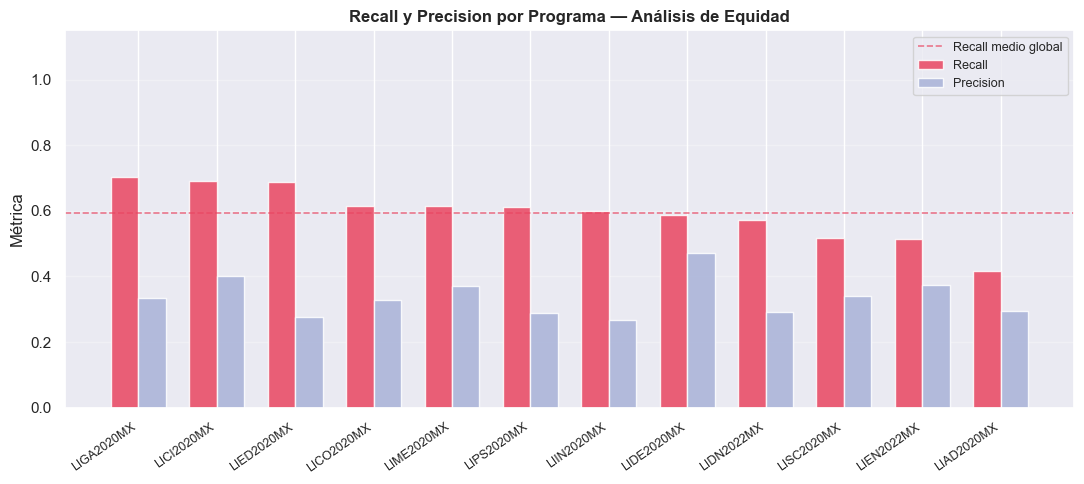

In [70]:
# ── 5.4.3  Gráfica de sesgo ────────────────────────────────────────────────────
if sesgo_prog_rows:
    fig, ax = plt.subplots(figsize=(11, 5))
    x     = np.arange(len(sesgo_prog_df))
    width = 0.35

    bars_rec  = ax.bar(x - width/2, sesgo_prog_df['Recall'],
                       width, label='Recall', color=COLOR_ACENTO, alpha=0.85)
    bars_prec = ax.bar(x + width/2, sesgo_prog_df['Precision'],
                       width, label='Precision', color=COLOR_NEUTRO, alpha=0.85)

    ax.axhline(sesgo_prog_df['Recall'].mean(), color=COLOR_ACENTO,
               linestyle='--', linewidth=1.2, alpha=0.7, label='Recall medio global')

    ax.set_xticks(x)
    ax.set_xticklabels(sesgo_prog_df['Programa'], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Métrica')
    ax.set_ylim(0, 1.15)
    ax.set_title('Recall y Precision por Programa — Análisis de Equidad',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('analisis_sesgo.png', dpi=120, bbox_inches='tight')
    plt.show()

## 5.5 Reflexión Ética — Las Preguntas que el Código No Puede Responder

Llegamos al momento más importante del taller. No porque sea el más técnico — sino porque es donde el analista tiene que salir de la pantalla y preguntarse qué está haciendo en realidad.

Construiste un modelo que predice quién va a desertar. Y con esa predicción, decidiste quién recibe una beca. Eso significa que, en algún sentido, también decidiste quién no la recibe. Eso es poder. Y el poder sobre datos de personas vulnerables tiene consecuencias que los números no capturan solos.

### Las preguntas que todo equipo debería hacerse antes de poner este modelo en producción:

**¿Qué pasa con los falsos negativos?**
Un estudiante en riesgo real que el modelo clasificó como "sin riesgo" no recibe beca. Probablemente deserta. El modelo no lo vio venir — pero los datos estaban ahí. ¿Cuál es la responsabilidad de la institución cuando tiene las herramientas pero no las usa correctamente?

**¿El modelo perpetúa desventajas estructurales?**
Si históricamente ciertos programas, municipios o géneros tienen mayor tasa de deserción, el modelo va a aprender eso. Y al predecir con esos patrones, puede reforzarlos: asignar menos becas a grupos que históricamente desertan más — justamente los que más apoyo necesitarían.

**¿Quién audita el modelo?**
Los resultados del análisis de sesgo de la sección anterior no son un diagnóstico automático de injusticia, pero sí son una señal de alarma. En un sistema real, debería existir un comité humano que revise los casos límite y las discrepancias entre programas. Los modelos no toman decisiones — las personas que los implementan, sí.

**¿El estudiante sabe que está siendo evaluado por un algoritmo?**
En México, la Ley General de Protección de Datos Personales (LGPDPPSO) establece el principio de transparencia. Un estudiante tiene derecho a saber que su solicitud de beca está siendo procesada, en parte, por un modelo de machine learning entrenado con su historial académico y financiero.

**¿Cuándo debe un humano sobreescribir al modelo?**
La respuesta correcta no es "nunca" ni "siempre". Es definir de antemano en qué casos la intervención humana es obligatoria — casos límite, situaciones extraordinarias, primera generación universitaria — y en cuáles el modelo puede actuar de forma autónoma.

> 💬 **Para el taller:** Formen equipos de 3 personas. Tomen uno de los cuadrantes del mapa de riesgo de la Sección 5.2 — por ejemplo, los estudiantes con alto score de riesgo pero beca rechazada — y argumenten en 3 minutos qué haría su equipo con esos casos. No hay respuesta correcta. El objetivo es que la decisión sea deliberada, no automática.

## 5.6 Panel Final — El Dashboard del Decisor

Para cerrar la sección de análisis, construimos un panel consolidado que resume todo lo que el modelo produjo. Es la vista que un director académico o coordinador de becas necesitaría para tomar decisiones en una reunión de planeación.

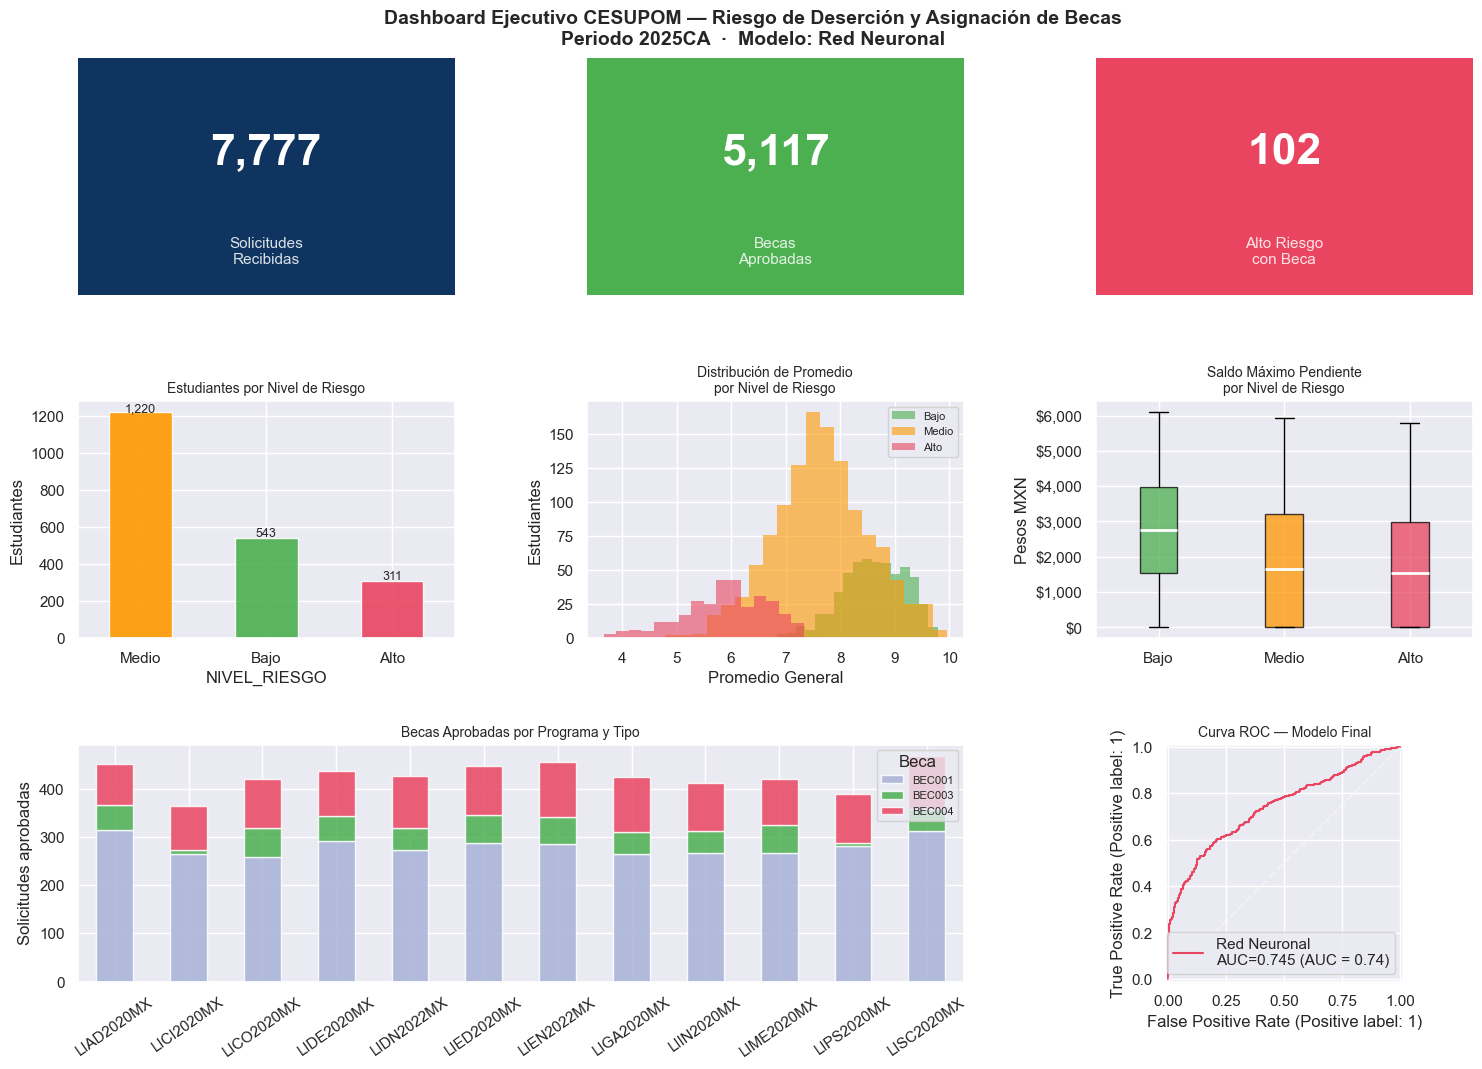

💾  Dashboard guardado como dashboard_ejecutivo.png


In [71]:
# ── 5.6  Dashboard consolidado ────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    f'Dashboard Ejecutivo CESUPOM — Riesgo de Deserción y Asignación de Becas\n'
    f'Periodo {PERIODO_EVAL}  ·  Modelo: {MODELO_GANADOR}',
    fontsize=14, fontweight='bold', y=0.92
)

# Layout: 3 filas × 3 columnas
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Métricas KPI (fila 0) ─────────────────────────────────────────────────────
kpis = [
    ('Solicitudes\nRecibidas',    f"{len(evabec):,}",         '#0f3460'),
    ('Becas\nAprobadas',          f"{aprobadas_total:,}",     '#4caf50'),
    ('Alto Riesgo\ncon Beca',     f"{impacto_alto:,}",        COLOR_ACENTO),
]
for i, (label, valor, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, valor, ha='center', va='center',
            fontsize=32, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.18, label, ha='center', va='center',
            fontsize=11, color='white', alpha=0.85,
            transform=ax.transAxes)

    # Corrección: Ocultar ejes y bordes conservando el color de fondo
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── Score de riesgo por nivel (fila 1, col 0) ────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
nivel_counts = df_test['NIVEL_RIESGO'].value_counts()
colores_nivel = {'Bajo': '#4caf50', 'Medio': '#ff9800', 'Alto': COLOR_ACENTO}
nivel_counts.plot(kind='bar', ax=ax1,
                  color=[colores_nivel.get(str(n), '#999') for n in nivel_counts.index],
                  edgecolor='white', alpha=0.90)
ax1.set_title('Estudiantes por Nivel de Riesgo', fontsize=10)
ax1.set_ylabel('Estudiantes')
ax1.tick_params(axis='x', rotation=0)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{int(bar.get_height()):,}', ha='center', fontsize=9)

# ── Distribución de promedio por nivel de riesgo (fila 1, col 1) ─────────────
ax2 = fig.add_subplot(gs[1, 1])
for nivel, color in [('Bajo','#4caf50'), ('Medio','#ff9800'), ('Alto',COLOR_ACENTO)]:
    sub = df_test[df_test['NIVEL_RIESGO'] == nivel]['PROMEDIO_GENERAL'].dropna()
    if len(sub) > 0:
        ax2.hist(sub, bins=20, label=nivel, color=color, alpha=0.60, edgecolor='none')
ax2.set_title('Distribución de Promedio\npor Nivel de Riesgo', fontsize=10)
ax2.set_xlabel('Promedio General')
ax2.set_ylabel('Estudiantes')
ax2.legend(fontsize=8)

# ── Saldo máximo por nivel de riesgo (fila 1, col 2) ─────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
df_test_plot = df_test.copy()
df_test_plot['NIVEL_RIESGO_STR'] = df_test_plot['NIVEL_RIESGO'].astype(str)
orden_niveles = ['Bajo', 'Medio', 'Alto']
saldo_data = [
    df_test_plot.loc[df_test_plot['NIVEL_RIESGO_STR'] == n, 'SALDO_MAX'].dropna().values
    for n in orden_niveles
]
bp3 = ax3.boxplot(saldo_data, labels=orden_niveles, patch_artist=True,
                  medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp3['boxes'], ['#4caf50','#ff9800',COLOR_ACENTO]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax3.set_title('Saldo Máximo Pendiente\npor Nivel de Riesgo', fontsize=10)
ax3.set_ylabel('Pesos MXN')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── Becas aprobadas por programa (fila 2, cols 0-1) ───────────────────────────
ax4 = fig.add_subplot(gs[2, :2])
becas_prog = (
    evabec[evabec['RESULTADO'] == 'APROBADA']
    .merge(solbec[['SID','CVE_PROGRAMA']].drop_duplicates(), on='SID', how='left')
    .groupby(['CVE_PROGRAMA','CVE_BECA'])
    .size()
    .unstack(fill_value=0)
)
if not becas_prog.empty:
    becas_prog.plot(kind='bar', ax=ax4, stacked=True,
                    color=[COLOR_NEUTRO, '#4caf50', COLOR_ACENTO, '#ff9800'][:len(becas_prog.columns)],
                    edgecolor='white', alpha=0.85)
    ax4.set_title('Becas Aprobadas por Programa y Tipo', fontsize=10)
    ax4.set_xlabel('')
    ax4.set_ylabel('Solicitudes aprobadas')
    ax4.tick_params(axis='x', rotation=35)
    ax4.legend(title='Beca', fontsize=8, loc='upper right')

# ── Curva ROC del modelo ganador (fila 2, col 2) ──────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
y_score_plot = y_proba_rf if MODELO_GANADOR == 'Random Forest' else y_proba_nn
RocCurveDisplay.from_predictions(
    y_test, y_score_plot,
    name=f'{MODELO_GANADOR}\nAUC={roc_auc_score(y_test, y_score_plot):.3f}',
    ax=ax5, color=COLOR_ACENTO
)
ax5.plot([0,1],[0,1],'w--', alpha=0.4)
ax5.set_title('Curva ROC — Modelo Final', fontsize=10)

plt.savefig('dashboard_ejecutivo.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾  Dashboard guardado como dashboard_ejecutivo.png')

---
# 🚀 Sección 6 — Recursos, Reto de Cierre y Comunidad

Llegaste al final del pipeline. Pero en ciencia de datos, el final de un proyecto es casi siempre el inicio de otro. Esta sección te da lo que necesitas para continuar por tu cuenta.

## 6.1 ¿Qué mejorarías si tuvieras más tiempo?

El pipeline que construiste es funcional y completo, pero tiene supuestos y simplificaciones que en un proyecto real habría que resolver. Aquí van las líneas de mejora más importantes, ordenadas de mayor a menor impacto esperado:

**1. Georreferenciación real con SEPOMEX**
El diccionario de centroides municipales es una aproximación. La distancia real entre el domicilio y CESUPOM requiere cruzar con el catálogo oficial de SEPOMEX (disponible en datos.gob.mx), que mapea cada CP a su colonia, municipio y entidad con coordenadas geográficas precisas.

**2. Enriquecimiento con índice de rezago social CONEVAL**
Cruzar el municipio del estudiante con el Índice de Rezago Social de CONEVAL (datos.gob.mx/coneval) agrega una dimensión estructural que los datos institucionales no capturan: no es lo mismo crecer en un municipio de rezago muy alto que en uno de rezago muy bajo, aunque el ingreso declarado sea similar.

**3. Modelo temporal — predicción por periodo**
El modelo actual usa el historial acumulado completo. Un modelo más preciso entrenaría sobre los datos disponibles hasta el periodo `t` para predecir el estado en el periodo `t+1`. Esto simula el escenario real donde la institución quiere anticipar la deserción antes de que ocurra.

**4. Optimización del umbral de clasificación**
El umbral de 0.50 para la clase positiva es el default. Para este problema, un umbral más bajo (e.g., 0.35) aumentaría el recall a costa de más falsos positivos — lo que probablemente sea un intercambio aceptable si el costo de una beca asignada de más es menor que el costo de perder a un estudiante.

**5. Detección de fraude en solicitudes**
La auditoría de la Sección 3.4.3 detectó casos donde el promedio declarado supera al institucional. Un módulo de detección de inconsistencias entre cuestionario y base institucional — ingresos declarados vs. historial de pagos, CP declarado vs. registrado — agregaría una capa de validación que cualquier sistema de becas real necesita.

## 6.2 Recursos para Seguir Aprendiendo

### Datos Abiertos del Gobierno Mexicano

| Fuente | Qué tiene | URL |
|--------|-----------|-----|
| **SEPOMEX** | Catálogo Nacional de CPs con coordenadas | datos.gob.mx |
| **CONEVAL** | Índice de Rezago Social municipal | coneval.org.mx |
| **INEGI** | Marco Geoestadístico, ENIGH, ENOE | inegi.org.mx |
| **SEP** | Estadísticas educativas del Sistema 911 | sep.gob.mx |
| **ANUIES** | Anuario estadístico de educación superior | anuies.mx |

### Librerías Clave que Usamos

| Librería | Para qué | Documentación |
|----------|----------|---------------|
| `pandas` | Manipulación y análisis de datos tabulares | pandas.pydata.org |
| `scikit-learn` | Machine learning clásico, métricas, pipeline | scikit-learn.org |
| `tensorflow/keras` | Redes neuronales | keras.io |
| `haversine` | Distancias geodésicas | pypi.org/project/haversine |
| `matplotlib/seaborn` | Visualización estadística | matplotlib.org / seaborn.pydata.org |

### Lecturas Recomendadas

- **"The Alignment Problem"** — Brian Christian. Sobre cómo los sistemas de ML heredan los sesgos de sus datos de entrenamiento. Accesible para no especialistas.
- **"Fairness and Machine Learning"** — Barocas, Hardt, Narayanan. Libro gratuito en fairmlbook.org. El estándar académico sobre equidad en ML.
- **"Designing Data-Intensive Applications"** — Martin Kleppmann. Para entender cómo se construyen sistemas de datos en producción.
- **Documentación de LGPDPPSO** — ley.org.mx. La regulación mexicana de protección de datos que aplica a cualquier sistema que procese información personal.

## 6.3 Reto de Cierre — Extiende el Pipeline

El taller terminó, pero el dataset sigue siendo tuyo. Aquí van tres retos de dificultad creciente para seguir practicando con los mismos datos:

### 🟢 Reto Básico — Optimización del Umbral
En la Sección 4 usamos un umbral de 0.50 para clasificar entre riesgo y no riesgo. Tu misión: encontrar el umbral óptimo que maximice el F1-Score del Random Forest usando la curva de precisión-recall. Grafícala, identifica el punto óptimo y recalcula las métricas con ese nuevo umbral. ¿Cuántos estudiantes en riesgo adicionales detecta el modelo?

```python
# Pista de inicio
from sklearn.metrics import precision_recall_curve
prec, rec, thresholds = precision_recall_curve(y_test, y_proba_rf)
```

### 🟡 Reto Intermedio — Modelo Temporal por Periodo
En lugar de usar el historial completo, construye las features del modelo usando solo la información disponible hasta el periodo `2023CA`. Luego evalúa el modelo sobre estudiantes cuya baja ocurrió en `2024CA`. ¿El modelo funciona igual de bien cuando se usa de forma prospectiva — es decir, prediciéndo el futuro con datos del pasado?

```python
# Pista de inicio
calfin_pre_corte = calfin_clean[calfin_clean['PERIODO'] < '2023CA']
```

### 🔴 Reto Avanzado — Integración con CONEVAL y SEPOMEX
Descarga el catálogo de SEPOMEX (datos.gob.mx) y el Índice de Rezago Social municipal de CONEVAL. Recalcula `DISBEC` con distancias exactas por CP (en lugar de centroides municipales) y agrega el índice de rezago social como feature adicional al modelo. ¿Cuánto mejora el AUC? ¿El feature de rezago social tiene mayor o menor importancia que el ingreso declarado en el cuestionario?

In [72]:
# ── Resumen final del pipeline completo ───────────────────────────────────────
print()
print('╔' + '═'*63 + '╗')
print('║' + '  PIPELINE COMPLETO — RESUMEN FINAL'.center(63) + '║')
print('╠' + '═'*63 + '╣')
print(f'║  Tablas institucionales procesadas  : 8                     ║')
print(f'║  Tablas de becas procesadas         : 4                     ║')
print(f'║  Artefactos construidos             : DISBEC, SOLBEC, EVABEC║')
print(f'║  Features de modelado               : {len(FEATURES):<28}║')
print(f'║  Modelos entrenados                 : Random Forest + NN    ║')
print(f'║  Modelo seleccionado                : {MODELO_GANADOR:<28}║')
print(f'║  AUC-ROC Random Forest              : {auc_rf:<28.4f}║')
print(f'║  AUC-ROC Red Neuronal               : {auc_nn:<28.4f}║')
print(f'║  Solicitudes evaluadas (EVABEC)     : {len(evabec):<28,}║')
print(f'║  Becas aprobadas                    : {aprobadas_total:<28,}║')
print(f'║  Alto riesgo con beca asignada      : {impacto_alto:<28,}║')
print('╚' + '═'*63 + '╝')


╔═══════════════════════════════════════════════════════════════╗
║                PIPELINE COMPLETO — RESUMEN FINAL              ║
╠═══════════════════════════════════════════════════════════════╣
║  Tablas institucionales procesadas  : 8                     ║
║  Tablas de becas procesadas         : 4                     ║
║  Artefactos construidos             : DISBEC, SOLBEC, EVABEC║
║  Features de modelado               : 20                          ║
║  Modelos entrenados                 : Random Forest + NN    ║
║  Modelo seleccionado                : Red Neuronal                ║
║  AUC-ROC Random Forest              : 0.7431                      ║
║  AUC-ROC Red Neuronal               : 0.7447                      ║
║  Solicitudes evaluadas (EVABEC)     : 7,777                       ║
║  Becas aprobadas                    : 5,117                       ║
║  Alto riesgo con beca asignada      : 102                         ║
╚══════════════════════════════════════════════════════

# 🚀 ¿Qué decisión tomarías?

---

No solo has ejecutado celdas de código. Has transformado el **caos** de datos crudos en un **insight** accionable.

Hoy construiste una herramienta capaz de predecir el futuro académico de miles de estudiantes. Recuerda: **Detrás de cada fila en un CSV, hay una historia de vida.**

---

> 📊 **Talentland 2026 · Del Caos al Insight**  
> *Taller desarrollado por ***[Luis Andrade](https://www.linkedin.com/in/luisandradeg)*** en colaboración con **Techy Events***

## ¿Estuviste por completo en este taller?

Escanea el siguiente código QR, confirma tu asistencia y gana una badge gratis por parte de **Techy Events**

![Asistencia](asistencia.jpeg)